# imports

In [5]:
# ============================================================
# GRABMyo EMG — GNN Classification
# Step 1: Load Dataset
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [6]:
DATA_DIR = "/kaggle/input/datasets/raihanbd/grabmyopc"

In [7]:
import os

for root, dirs, files in os.walk(DATA_DIR):
    level = root.replace(DATA_DIR, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    if level >= 2:
        dirs[:] = []

    for file in files[:10]:
        print(f"{indent}    {file}")

grabmyopc/
    segmentEMG.m
    grabmyo_convert_wfdb_to_mat.py
    MotionSequence.txt
    SHA256SUMS.txt
    RECORDS
    Electrodelocation.pdf
    grabmyo_visualize.py
    readme.txt
    featiDFTl.m
    LICENSE.txt
    Session1/
        session1_participant39/
            session1_participant39_gesture2_trial2.dat
            session1_participant39_gesture16_trial5.dat
            session1_participant39_gesture7_trial2.hea
            session1_participant39_gesture4_trial5.hea
            session1_participant39_gesture9_trial1.hea
            session1_participant39_gesture7_trial4.hea
            session1_participant39_gesture2_trial6.hea
            session1_participant39_gesture15_trial2.hea
            session1_participant39_gesture2_trial1.dat
            session1_participant39_gesture2_trial7.hea
        session1_participant35/
            session1_participant35_gesture7_trial1.dat
            session1_participant35_gesture8_trial6.dat
            session1_participant35_gesture7_t

In [9]:
!pip install wfdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 9.8 MB/s eta 0:00:00


In [10]:
# ============================================================
# GRABMyo EMG GNN
# Step 1: Load Dataset
# ============================================================

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import wfdb

print("Libraries imported successfully.")

Libraries imported successfully.


# load

In [11]:
DATA_DIR = "/kaggle/input/datasets/raihanbd/grabmyopc"

In [12]:
print(os.listdir(DATA_DIR))

['segmentEMG.m', 'grabmyo_convert_wfdb_to_mat.py', 'MotionSequence.txt', 'SHA256SUMS.txt', 'RECORDS', 'Electrodelocation.pdf', 'grabmyo_visualize.py', 'Session1', 'readme.txt', 'featiDFTl.m', 'Session3', 'LICENSE.txt', 'Session2', 'GestureList.JPG', 'subject-info.csv', 'DeviceInfo.pdf', 'grabmyo_feature_extraction.m']


# Find all .hea files

In [13]:
hea_files = []

for root, dirs, files in os.walk(DATA_DIR):
    for file in files:
        if file.endswith(".hea"):
            hea_files.append(os.path.join(root, file))

print("Number of .hea files:", len(hea_files))
print("\nFirst 10 files:")

for f in hea_files[:10]:
    print(f)

Number of .hea files: 15351

First 10 files:
/kaggle/input/datasets/raihanbd/grabmyopc/Session1/session1_participant39/session1_participant39_gesture7_trial2.hea
/kaggle/input/datasets/raihanbd/grabmyopc/Session1/session1_participant39/session1_participant39_gesture4_trial5.hea
/kaggle/input/datasets/raihanbd/grabmyopc/Session1/session1_participant39/session1_participant39_gesture9_trial1.hea
/kaggle/input/datasets/raihanbd/grabmyopc/Session1/session1_participant39/session1_participant39_gesture7_trial4.hea
/kaggle/input/datasets/raihanbd/grabmyopc/Session1/session1_participant39/session1_participant39_gesture2_trial6.hea
/kaggle/input/datasets/raihanbd/grabmyopc/Session1/session1_participant39/session1_participant39_gesture15_trial2.hea
/kaggle/input/datasets/raihanbd/grabmyopc/Session1/session1_participant39/session1_participant39_gesture2_trial7.hea
/kaggle/input/datasets/raihanbd/grabmyopc/Session1/session1_participant39/session1_participant39_gesture16_trial5.hea
/kaggle/input/dat

# Extract metadata from filenames

In [14]:
pattern = re.compile(
    r"session(\d+)_participant(\d+)_gesture(\d+)_trial(\d+)"
)

records = []

for hea_path in hea_files:

    filename = os.path.basename(hea_path)
    name = filename.replace(".hea", "")

    match = pattern.match(name)

    if match:
        session = int(match.group(1))
        participant = int(match.group(2))
        gesture = int(match.group(3))
        trial = int(match.group(4))

        records.append({
            "hea_path": hea_path,
            "session": session,
            "participant": participant,
            "gesture": gesture,
            "trial": trial
        })

metadata = pd.DataFrame(records)

metadata.head()

,hea_path,session,participant,gesture,trial
0,/kaggle/input/datasets/raihanbd/grabmyopc/Sess...,1,39,7,2
1,/kaggle/input/datasets/raihanbd/grabmyopc/Sess...,1,39,4,5
2,/kaggle/input/datasets/raihanbd/grabmyopc/Sess...,1,39,9,1
3,/kaggle/input/datasets/raihanbd/grabmyopc/Sess...,1,39,7,4
4,/kaggle/input/datasets/raihanbd/grabmyopc/Sess...,1,39,2,6


# Check the subjects

In [15]:
print("Number of unique participants:",
      metadata["participant"].nunique())

print("\nParticipants:")
print(sorted(metadata["participant"].unique()))

Number of unique participants: 43

Participants:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43)]


# Check the gestures

In [16]:
print("Number of gestures:",
      metadata["gesture"].nunique())

print("\nGesture IDs:")
print(sorted(metadata["gesture"].unique()))

Number of gestures: 17

Gesture IDs:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17)]


In [17]:
print("\nGesture distribution:")
print(metadata["gesture"].value_counts().sort_index())


Gesture distribution:
gesture
1     903
2     903
3     903
4     903
5     903
6     903
7     903
8     903
9     903
10    903
11    903
12    903
13    903
14    903
15    903
16    903
17    903
Name: count, dtype: int64


# Read ONE actual EMG recording

In [18]:
sample_path = metadata.iloc[0]["hea_path"]

sample_path

'/kaggle/input/datasets/raihanbd/grabmyopc/Session1/session1_participant39/session1_participant39_gesture7_trial2.hea'

In [19]:
record_path = sample_path[:-4]

record = wfdb.rdrecord(record_path)

print(record)

In [20]:
print("Signal shape:", record.p_signal.shape)
print("Sampling frequency:", record.fs)
print("Number of channels:", record.n_sig)
print("Channel names:", record.sig_name)

Signal shape: (10240, 32)
Sampling frequency: 2048
Number of channels: 32
Channel names: ['F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'F9', 'F10', 'F11', 'F12', 'F13', 'F14', 'F15', 'F16', 'U1', 'W1', 'W2', 'W3', 'W4', 'W5', 'W6', 'U2', 'U3', 'W7', 'W8', 'W9', 'W10', 'W11', 'W12', 'U4']


In [21]:
signals = record.p_signal

print("Shape:", signals.shape)

Shape: (10240, 32)


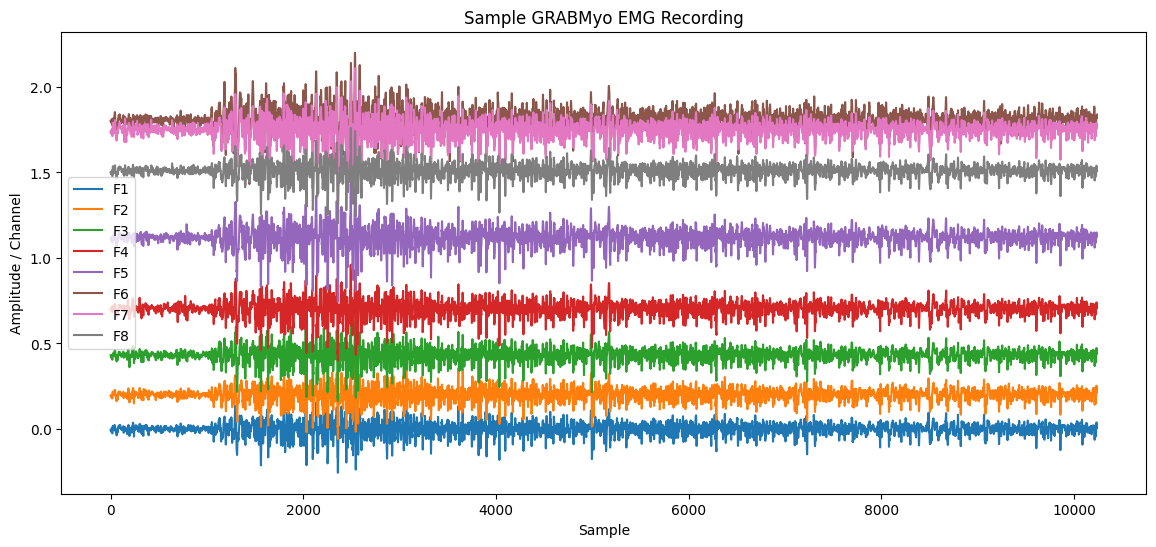

In [22]:
plt.figure(figsize=(14, 6))

num_channels_to_plot = min(8, signals.shape[1])

for i in range(num_channels_to_plot):
    plt.plot(
        signals[:, i] + i * np.std(signals[:, i]) * 5,
        label=record.sig_name[i]
    )

plt.title("Sample GRABMyo EMG Recording")
plt.xlabel("Sample")
plt.ylabel("Amplitude / Channel")
plt.legend()
plt.show()

# Inspecting recording metadata

In [23]:
print("Recordings per participant:")
print(
    metadata["participant"]
    .value_counts()
    .sort_index()
)

Recordings per participant:
participant
1     357
2     357
3     357
4     357
5     357
6     357
7     357
8     357
9     357
10    357
11    357
12    357
13    357
14    357
15    357
16    357
17    357
18    357
19    357
20    357
21    357
22    357
23    357
24    357
25    357
26    357
27    357
28    357
29    357
30    357
31    357
32    357
33    357
34    357
35    357
36    357
37    357
38    357
39    357
40    357
41    357
42    357
43    357
Name: count, dtype: int64


In [24]:
print("\nRecordings per session:")
print(
    metadata["session"]
    .value_counts()
    .sort_index()
)


Recordings per session:
session
1    5117
2    5117
3    5117
Name: count, dtype: int64


In [25]:
print("\nParticipant × Gesture:")
participant_gesture = pd.crosstab(
    metadata["participant"],
    metadata["gesture"]
)

display(participant_gesture)


Participant × Gesture:


gesture,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
participant,,,,,,,,,,,,,,,,,
1,21,21,21,21,21,21,21,21,21,21,21,21,21,21,21,21,21
2,21,21,21,21,21,21,21,21,21,21,21,21,21,21,21,21,21
3,21,21,21,21,21,21,21,21,21,21,21,21,21,21,21,21,21
4,21,21,21,21,21,21,21,21,21,21,21,21,21,21,21,21,21
5,21,21,21,21,21,21,21,21,21,21,21,21,21,21,21,21,21
6,21,21,21,21,21,21,21,21,21,21,21,21,21,21,21,21,21
7,21,21,21,21,21,21,21,21,21,21,21,21,21,21,21,21,21
8,21,21,21,21,21,21,21,21,21,21,21,21,21,21,21,21,21
9,21,21,21,21,21,21,21,21,21,21,21,21,21,21,21,21,21


# Inspecting one channel

In [26]:
sample_signal = record.p_signal

print("Overall minimum:", np.min(sample_signal))
print("Overall maximum:", np.max(sample_signal))
print("Overall mean:", np.mean(sample_signal))
print("Overall std:", np.std(sample_signal))

Overall minimum: -0.49741966635760587
Overall maximum: 0.4031314997241092
Overall mean: -1.5598855452271146e-05
Overall std: 0.04180344874322804


In [27]:
channel_stats = pd.DataFrame({
    "channel": record.sig_name,
    "mean": np.mean(sample_signal, axis=0),
    "std": np.std(sample_signal, axis=0),
    "min": np.min(sample_signal, axis=0),
    "max": np.max(sample_signal, axis=0)
})

display(channel_stats)

,channel,mean,std,min,max
0,F1,-1.728063e-05,0.038648,-0.256100,0.231324
1,F2,3.880519e-06,0.040217,-0.259641,0.235803
2,F3,-1.425622e-05,0.043247,-0.268734,0.207366
3,F4,-7.155010e-06,0.046931,-0.304835,0.255948
4,F5,-2.468320e-05,0.055999,-0.375265,0.313690
5,F6,-2.699739e-05,0.072197,-0.497420,0.395562
6,F7,-3.861319e-05,0.058380,-0.443455,0.358479
7,F8,-3.341873e-05,0.043165,-0.307245,0.250086
8,F9,-1.744213e-05,0.041423,-0.258408,0.232127
9,F10,-1.883113e-06,0.044030,-0.256577,0.242696


# Check the electrode location information

In [28]:
for root, dirs, files in os.walk(DATA_DIR):
    for file in files:
        if "electrode" in file.lower():
            print(os.path.join(root, file))

/kaggle/input/datasets/raihanbd/grabmyopc/Electrodelocation.pdf


# split

In [29]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

subjects = np.sort(metadata["participant"].unique())

print("Total subjects:", len(subjects))
print("Subjects:", subjects)

Total subjects: 43
Subjects: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43]


In [30]:
train_subjects, temp_subjects = train_test_split(
    subjects,
    test_size=13,
    random_state=RANDOM_STATE
)

val_subjects, test_subjects = train_test_split(
    temp_subjects,
    test_size=7,
    random_state=RANDOM_STATE
)

print("Train subjects:", sorted(train_subjects))
print("Validation subjects:", sorted(val_subjects))
print("Test subjects:", sorted(test_subjects))

Train subjects: [np.int64(1), np.int64(2), np.int64(3), np.int64(6), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(27), np.int64(29), np.int64(30), np.int64(31), np.int64(33), np.int64(34), np.int64(36), np.int64(39), np.int64(41), np.int64(42), np.int64(43)]
Validation subjects: [np.int64(5), np.int64(7), np.int64(13), np.int64(32), np.int64(35), np.int64(37)]
Test subjects: [np.int64(4), np.int64(9), np.int64(25), np.int64(26), np.int64(28), np.int64(38), np.int64(40)]


In [31]:
train_df = metadata[
    metadata["participant"].isin(train_subjects)
].copy()

val_df = metadata[
    metadata["participant"].isin(val_subjects)
].copy()

test_df = metadata[
    metadata["participant"].isin(test_subjects)
].copy()

In [32]:
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 10710
Validation: 2142
Test: 2499


# Verify there is NO subject leakage

In [33]:
train_set = set(train_df["participant"])
val_set = set(val_df["participant"])
test_set = set(test_df["participant"])

print("Train ∩ Validation:", train_set & val_set)
print("Train ∩ Test:", train_set & test_set)
print("Validation ∩ Test:", val_set & test_set)

Train ∩ Validation: set()
Train ∩ Test: set()
Validation ∩ Test: set()


In [34]:
print("TRAIN")
print(train_df["gesture"].value_counts().sort_index())

print("\nVALIDATION")
print(val_df["gesture"].value_counts().sort_index())

print("\nTEST")
print(test_df["gesture"].value_counts().sort_index())

TRAIN
gesture
1     630
2     630
3     630
4     630
5     630
6     630
7     630
8     630
9     630
10    630
11    630
12    630
13    630
14    630
15    630
16    630
17    630
Name: count, dtype: int64

VALIDATION
gesture
1     126
2     126
3     126
4     126
5     126
6     126
7     126
8     126
9     126
10    126
11    126
12    126
13    126
14    126
15    126
16    126
17    126
Name: count, dtype: int64

TEST
gesture
1     147
2     147
3     147
4     147
5     147
6     147
7     147
8     147
9     147
10    147
11    147
12    147
13    147
14    147
15    147
16    147
17    147
Name: count, dtype: int64


# preprocessing

In [35]:
readme_path = os.path.join(DATA_DIR, "readme.txt")

with open(readme_path, "r", errors="ignore") as f:
    readme_text = f.read()

print(readme_text)

*** Version 1.1.0 update***
Please do not use biometric_fileread.m from previous versions. Use grabmyo_convert_wfdb_to_mat.py instead
*** 

# Large-Sample and Multiday Surface Electromyogram Recordings of Hand Gestures

We provide the EMG signals recordings of 43 participants over 3 different days while performing multiple hand gestures. The signals have been acquired at a sampling rate of 2048 Hz using the EMGUSB2+ device (OT Bioelletronica, Italy). EMG signals have been collected from 16 locations (channels) on the forearm and 12 locations on the wrist. 

The signals are provided as ".dat" and ".hea" files. The files are organized under 3 folders, "Session1", "Session2" and Session3".  Each folder contains folders with the naming "session{i}_participant{j}" where i = {1,2,3} and j = {1,2,3...43}. Each folder contains files with the naming "session{i}_participant{j}_gesture{k}_trial{l}.dat" and (".hea") where k = {1,2,3...17} and l = {1,2,3...7} Sample matlab codes have been provided 

In [36]:
for root, dirs, files in os.walk(DATA_DIR):
    for file in files:
        if "feature" in file.lower():
            print(os.path.join(root, file))

/kaggle/input/datasets/raihanbd/grabmyopc/grabmyo_feature_extraction.m


# Official feature extraction

In [37]:
for root, dirs, files in os.walk(DATA_DIR):
    for file in files:
        if file.endswith(".m"):
            print(os.path.join(root, file))

/kaggle/input/datasets/raihanbd/grabmyopc/segmentEMG.m
/kaggle/input/datasets/raihanbd/grabmyopc/featiDFTl.m
/kaggle/input/datasets/raihanbd/grabmyopc/grabmyo_feature_extraction.m


In [42]:
import os

files = [
    "grabmyo_feature_extraction.m",
    "segmentEMG.m",
    "featiDFTl.m"
]

BASE_DIR = "/kaggle/input/datasets/raihanbd/grabmyopc"

for filename in files:
    path = os.path.join(BASE_DIR, filename)

    print("\n" + "=" * 80)
    print(f"FILE: {filename}")
    print("=" * 80)

    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        print(f.read())


FILE: grabmyo_feature_extraction.m
% This script will process the converted .mat using fileread.m
% to your hard drive. The converted files are located in 'Output BM' and
% organzied in 3 folders 'Session 1_converted','Session 2_converted' and
% 'Session 3_converted'. Each folder contains 43 .mat files, with two cell
% matrices DATA_FOREARM and DATA_WRIST
%
% DATA_FOREARM 7x17 cell matrix (trials x gestures)
% Each cell: 10240x16 (sampfreq*5sec x wristchannels)
%
% % DATA_WRIST 7x17 cell matrix (trials x gestures)
% Each cell: 10240x12 (sampfreq*5sec x wristchannels)
%
% Standard windowing of EMG signal is performed followed by frequency
% division technique feature extraction
% In order to run this script make sure 'Output BM' and srgmentEMG and
% featIDFT.m are in the same directory
%
% output %%%%%%%%%
% Main Folder: 'Feature Extracted BM'
% File: 'Forearm_Session1.mat' 'Forearm_Session2.mat' 'Forearm_Session3.mat'
% VarOut: FeatSet (NSUB x NGESTURES cell matrix)
% Each cell: NSAMP

# Official windowing

In [43]:
import numpy as np

FS = 2048

WINDOW_SEC = 0.2
STEP_SEC = 0.15

WINDOW_SIZE = int(np.floor(WINDOW_SEC * FS))
STEP_SIZE = int(np.floor(STEP_SEC * FS))

print("Window size:", WINDOW_SIZE)
print("Step size:", STEP_SIZE)

Window size: 409
Step size: 307


In [44]:
def create_windows(signal, window_size=WINDOW_SIZE, step_size=STEP_SIZE):
    """
    Segment one EMG recording into overlapping windows.

    Parameters
    ----------
    signal : np.ndarray
        Shape: (samples, channels)

    Returns
    -------
    windows : np.ndarray
        Shape: (n_windows, window_size, channels)
    """

    n_samples, n_channels = signal.shape

    windows = []

    for start in range(
        0,
        n_samples - window_size + 1,
        step_size
    ):
        end = start + window_size
        windows.append(signal[start:end])

    return np.asarray(windows)

In [45]:
hea_path = "/kaggle/input/datasets/raihanbd/grabmyopc/Session1/session1_participant39/session1_participant39_gesture7_trial2.hea"

In [46]:
import wfdb

record = wfdb.rdrecord(hea_path[:-4])

signal = record.p_signal

print("Signal shape:", signal.shape)
print("Sampling frequency:", record.fs)
print("Channels:", record.sig_name)

Signal shape: (10240, 32)
Sampling frequency: 2048
Channels: ['F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'F9', 'F10', 'F11', 'F12', 'F13', 'F14', 'F15', 'F16', 'U1', 'W1', 'W2', 'W3', 'W4', 'W5', 'W6', 'U2', 'U3', 'W7', 'W8', 'W9', 'W10', 'W11', 'W12', 'U4']


In [47]:
forearm_channels = [f"F{i}" for i in range(1, 17)]

channel_indices = [
    record.sig_name.index(ch)
    for ch in forearm_channels
]

forearm_signal = signal[:, channel_indices]

print("Forearm shape:", forearm_signal.shape)
print("Channels:", forearm_channels)

Forearm shape: (10240, 16)
Channels: ['F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'F9', 'F10', 'F11', 'F12', 'F13', 'F14', 'F15', 'F16']


In [48]:
reference = np.mean(
    forearm_signal[:, :8],
    axis=1,
    keepdims=True
)

referenced_signal = (
    forearm_signal[:, :8] - reference
)

print("Referenced signal shape:", referenced_signal.shape)

Referenced signal shape: (10240, 8)


In [49]:
windows = create_windows(referenced_signal)

print("Windows shape:", windows.shape)

Windows shape: (33, 409, 8)


In [50]:
starts = list(
    range(
        0,
        10240 - WINDOW_SIZE + 1,
        STEP_SIZE
    )
)

print("Number of windows:", len(starts))
print("First 10 start positions:", starts[:10])
print("Last start position:", starts[-1])
print("Last end position:", starts[-1] + WINDOW_SIZE)

Number of windows: 33
First 10 start positions: [0, 307, 614, 921, 1228, 1535, 1842, 2149, 2456, 2763]
Last start position: 9824
Last end position: 10233


In [51]:
print("Original:", signal.shape)
print("Forearm:", forearm_signal.shape)
print("Referenced:", referenced_signal.shape)
print("Windows:", windows.shape)
print("Number of windows:", len(windows))

Original: (10240, 32)
Forearm: (10240, 16)
Referenced: (10240, 8)
Windows: (33, 409, 8)
Number of windows: 33


# Implement the frequency features

In [60]:
import numpy as np

FS = 2048

BANDS = [
    (20, 92),
    (92, 163),
    (163, 235),
    (235, 307),
    (307, 378),
    (378, 450)
]


def extract_frequency_features_matlab(window, fs=2048):
    """
    MATLAB-equivalent implementation of featiDFTl.m.

    Input:
        window: (n_samples, n_channels)

    Output:
        features: (n_channels, 6)
    """

    n_samples, n_channels = window.shape

    # MATLAB:
    # temp = fft(sample);
    fft_values = np.fft.fft(window, axis=0)

    # MATLAB:
    # tl = fix(length(temp)/2);
    tl = n_samples // 2

    # MATLAB:
    # temp1 = abs(temp(1:tl));
    magnitude = np.abs(fft_values[:tl, :])

    # MATLAB's nf calculation
    num_features = 6

    lower = np.array([20, 92, 163, 235, 307, 378])
    upper = np.array([92, 163, 235, 307, 378, 450])

    nf_start = np.floor(
        lower * (n_samples / 2) / (fs / 2)
    ).astype(int)

    nf_end = np.floor(
        upper * (n_samples / 2) / (fs / 2)
    ).astype(int)

    # MATLAB:
    # if(nf(1,1)==0)
    #     nf(1,1)=1;
    # end

    if nf_start[0] == 0:
        nf_start[0] = 1

    features = np.zeros(
        (n_channels, num_features),
        dtype=np.float64
    )

    for channel in range(n_channels):

        spectrum = magnitude[:, channel]

        for band in range(num_features):

            # MATLAB:
            #
            # for a = 1:(nf(l1,2)-nf(l1,1))
            #     y = y + abs(temp1(a-1+nf(l1,1)));
            # end

            start = nf_start[band]
            end = nf_end[band]

            # MATLAB indexing is 1-based.
            # Python indexing is 0-based.
            #
            # MATLAB:
            # temp1(start : end-1)
            #
            # Python:
            # magnitude[start-1 : end-1]

            band_sum = np.sum(
                spectrum[start - 1:end - 1]
            )

            # MATLAB:
            # y = log(y);

            features[channel, band] = np.log(
                max(band_sum, np.finfo(float).tiny)
            )

    return features

In [61]:
X_matlab = extract_frequency_features_matlab(windows[0])

print("Shape:", X_matlab.shape)
print(X_matlab)

Shape: (8, 6)
[[ 1.24746988  1.02232335  0.41589938  0.0571609  -0.11242096 -0.26509825]
 [ 1.50362385  1.47270504  0.84350208  0.35754562  0.27885177 -0.22578328]
 [ 2.15352625  1.32340072  0.52597796  0.02995191 -0.31231477 -0.62765619]
 [ 2.28768181  1.69580508  1.04260896  0.35121298  0.45154365 -0.16095405]
 [ 2.17217911  1.5139259   0.80333409  0.43819708 -0.0342487  -0.49540965]
 [ 2.08486547  1.5315103   0.98452954  0.71454463  0.23849086 -0.27017938]
 [ 2.17313026  2.06632207  1.40901679  0.98367242  0.46776614  0.23346845]
 [ 1.50958745  0.97399416  0.6383924   0.27662632 -0.03962735 -0.31633858]]


In [62]:
windows.shape

(33, 409, 8)

In [63]:
window_0 = windows[0]

print("Window shape:", window_0.shape)

Window shape: (409, 8)


In [64]:
X = extract_frequency_features(window_0)

print("Node feature matrix:", X.shape)
print(X)

Node feature matrix: (8, 6)
[[ 1.24911145  0.87986167  0.43964875  0.07696815 -0.06702609 -0.42080194]
 [ 1.51519305  1.39305731  0.82162963  0.37304271  0.25182711 -0.26979253]
 [ 2.17504879  1.23428307  0.47958349  0.05172227 -0.34834089 -0.67983663]
 [ 2.31220432  1.58415812  0.94043635  0.32062284  0.45806454 -0.27751401]
 [ 2.16040221  1.44811598  0.74960151  0.4214965  -0.22522264 -0.30785306]
 [ 2.06346447  1.52031032  0.86871442  0.6988227   0.16677689 -0.25492896]
 [ 2.21383347  1.96753687  1.43583234  0.99323146  0.45276578  0.06650941]
 [ 1.57990035  0.78724612  0.56973172  0.26046646 -0.03354378 -0.39296469]]


In [65]:
print("Shape:", X.shape)
print("Minimum:", X.min())
print("Maximum:", X.max())
print("Mean:", X.mean())
print("Std:", X.std())

Shape: (8, 6)
Minimum: -0.6798366289031098
Maximum: 2.312204319844742
Mean: 0.7021541116288667
Std: 0.8124756985363061


In [66]:
print("\nFeatures for channel F1:")
print(X[0])

print("\nFeatures for channel F8:")
print(X[7])


Features for channel F1:
[ 1.24911145  0.87986167  0.43964875  0.07696815 -0.06702609 -0.42080194]

Features for channel F8:
[ 1.57990035  0.78724612  0.56973172  0.26046646 -0.03354378 -0.39296469]


In [67]:
X = extract_frequency_features(windows[0])

print("Node feature matrix:", X.shape)
print(X)

print("\nMin:", X.min())
print("Max:", X.max())
print("Mean:", X.mean())
print("Std:", X.std())

Node feature matrix: (8, 6)
[[ 1.24911145  0.87986167  0.43964875  0.07696815 -0.06702609 -0.42080194]
 [ 1.51519305  1.39305731  0.82162963  0.37304271  0.25182711 -0.26979253]
 [ 2.17504879  1.23428307  0.47958349  0.05172227 -0.34834089 -0.67983663]
 [ 2.31220432  1.58415812  0.94043635  0.32062284  0.45806454 -0.27751401]
 [ 2.16040221  1.44811598  0.74960151  0.4214965  -0.22522264 -0.30785306]
 [ 2.06346447  1.52031032  0.86871442  0.6988227   0.16677689 -0.25492896]
 [ 2.21383347  1.96753687  1.43583234  0.99323146  0.45276578  0.06650941]
 [ 1.57990035  0.78724612  0.56973172  0.26046646 -0.03354378 -0.39296469]]

Min: -0.6798366289031098
Max: 2.312204319844742
Mean: 0.7021541116288667
Std: 0.8124756985363061


In [68]:
n_samples = 409
fs = 2048

lower = np.array([20, 92, 163, 235, 307, 378])
upper = np.array([92, 163, 235, 307, 378, 450])

nf_start = np.floor(
    lower * (n_samples / 2) / (fs / 2)
).astype(int)

nf_end = np.floor(
    upper * (n_samples / 2) / (fs / 2)
).astype(int)

print("Start bins:", nf_start)
print("End bins:", nf_end)

Start bins: [ 3 18 32 46 61 75]
End bins: [18 32 46 61 75 89]


In [69]:
all_features = np.array([
    extract_frequency_features_matlab(window)
    for window in windows
])

print("All feature shape:", all_features.shape)

All feature shape: (33, 8, 6)


In [71]:
print(all_features.shape)

(33, 8, 6)


In [72]:
print("NaN:", np.isnan(all_features).sum())
print("Inf:", np.isinf(all_features).sum())

NaN: 0
Inf: 0


In [73]:
print("Min:", all_features.min())
print("Max:", all_features.max())
print("Mean:", all_features.mean())
print("Std:", all_features.std())

Min: -0.6276561934578546
Max: 3.819401448517924
Mean: 1.312778461663306
Std: 0.7869847987606483


# Create the graph topology

In [74]:
import torch

edge_pairs = [
    (0, 1), (1, 2), (2, 3),
    (4, 5), (5, 6), (6, 7),
    (0, 4), (1, 5), (2, 6), (3, 7)
]

# Make edges bidirectional
edges = []

for u, v in edge_pairs:
    edges.append((u, v))
    edges.append((v, u))

edge_index = torch.tensor(
    edges,
    dtype=torch.long
).t().contiguous()

print("edge_index shape:", edge_index.shape)
print(edge_index)

edge_index shape: torch.Size([2, 20])
tensor([[0, 1, 1, 2, 2, 3, 4, 5, 5, 6, 6, 7, 0, 4, 1, 5, 2, 6, 3, 7],
        [1, 0, 2, 1, 3, 2, 5, 4, 6, 5, 7, 6, 4, 0, 5, 1, 6, 2, 7, 3]])


In [75]:
print("Number of directed edges:", edge_index.shape[1])
print("Number of undirected edges:", len(edge_pairs))

Number of directed edges: 20
Number of undirected edges: 10


In [76]:
X = all_features[0]

x = torch.tensor(
    X,
    dtype=torch.float32
)

print("Node features:", x.shape)
print("Edge index:", edge_index.shape)

Node features: torch.Size([8, 6])
Edge index: torch.Size([2, 20])


In [78]:
!pip install torch-geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 45.6 MB/s eta 0:00:00


In [79]:
import torch
import torch_geometric

print("PyTorch:", torch.__version__)
print("PyG:", torch_geometric.__version__)

PyTorch: 2.10.0+cu128
PyG: 2.8.0.post1


In [80]:
from torch_geometric.data import Data

# Graph A — Spatial binary

In [81]:
import torch

EDGE_PAIRS = [
    (0, 1),
    (1, 2),
    (2, 3),
    (4, 5),
    (5, 6),
    (6, 7),
    (0, 4),
    (1, 5),
    (2, 6),
    (3, 7)
]


def make_spatial_edges():
    edges = []

    for u, v in EDGE_PAIRS:
        edges.append((u, v))
        edges.append((v, u))

    edge_index = torch.tensor(
        edges,
        dtype=torch.long
    ).t().contiguous()

    edge_weight = torch.ones(
        edge_index.shape[1],
        dtype=torch.float32
    )

    return edge_index, edge_weight

In [82]:
edge_index_A, edge_weight_A = make_spatial_edges()

print(edge_index_A.shape)
print(edge_weight_A.shape)

torch.Size([2, 20])
torch.Size([20])


# Graph B — Spatial + cosine similarity

In [85]:
import torch.nn.functional as F

def make_similarity_weighted_spatial_graph(
    X,
    edge_pairs=EDGE_PAIRS
):

    if not torch.is_tensor(X):
        X = torch.tensor(X, dtype=torch.float32)
    else:
        X = X.float()

    edges = []
    weights = []

    for u, v in edge_pairs:

        sim = F.cosine_similarity(
            X[u].unsqueeze(0),
            X[v].unsqueeze(0),
            dim=1
        ).item()

        sim = max(sim, 0.0)

        edges.append((u, v))
        weights.append(sim)

        edges.append((v, u))
        weights.append(sim)

    edge_index = torch.tensor(
        edges,
        dtype=torch.long
    ).t().contiguous()

    edge_weight = torch.tensor(
        weights,
        dtype=torch.float32
    )

    return edge_index, edge_weight

In [86]:
X = all_features[0]

edge_index_B, edge_weight_B = \
    make_similarity_weighted_spatial_graph(X)

print("edge_index:", edge_index_B.shape)
print("edge_weight:", edge_weight_B.shape)

print("\nWeights:")
print(edge_weight_B)

edge_index: torch.Size([2, 20])
edge_weight: torch.Size([20])

Weights:
tensor([0.9622, 0.9622, 0.9164, 0.9164, 0.9301, 0.9301, 0.9853, 0.9853, 0.9764,
        0.9764, 0.9336, 0.9336, 0.9875, 0.9875, 0.9865, 0.9865, 0.8439, 0.8439,
        0.9779, 0.9779])


# Graph C — fully data-driven kNN

In [87]:
def make_knn_similarity_graph(X, k=2):

    if not torch.is_tensor(X):
        X = torch.tensor(
            X,
            dtype=torch.float32
        )
    else:
        X = X.float()

    # Normalize node feature vectors
    X_norm = F.normalize(
        X,
        p=2,
        dim=1
    )

    # 8 × 8 similarity matrix
    similarity = X_norm @ X_norm.T

    edges = []
    weights = []

    n_nodes = X.shape[0]

    for i in range(n_nodes):

        # exclude self
        sim_row = similarity[i].clone()
        sim_row[i] = -float("inf")

        # top-k neighbors
        values, indices = torch.topk(
            sim_row,
            k=k
        )

        for value, j in zip(values, indices):

            weight = max(
                value.item(),
                0.0
            )

            edges.append(
                (i, j.item())
            )

            weights.append(weight)

    edge_index = torch.tensor(
        edges,
        dtype=torch.long
    ).t().contiguous()

    edge_weight = torch.tensor(
        weights,
        dtype=torch.float32
    )

    return edge_index, edge_weight

In [88]:
edge_index_C, edge_weight_C = \
    make_knn_similarity_graph(
        all_features[0],
        k=2
    )

print("edge_index:", edge_index_C.shape)
print("edge_weight:", edge_weight_C.shape)

edge_index: torch.Size([2, 16])
edge_weight: torch.Size([16])


# create actual PyG graphs

In [89]:
def create_graph(
    X,
    y,
    graph_type="spatial"
):

    if graph_type == "spatial":

        edge_index, edge_weight = \
            make_spatial_edges()

    elif graph_type == "spatial_similarity":

        edge_index, edge_weight = \
            make_similarity_weighted_spatial_graph(X)

    elif graph_type == "knn":

        edge_index, edge_weight = \
            make_knn_similarity_graph(X, k=2)

    else:
        raise ValueError(
            f"Unknown graph type: {graph_type}"
        )

    x = torch.tensor(
        X,
        dtype=torch.float32
    )

    y = torch.tensor(
        [y],
        dtype=torch.long
    )

    graph = Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_weight.unsqueeze(1),
        y=y
    )

    return graph

In [92]:
graph_A = create_graph(
    all_features[0],
    y=6,
    graph_type="spatial"
)

graph_B = create_graph(
    all_features[0],
    y=6,
    graph_type="spatial_similarity"
)

graph_C = create_graph(
    all_features[0],
    y=6,
    graph_type="knn"
)

print("A:", graph_A)
print("B:", graph_B)
print("C:", graph_C)

print("\nA weights:", graph_A.edge_attr.squeeze())
print("\nB weights:", graph_B.edge_attr.squeeze())
print("\nC weights:", graph_C.edge_attr.squeeze())

A: Data(x=[8, 6], edge_index=[2, 20], edge_attr=[20, 1], y=[1])
B: Data(x=[8, 6], edge_index=[2, 20], edge_attr=[20, 1], y=[1])
C: Data(x=[8, 6], edge_index=[2, 16], edge_attr=[16, 1], y=[1])

A weights: tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1.])

B weights: tensor([0.9622, 0.9622, 0.9164, 0.9164, 0.9301, 0.9301, 0.9853, 0.9853, 0.9764,
        0.9764, 0.9336, 0.9336, 0.9875, 0.9875, 0.9865, 0.9865, 0.8439, 0.8439,
        0.9779, 0.9779])

C weights: tensor([0.9875, 0.9859, 0.9895, 0.9865, 0.9859, 0.9773, 0.9895, 0.9878, 0.9982,
        0.9875, 0.9878, 0.9865, 0.9764, 0.9763, 0.9982, 0.9848])


# GCN

In [93]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import GCNConv, global_mean_pool


class GCNClassifier(nn.Module):

    def __init__(
        self,
        in_channels=6,
        hidden_channels=64,
        num_classes=17,
        dropout=0.3
    ):
        super().__init__()

        self.conv1 = GCNConv(
            in_channels,
            hidden_channels
        )

        self.conv2 = GCNConv(
            hidden_channels,
            hidden_channels
        )

        self.dropout = dropout

        self.classifier = nn.Linear(
            hidden_channels,
            num_classes
        )

    def forward(self, data):

        x = data.x
        edge_index = data.edge_index
        edge_weight = data.edge_attr.squeeze(-1)
        batch = data.batch

        # GCN layer 1
        x = self.conv1(
            x,
            edge_index,
            edge_weight=edge_weight
        )

        x = F.relu(x)
        x = F.dropout(
            x,
            p=self.dropout,
            training=self.training
        )

        # GCN layer 2
        x = self.conv2(
            x,
            edge_index,
            edge_weight=edge_weight
        )

        x = F.relu(x)

        # Graph-level representation
        x = global_mean_pool(
            x,
            batch
        )

        # Classification
        out = self.classifier(x)

        return out

In [94]:
model = GCNClassifier(
    in_channels=6,
    hidden_channels=64,
    num_classes=17,
    dropout=0.3
)

print(model)

GCNClassifier(
  (conv1): GCNConv(6, 64)
  (conv2): GCNConv(64, 64)
  (classifier): Linear(in_features=64, out_features=17, bias=True)
)


In [95]:
from torch_geometric.loader import DataLoader

loader = DataLoader(
    [graph_A],
    batch_size=1
)

batch = next(iter(loader))

print("x:", batch.x.shape)
print("edge_index:", batch.edge_index.shape)
print("edge_attr:", batch.edge_attr.shape)
print("batch:", batch.batch.shape)
print("y:", batch.y.shape)

x: torch.Size([8, 6])
edge_index: torch.Size([2, 20])
edge_attr: torch.Size([20, 1])
batch: torch.Size([8])
y: torch.Size([1])


In [96]:
out = model(batch)

print("Output shape:", out.shape)
print("Output:", out)

Output shape: torch.Size([1, 17])
Output: tensor([[ 0.2047,  0.0228, -0.3437, -0.5593, -0.0159,  0.0426,  0.3953,  0.1350,
         -0.1962, -0.1613,  0.0629,  0.0317,  0.0522,  0.1593,  0.2751, -0.0173,
         -0.1351]], grad_fn=<AddmmBackward0>)


In [97]:
model = GCNClassifier(
    in_channels=6,
    hidden_channels=64,
    num_classes=17,
    dropout=0.3
)

loader = DataLoader(
    [graph_A],
    batch_size=1
)

batch = next(iter(loader))

out = model(batch)

print("Output shape:", out.shape)

Output shape: torch.Size([1, 17])


In [98]:
print("Variables currently available:")
for name in [
    "all_features",
    "node_features",
    "windows",
    "windowed_data",
    "labels",
    "subjects",
    "metadata",
    "train_data",
    "val_data",
    "test_data"
]:
    if name in globals():
        obj = globals()[name]
        print(f"{name}: type={type(obj)}, shape={getattr(obj, 'shape', 'no shape')}")

Variables currently available:
all_features: type=<class 'numpy.ndarray'>, shape=(33, 8, 6)
windows: type=<class 'numpy.ndarray'>, shape=(33, 409, 8)
subjects: type=<class 'numpy.ndarray'>, shape=(43,)
metadata: type=<class 'pandas.core.frame.DataFrame'>, shape=(15351, 5)


In [99]:
print("All relevant variables:")
for name in sorted(globals().keys()):
    if not name.startswith("_"):
        obj = globals()[name]
        if hasattr(obj, "shape") or isinstance(obj, (list, tuple, dict)):
            print(
                name,
                "type=", type(obj).__name__,
                "shape=", getattr(obj, "shape", None)
            )

All relevant variables:
BANDS type= list shape= None
EDGE_PAIRS type= list shape= None
In type= list shape= None
Out type= dict shape= None
X type= ndarray shape= (8, 6)
X_matlab type= ndarray shape= (8, 6)
all_features type= ndarray shape= (33, 8, 6)
channel_indices type= list shape= None
channel_stats type= DataFrame shape= (32, 5)
dirs type= list shape= None
edge_index type= Tensor shape= torch.Size([2, 20])
edge_index_A type= Tensor shape= torch.Size([2, 20])
edge_index_B type= Tensor shape= torch.Size([2, 20])
edge_index_C type= Tensor shape= torch.Size([2, 16])
edge_pairs type= list shape= None
edge_weight_A type= Tensor shape= torch.Size([20])
edge_weight_B type= Tensor shape= torch.Size([20])
edge_weight_C type= Tensor shape= torch.Size([16])
edges type= list shape= None
files type= list shape= None
forearm_channels type= list shape= None
forearm_signal type= ndarray shape= (10240, 16)
hea_files type= list shape= None
lower type= ndarray shape= (6,)
metadata type= DataFrame sha

In [100]:
print(metadata.head())

print("\nCurrent recording:")
print(metadata.iloc[0])

                                            hea_path  session  participant  \
0  /kaggle/input/datasets/raihanbd/grabmyopc/Sess...        1           39   
1  /kaggle/input/datasets/raihanbd/grabmyopc/Sess...        1           39   
2  /kaggle/input/datasets/raihanbd/grabmyopc/Sess...        1           39   
3  /kaggle/input/datasets/raihanbd/grabmyopc/Sess...        1           39   
4  /kaggle/input/datasets/raihanbd/grabmyopc/Sess...        1           39   

   gesture  trial  
0        7      2  
1        4      5  
2        9      1  
3        7      4  
4        2      6  

Current recording:
hea_path       /kaggle/input/datasets/raihanbd/grabmyopc/Sess...
session                                                        1
participant                                                   39
gesture                                                        7
trial                                                          2
Name: 0, dtype: object


In [101]:
print("Current signal:")
print("signal:", signal.shape)

print("\nCurrent referenced signal:")
print("referenced_signal:", referenced_signal.shape)

print("\nCurrent windows:")
print("windows:", windows.shape)

print("\nCurrent all_features:")
print("all_features:", all_features.shape)

Current signal:
signal: (10240, 32)

Current referenced signal:
referenced_signal: (10240, 8)

Current windows:
windows: (33, 409, 8)

Current all_features:
all_features: (33, 8, 6)


In [102]:
print("\nFirst metadata rows:")
display(metadata.head())


First metadata rows:


,hea_path,session,participant,gesture,trial
0,/kaggle/input/datasets/raihanbd/grabmyopc/Sess...,1,39,7,2
1,/kaggle/input/datasets/raihanbd/grabmyopc/Sess...,1,39,4,5
2,/kaggle/input/datasets/raihanbd/grabmyopc/Sess...,1,39,9,1
3,/kaggle/input/datasets/raihanbd/grabmyopc/Sess...,1,39,7,4
4,/kaggle/input/datasets/raihanbd/grabmyopc/Sess...,1,39,2,6


In [103]:
import wfdb
import numpy as np


FS = 2048
WINDOW_SEC = 0.2
STEP_SEC = 0.15

WINDOW_LEN = int(WINDOW_SEC * FS)   # 409
STEP_LEN = int(STEP_SEC * FS)       # 307


def load_and_prepare_record(row):

    record_path = row["hea_path"].replace(".hea", "")

    # -----------------------------------------
    # Load WFDB
    # -----------------------------------------
    record = wfdb.rdrecord(record_path)

    signal = record.p_signal.astype(np.float32)

    # 32 channels
    assert signal.shape[1] == 32

    # -----------------------------------------
    # Forearm channels
    # F1-F16
    # -----------------------------------------
    forearm_signal = signal[:, :16]

    # -----------------------------------------
    # Average referencing
    # First 8 channels
    # -----------------------------------------
    reference = np.mean(
        forearm_signal[:, :8],
        axis=1,
        keepdims=True
    )

    referenced_signal = (
        forearm_signal[:, :8] - reference
    )

    # -----------------------------------------
    # Windowing
    # -----------------------------------------
    windows = []

    start = 0

    while start + WINDOW_LEN <= len(referenced_signal):

        window = referenced_signal[
            start:start + WINDOW_LEN
        ]

        windows.append(window)

        start += STEP_LEN

    windows = np.asarray(
        windows,
        dtype=np.float32
    )

    return signal, forearm_signal, referenced_signal, windows

In [104]:
BANDS = [
    (20, 92),
    (92, 163),
    (163, 235),
    (235, 307),
    (307, 378),
    (378, 450)
]

In [112]:
def extract_node_features_matlab(windows, fs=2048):

    """
    Python reproduction of featiDFTl.m

    Input:
        windows: (n_windows, 409, 8)

    Output:
        features: (n_windows, 8, 6)
    """

    n_windows, sn, n_channels = windows.shape

    num = 6

    # Exact values from featiDFTl.m
    temp = np.array([20, 92, 163, 235, 307, 378])
    temp1 = np.array([92, 163, 235, 307, 378, 450])

    # Exact MATLAB formula
    nf_start = np.floor(
        temp * (sn / 2) / (fs / 2)
    ).astype(int)

    nf_end = np.floor(
        temp1 * (sn / 2) / (fs / 2)
    ).astype(int)

    # MATLAB:
    # if(nf(1,1)==0)
    #     nf(1,1) = 1;
    # end

    if nf_start[0] == 0:
        nf_start[0] = 1

    print("nf_start:", nf_start)
    print("nf_end:", nf_end)

    features = np.zeros(
        (n_windows, n_channels, num),
        dtype=np.float32
    )

    for i in range(n_windows):

        for ch in range(n_channels):

            sample = windows[i, :, ch]

            # MATLAB:
            # temp = fft(sample);
            fft_values = np.fft.fft(sample)

            # MATLAB:
            # tl = fix(length(temp)/2);
            tl = len(fft_values) // 2

            # MATLAB:
            # temp1 = abs(temp(1:tl));
            magnitude = np.abs(
                fft_values[:tl]
            )

            for band in range(num):

                # MATLAB indices are 1-based.
                #
                # MATLAB:
                # for a = 1:(nf(l1,2)-nf(l1,1))
                #     y = y + abs(temp1(a-1+nf(l1,1)));
                # end

                start = nf_start[band]
                end = nf_end[band]

                y = 0.0

                for a in range(
                    1,
                    end - start + 1
                ):

                    matlab_index = (
                        a - 1 + start
                    )

                    # Convert MATLAB index → Python index
                    python_index = matlab_index - 1

                    y += magnitude[python_index]

                # MATLAB:
                # y = log(y);
                features[i, ch, band] = np.log(y)

    return features

In [113]:
row = metadata.iloc[0]

signal_test, forearm_test, ref_test, windows_test = \
    load_and_prepare_record(row)

print("Raw:", signal_test.shape)
print("Forearm:", forearm_test.shape)
print("Referenced:", ref_test.shape)
print("Windows:", windows_test.shape)

Raw: (10240, 32)
Forearm: (10240, 16)
Referenced: (10240, 8)
Windows: (33, 409, 8)


In [114]:
features_test_matlab = extract_node_features_matlab(
    windows_test
)

print("Shape:", features_test_matlab.shape)

print(
    "NaN:",
    np.isnan(features_test_matlab).sum()
)

print(
    "Inf:",
    np.isinf(features_test_matlab).sum()
)

nf_start: [ 3 18 32 46 61 75]
nf_end: [18 32 46 61 75 89]
Shape: (33, 8, 6)
NaN: 0
Inf: 0


In [115]:
difference = np.abs(
    features_test_matlab - all_features
)

print(
    "Maximum absolute difference:",
    difference.max()
)

print(
    "Mean absolute difference:",
    difference.mean()
)

Maximum absolute difference: 2.729045784910511e-07
Mean absolute difference: 6.881912286295932e-08


In [116]:
import torch
from torch_geometric.data import Data


def create_graph_A(node_features, label):
    
    x = torch.tensor(
        node_features,
        dtype=torch.float32
    )

    edge_index = edge_index_A.clone()

    edge_attr = torch.ones(
        edge_index.shape[1],
        1,
        dtype=torch.float32
    )

    y = torch.tensor(
        [label],
        dtype=torch.long
    )

    graph = Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=y
    )

    return graph

In [118]:
import numpy as np
import torch


def compute_signal_edge_weights(node_features, edge_index):
    """
    node_features: numpy array, shape (8, 6)
    edge_index: torch tensor, shape (2, E)

    Returns:
        edge_weights: torch tensor, shape (E,)
    """

    X = np.asarray(node_features, dtype=np.float32)

    weights = []

    for e in range(edge_index.shape[1]):

        i = edge_index[0, e].item()
        j = edge_index[1, e].item()

        xi = X[i]
        xj = X[j]

        denominator = (
            np.linalg.norm(xi) *
            np.linalg.norm(xj)
        )

        if denominator == 0:
            similarity = 0.0
        else:
            similarity = np.dot(xi, xj) / denominator

        weights.append(similarity)

    return torch.tensor(
        weights,
        dtype=torch.float32
    )

In [117]:
graph_A = create_graph_A(
    features_test_matlab[0],
    row["gesture"] - 1
)

print(graph_A)
print("x:", graph_A.x.shape)
print("edge_index:", graph_A.edge_index.shape)
print("edge_attr:", graph_A.edge_attr.shape)
print("y:", graph_A.y)

Data(x=[8, 6], edge_index=[2, 20], edge_attr=[20, 1], y=[1])
x: torch.Size([8, 6])
edge_index: torch.Size([2, 20])
edge_attr: torch.Size([20, 1])
y: tensor([6])


In [119]:
def create_graph_B(node_features, label):

    x = torch.tensor(
        node_features,
        dtype=torch.float32
    )

    edge_index = edge_index_A.clone()

    edge_weights = compute_signal_edge_weights(
        node_features,
        edge_index
    )

    edge_attr = edge_weights.view(-1, 1)

    y = torch.tensor(
        [label],
        dtype=torch.long
    )

    graph = Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=y
    )

    return graph

In [120]:
graph_B = create_graph_B(
    features_test_matlab[0],
    row["gesture"] - 1
)

print(graph_B)

print("x:", graph_B.x.shape)
print("edge_index:", graph_B.edge_index.shape)
print("edge_attr:", graph_B.edge_attr.shape)
print("y:", graph_B.y)

print("\nEdge weights:")
print(graph_B.edge_attr.squeeze())

Data(x=[8, 6], edge_index=[2, 20], edge_attr=[20, 1], y=[1])
x: torch.Size([8, 6])
edge_index: torch.Size([2, 20])
edge_attr: torch.Size([20, 1])
y: tensor([6])

Edge weights:
tensor([0.9622, 0.9622, 0.9164, 0.9164, 0.9301, 0.9301, 0.9853, 0.9853, 0.9764,
        0.9764, 0.9336, 0.9336, 0.9875, 0.9875, 0.9865, 0.9865, 0.8439, 0.8439,
        0.9779, 0.9779])


In [121]:
weights_B = graph_B.edge_attr.squeeze().numpy()

print("Min:", weights_B.min())
print("Max:", weights_B.max())
print("Mean:", weights_B.mean())
print("Std:", weights_B.std())

Min: 0.84392303
Max: 0.9875241
Mean: 0.9499776
Std: 0.043197695


In [122]:
for e in range(0, len(weights_B), 2):
    print(
        e,
        weights_B[e],
        weights_B[e + 1],
        "difference =",
        abs(weights_B[e] - weights_B[e + 1])
    )

0 0.9622439 0.9622439 difference = 0.0
2 0.9163622 0.9163622 difference = 0.0
4 0.93008554 0.93008554 difference = 0.0
6 0.98530436 0.98530436 difference = 0.0
8 0.9763966 0.9763966 difference = 0.0
10 0.9335656 0.9335656 difference = 0.0
12 0.9875241 0.9875241 difference = 0.0
14 0.98648924 0.98648924 difference = 0.0
16 0.84392303 0.84392303 difference = 0.0
18 0.9778801 0.9778801 difference = 0.0


In [123]:
print("Graph C")
print("Edge index:")
print(edge_index_C)

print("\nEdge weights:")
print(edge_weight_C)

print("\nNumber of directed edges:",
      edge_index_C.shape[1])

print("\nNumber of undirected edges:",
      edge_index_C.shape[1] // 2)

print("\nWeight statistics:")

weights_C = edge_weight_C.numpy()

print("Min:", weights_C.min())
print("Max:", weights_C.max())
print("Mean:", weights_C.mean())
print("Std:", weights_C.std())

Graph C
Edge index:
tensor([[0, 0, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7],
        [4, 2, 3, 5, 0, 4, 1, 5, 7, 0, 3, 1, 5, 1, 4, 5]])

Edge weights:
tensor([0.9875, 0.9859, 0.9895, 0.9865, 0.9859, 0.9773, 0.9895, 0.9878, 0.9982,
        0.9875, 0.9878, 0.9865, 0.9764, 0.9763, 0.9982, 0.9848])

Number of directed edges: 16

Number of undirected edges: 8

Weight statistics:
Min: 0.9762912
Max: 0.9982215
Mean: 0.98661405
Std: 0.006092154


In [124]:
for e in range(0, edge_index_C.shape[1], 2):

    i = edge_index_C[0, e].item()
    j = edge_index_C[1, e].item()

    w1 = edge_weight_C[e].item()
    w2 = edge_weight_C[e + 1].item()

    print(
        f"{i} <-> {j} | "
        f"weights: {w1:.4f}, {w2:.4f}"
    )

0 <-> 4 | weights: 0.9875, 0.9859
1 <-> 3 | weights: 0.9895, 0.9865
2 <-> 0 | weights: 0.9859, 0.9773
3 <-> 1 | weights: 0.9895, 0.9878
4 <-> 7 | weights: 0.9982, 0.9875
5 <-> 3 | weights: 0.9878, 0.9865
6 <-> 5 | weights: 0.9764, 0.9763
7 <-> 4 | weights: 0.9982, 0.9848


In [128]:
import torch
import torch.nn as nn

from torch_geometric.nn import GCNConv
from torch_geometric.nn import global_mean_pool


class EMG_GCN(nn.Module):

    def __init__(
        self,
        in_channels=6,
        hidden_channels=64,
        num_classes=17,
        dropout=0.3
    ):
        super().__init__()

        self.conv1 = GCNConv(
            in_channels,
            hidden_channels
        )

        self.conv2 = GCNConv(
            hidden_channels,
            hidden_channels
        )

        self.dropout = nn.Dropout(dropout)

        self.classifier = nn.Linear(
            hidden_channels,
            num_classes
        )

    def forward(
        self,
        x,
        edge_index,
        edge_weight,
        batch
    ):

        # GCN layer 1
        x = self.conv1(
            x,
            edge_index,
            edge_weight=edge_weight
        )

        x = torch.relu(x)

        x = self.dropout(x)

        # GCN layer 2
        x = self.conv2(
            x,
            edge_index,
            edge_weight=edge_weight
        )

        x = torch.relu(x)

        # Graph-level representation
        x = global_mean_pool(
            x,
            batch
        )

        # Classifier
        out = self.classifier(x)

        return out

In [129]:
graph_A.batch = torch.zeros(
    graph_A.num_nodes,
    dtype=torch.long
)

model = EMG_GCN()

model.eval()

with torch.no_grad():

    output = model(
        graph_A.x,
        graph_A.edge_index,
        graph_A.edge_attr.squeeze(),
        graph_A.batch
    )

print("Output shape:", output.shape)
print("Output:", output)

Output shape: torch.Size([1, 17])
Output: tensor([[-0.0117, -0.1302,  0.2834,  0.0346, -0.0359, -0.0805, -0.2007,  0.3060,
          0.1264,  0.0862,  0.0325,  0.0321,  0.2033, -0.1155, -0.0730,  0.0194,
          0.0530]])


In [130]:
def test_graph(graph, name):

    batch = torch.zeros(
        graph.num_nodes,
        dtype=torch.long
    )

    model.eval()

    with torch.no_grad():

        output = model(
            graph.x,
            graph.edge_index,
            graph.edge_attr.squeeze(),
            batch
        )

    print(f"{name}")
    print("x:", graph.x.shape)
    print("edges:", graph.edge_index.shape)
    print("weights:", graph.edge_attr.shape)
    print("output:", output.shape)
    print()

In [131]:
test_graph(graph_A, "Graph A")
test_graph(graph_B, "Graph B")
test_graph(graph_C, "Graph C")

Graph A
x: torch.Size([8, 6])
edges: torch.Size([2, 20])
weights: torch.Size([20, 1])
output: torch.Size([1, 17])

Graph B
x: torch.Size([8, 6])
edges: torch.Size([2, 20])
weights: torch.Size([20, 1])
output: torch.Size([1, 17])

Graph C
x: torch.Size([8, 6])
edges: torch.Size([2, 16])
weights: torch.Size([16, 1])
output: torch.Size([1, 17])



In [132]:
import numpy as np
import pandas as pd
import wfdb


FS = 2048

# First 16 channels = forearm channels
FOREARM_INDICES = list(range(16))


def process_recording(row):
    """
    Process one GRABMyo recording.

    Returns
    -------
    windows : np.ndarray
        Shape = (33, 409, 8)

    features : np.ndarray
        Shape = (33, 8, 6)

    label : int
        Gesture label in range 0-16

    subject : int
        Participant ID

    session : int
        Session ID

    trial : int
        Trial ID
    """

    # --------------------------------------------------
    # 1. Read recording
    # --------------------------------------------------

    record = wfdb.rdrecord(
        row["hea_path"].replace(".hea", "")
    )

    signal = record.p_signal.astype(np.float32)

    # --------------------------------------------------
    # 2. Select forearm channels
    # --------------------------------------------------

    forearm_signal = signal[:, FOREARM_INDICES]

    # --------------------------------------------------
    # 3. Average reference
    #
    # First 8 forearm electrodes are retained
    # and referenced against their mean.
    # --------------------------------------------------

    reference = np.mean(
        forearm_signal[:, :8],
        axis=1,
        keepdims=True
    )

    referenced_signal = (
        forearm_signal[:, :8] - reference
    )

    # --------------------------------------------------
    # 4. Windowing
    #
    # 0.2 s window
    # 0.15 s step
    # 5 s recording
    # --------------------------------------------------

    win_len = int(0.2 * FS)       # 409
    step_len = int(0.15 * FS)     # 307
    recording_len = int(5 * FS)   # 10240

    starts = range(
        0,
        recording_len - win_len + 1,
        step_len
    )

    windows = np.stack([
        referenced_signal[
            start:start + win_len
        ]
        for start in starts
    ])

    # --------------------------------------------------
    # 5. Extract node features
    # --------------------------------------------------

    features = extract_node_features(windows)

    # --------------------------------------------------
    # 6. Metadata
    # --------------------------------------------------

    subject = int(row["participant"])
    session = int(row["session"])
    trial = int(row["trial"])

    # Gesture 1-17 → PyTorch class 0-16
    label = int(row["gesture"]) - 1

    return (
        windows,
        features,
        label,
        subject,
        session,
        trial
    )

In [133]:
row = metadata.iloc[0]

result = process_recording(row)

(
    windows_one,
    features_one,
    label_one,
    subject_one,
    session_one,
    trial_one
) = result

In [134]:
print("Windows:", windows_one.shape)
print("Features:", features_one.shape)

print("Label:", label_one)
print("Subject:", subject_one)
print("Session:", session_one)
print("Trial:", trial_one)

print("NaN:", np.isnan(features_one).sum())
print("Inf:", np.isinf(features_one).sum())

Windows: (33, 409, 8)
Features: (33, 8, 6)
Label: 6
Subject: 39
Session: 1
Trial: 2
NaN: 0
Inf: 0


In [135]:
win_len = int(0.2 * FS)
step_len = int(0.15 * FS)

n_windows = (
    (10240 - win_len) // step_len
) + 1

print("Window length:", win_len)
print("Step length:", step_len)
print("Number of windows:", n_windows)

Window length: 409
Step length: 307
Number of windows: 33


In [137]:
def features_to_graphs_A(
    features,
    label,
    subject,
    session,
    trial
):
    """
    Convert (33, 8, 6) features into
    33 Graph-A PyG Data objects.
    """

    graphs = []

    for window_id in range(features.shape[0]):

        x = torch.tensor(
            features[window_id],
            dtype=torch.float32
        )

        edge_index = edge_index_A.clone()

        edge_weight = edge_weight_A.clone()

        y = torch.tensor(
            [label],
            dtype=torch.long
        )

        graph = Data(
            x=x,
            edge_index=edge_index,
            edge_attr=edge_weight.view(-1, 1),
            y=y
        )

        # Metadata
        graph.subject = subject
        graph.session = session
        graph.trial = trial
        graph.window_id = window_id

        graphs.append(graph)

    return graphs

In [138]:
graphs_A = features_to_graphs_A(
    features_one,
    label_one,
    subject_one,
    session_one,
    trial_one
)

print("Number of graphs:", len(graphs_A))

print(graphs_A[0])

print("Graph 0:")
print("x:", graphs_A[0].x.shape)
print("edge_index:", graphs_A[0].edge_index.shape)
print("edge_attr:", graphs_A[0].edge_attr.shape)
print("y:", graphs_A[0].y)

print(
    "metadata:",
    graphs_A[0].subject,
    graphs_A[0].session,
    graphs_A[0].trial,
    graphs_A[0].window_id
)

Number of graphs: 33
Data(x=[8, 6], edge_index=[2, 20], edge_attr=[20, 1], y=[1], subject=39, session=1, trial=2, window_id=0)
Graph 0:
x: torch.Size([8, 6])
edge_index: torch.Size([2, 20])
edge_attr: torch.Size([20, 1])
y: tensor([6])
metadata: 39 1 2 0


In [139]:
assert len(graphs_A) == 33

assert all(
    g.subject == subject_one
    for g in graphs_A
)

assert all(
    g.session == session_one
    for g in graphs_A
)

assert all(
    g.trial == trial_one
    for g in graphs_A
)

assert [
    g.window_id for g in graphs_A
] == list(range(33))

print("✅ All 33 graphs belong to the same recording.")

✅ All 33 graphs belong to the same recording.


In [150]:
def create_graphs_from_recording(
    row,
    graph_type="A"
):

    (
        windows,
        features,
        label,
        subject,
        session,
        trial
    ) = process_recording(row)

    graphs = []

    for window_id in range(features.shape[0]):

        # -----------------------------------------
        # Node features for THIS window
        # -----------------------------------------

        x = torch.tensor(
            features[window_id],
            dtype=torch.float32
        )

        # -----------------------------------------
        # Graph A
        # -----------------------------------------

        if graph_type == "A":

            edge_index = edge_index_A.clone()

            edge_weight = torch.ones(
                edge_index.shape[1],
                dtype=torch.float32
            )

        # -----------------------------------------
        # Graph B
        # -----------------------------------------

        elif graph_type == "B":

            edge_index = edge_index_B.clone()

            edge_weight = cosine_edge_weights(
                x,
                edge_index
            )

        # -----------------------------------------
        # Graph C
        # -----------------------------------------

        elif graph_type == "C":

            edge_index = edge_index_C.clone()

            edge_weight = cosine_edge_weights(
                x,
                edge_index
            )

        else:

            raise ValueError(
                "graph_type must be A, B, or C"
            )

        # -----------------------------------------
        # Create PyG graph
        # -----------------------------------------

        graph = Data(
            x=x,
            edge_index=edge_index,
            edge_attr=edge_weight.view(-1, 1),
            y=torch.tensor(
                [label],
                dtype=torch.long
            )
        )

        graph.subject = subject
        graph.session = session
        graph.trial = trial
        graph.window_id = window_id

        graphs.append(graph)

    return graphs

In [151]:
graphs_A = create_graphs_from_recording(
    metadata.iloc[0],
    graph_type="A"
)

graphs_B = create_graphs_from_recording(
    metadata.iloc[0],
    graph_type="B"
)

graphs_C = create_graphs_from_recording(
    metadata.iloc[0],
    graph_type="C"
)

In [152]:
for name, graphs in [
    ("A", graphs_A),
    ("B", graphs_B),
    ("C", graphs_C)
]:

    g = graphs[0]

    print("\nGraph", name)

    print("Number of graphs:", len(graphs))
    print("x:", g.x.shape)
    print("edge_index:", g.edge_index.shape)
    print("edge_attr:", g.edge_attr.shape)
    print("y:", g.y)


Graph A
Number of graphs: 33
x: torch.Size([8, 6])
edge_index: torch.Size([2, 20])
edge_attr: torch.Size([20, 1])
y: tensor([6])

Graph B
Number of graphs: 33
x: torch.Size([8, 6])
edge_index: torch.Size([2, 20])
edge_attr: torch.Size([20, 1])
y: tensor([6])

Graph C
Number of graphs: 33
x: torch.Size([8, 6])
edge_index: torch.Size([2, 16])
edge_attr: torch.Size([16, 1])
y: tensor([6])


In [153]:
for i in range(33):

    assert torch.allclose(
        graphs_A[i].x,
        graphs_B[i].x
    )

    assert torch.allclose(
        graphs_A[i].x,
        graphs_C[i].x
    )

print("✅ A/B/C have identical node features.")

✅ A/B/C have identical node features.


In [154]:
for i in range(33):

    assert graphs_A[i].y.item() == graphs_B[i].y.item()
    assert graphs_A[i].y.item() == graphs_C[i].y.item()

print("✅ A/B/C have identical labels.")

✅ A/B/C have identical labels.


In [155]:
for i in range(33):

    assert graphs_A[i].subject == graphs_B[i].subject == graphs_C[i].subject
    assert graphs_A[i].window_id == graphs_B[i].window_id == graphs_C[i].window_id

print("✅ A/B/C have identical recording/window metadata.")

✅ A/B/C have identical recording/window metadata.


In [156]:
import numpy as np
import torch
import torch.nn.functional as F


def cosine_edge_weights(x, edge_index):
    """
    x:
        (num_nodes, num_features)

    edge_index:
        (2, num_edges)

    returns:
        (num_edges,)
    """

    src = edge_index[0]
    dst = edge_index[1]

    x_src = x[src]
    x_dst = x[dst]

    similarity = F.cosine_similarity(
        x_src,
        x_dst,
        dim=1,
        eps=1e-8
    )

    # [-1, 1] -> [0, 1]
    weights = (similarity + 1.0) / 2.0

    return weights

In [157]:
x0 = torch.tensor(
    features_one[0],
    dtype=torch.float32
)

weights_B_test = cosine_edge_weights(
    x0,
    edge_index_A
)

print("Shape:", weights_B_test.shape)
print("Min:", weights_B_test.min().item())
print("Max:", weights_B_test.max().item())
print("Mean:", weights_B_test.mean().item())
print("Std:", weights_B_test.std().item())

Shape: torch.Size([20])
Min: 0.9234588146209717
Max: 0.9938546419143677
Mean: 0.9745556116104126
Std: 0.021936606615781784


In [158]:
weights_window_0 = cosine_edge_weights(
    torch.tensor(features_one[0], dtype=torch.float32),
    edge_index_A
)

weights_window_1 = cosine_edge_weights(
    torch.tensor(features_one[1], dtype=torch.float32),
    edge_index_A
)

difference = torch.abs(
    weights_window_0 - weights_window_1
)

print("Maximum difference:",
      difference.max().item())

print("Mean difference:",
      difference.mean().item())

Maximum difference: 0.02802562713623047
Mean difference: 0.010271924547851086


In [159]:
weights_C_test = cosine_edge_weights(
    x0,
    edge_index_C
)

print("Shape:", weights_C_test.shape)
print("Min:", weights_C_test.min().item())
print("Max:", weights_C_test.max().item())
print("Mean:", weights_C_test.mean().item())
print("Std:", weights_C_test.std().item())

Shape: torch.Size([16])
Min: 0.9877166748046875
Max: 0.9988096952438354
Mean: 0.9920642375946045
Std: 0.003147569252178073


In [160]:
graphs_A = create_graphs_from_recording(
    metadata.iloc[0],
    "A"
)

graphs_B = create_graphs_from_recording(
    metadata.iloc[0],
    "B"
)

graphs_C = create_graphs_from_recording(
    metadata.iloc[0],
    "C"
)

In [161]:
for name, graphs in [
    ("A", graphs_A),
    ("B", graphs_B),
    ("C", graphs_C)
]:

    print("\nGraph", name)

    print("Graphs:", len(graphs))
    print("x:", graphs[0].x.shape)
    print("edges:", graphs[0].edge_index.shape)
    print("weights:", graphs[0].edge_attr.shape)

    print(
        "Weight min:",
        graphs[0].edge_attr.min().item()
    )

    print(
        "Weight max:",
        graphs[0].edge_attr.max().item()
    )


Graph A
Graphs: 33
x: torch.Size([8, 6])
edges: torch.Size([2, 20])
weights: torch.Size([20, 1])
Weight min: 1.0
Weight max: 1.0

Graph B
Graphs: 33
x: torch.Size([8, 6])
edges: torch.Size([2, 20])
weights: torch.Size([20, 1])
Weight min: 0.9234588146209717
Weight max: 0.9938546419143677

Graph C
Graphs: 33
x: torch.Size([8, 6])
edges: torch.Size([2, 16])
weights: torch.Size([16, 1])
Weight min: 0.9877166748046875
Weight max: 0.9988096952438354


In [162]:
b0 = graphs_B[0].edge_attr
b1 = graphs_B[1].edge_attr

print(
    "B window 0 weights:",
    b0.flatten()
)

print(
    "B window 1 weights:",
    b1.flatten()
)

print(
    "B max difference:",
    torch.abs(b0 - b1).max().item()
)

B window 0 weights: tensor([0.9804, 0.9804, 0.9545, 0.9545, 0.9673, 0.9673, 0.9929, 0.9929, 0.9883,
        0.9883, 0.9651, 0.9651, 0.9939, 0.9939, 0.9922, 0.9922, 0.9235, 0.9235,
        0.9877, 0.9877])
B window 1 weights: tensor([0.9831, 0.9831, 0.9825, 0.9825, 0.9617, 0.9617, 0.9778, 0.9778, 0.9910,
        0.9910, 0.9878, 0.9878, 0.9773, 0.9773, 0.9935, 0.9935, 0.9272, 0.9272,
        0.9919, 0.9919])
B max difference: 0.02802562713623047


In [163]:
c0 = graphs_C[0].edge_attr
c1 = graphs_C[1].edge_attr

print(
    "C max difference:",
    torch.abs(c0 - c1).max().item()
)

C max difference: 0.02438664436340332


In [178]:
import os
import shutil
import glob
import time
import numpy as np
import pandas as pd

CACHE_DIR = "/kaggle/working/grabmyo_graph_cache"

if os.path.exists(CACHE_DIR):
    shutil.rmtree(CACHE_DIR)

os.makedirs(CACHE_DIR, exist_ok=True)

print("Cache reset.")
print("Cache directory:", CACHE_DIR)

Cache reset.
Cache directory: /kaggle/working/grabmyo_graph_cache


In [179]:
required_vars = [
    "metadata",
    "train_subjects",
    "val_subjects",
    "test_subjects"
]

for name in required_vars:
    print(
        name,
        "✓" if name in globals() else "❌ MISSING"
    )

metadata ✓
train_subjects ✓
val_subjects ✓
test_subjects ✓


In [180]:
required_functions = [
    "extract_node_features"
]

for name in required_functions:
    print(
        name,
        "✓" if name in globals() and callable(globals()[name])
        else "❌ MISSING"
    )

extract_node_features ✓


# one-recording preprocessing function

In [181]:
import wfdb
import numpy as np

FS = 2048

WINDOW_TIME = 0.2
STEP_TIME = 0.15
MOTION_TIME = 5.0

WIN_LEN = int(WINDOW_TIME * FS)
STEP_LEN = int(STEP_TIME * FS)

print("Window length:", WIN_LEN)
print("Step length:", STEP_LEN)

Window length: 409
Step length: 307


In [182]:
def create_windows(signal, 
                   win_len=409, 
                   step_len=307):
    
    n_samples, n_channels = signal.shape
    
    starts = np.arange(
        0,
        n_samples - win_len + 1,
        step_len
    )
    
    windows = np.stack(
        [signal[s:s + win_len] for s in starts],
        axis=0
    )
    
    return windows

In [183]:
def preprocess_recording(signal):
    
    # Safety check
    if signal.shape[1] != 32:
        raise ValueError(
            f"Expected 32 channels, got {signal.shape}"
        )
    
    # 16 forearm channels
    forearm = signal[:, :16]
    
    # First 8 monopolar channels
    monopolar = forearm[:, :8]
    
    # Average reference
    reference = monopolar.mean(
        axis=1,
        keepdims=True
    )
    
    referenced = monopolar - reference
    
    return forearm, referenced

In [184]:
def recording_to_features(hea_path):
    
    # -----------------------------
    # Load WFDB recording
    # -----------------------------
    record = wfdb.rdrecord(
        hea_path[:-4]
    )
    
    signal = record.p_signal.astype(
        np.float32
    )
    
    # -----------------------------
    # Preprocessing
    # -----------------------------
    forearm, referenced = preprocess_recording(
        signal
    )
    
    # -----------------------------
    # Windowing
    # -----------------------------
    windows = create_windows(
        referenced,
        WIN_LEN,
        STEP_LEN
    )
    
    # -----------------------------
    # Node features
    # -----------------------------
    features = extract_node_features(
        windows
    )
    
    # -----------------------------
    # Validation
    # -----------------------------
    if features.shape != (33, 8, 6):
        raise ValueError(
            f"Unexpected feature shape: {features.shape}"
        )
    
    if np.isnan(features).any():
        raise ValueError(
            "NaN detected in features"
        )
    
    if np.isinf(features).any():
        raise ValueError(
            "Inf detected in features"
        )
    
    return features

In [185]:
row = metadata.iloc[0]

features = recording_to_features(
    row["hea_path"]
)

print("Features:", features.shape)
print("dtype:", features.dtype)
print("NaN:", np.isnan(features).sum())
print("Inf:", np.isinf(features).sum())

Features: (33, 8, 6)
dtype: float32
NaN: 0
Inf: 0


In [186]:
TEST_N = 20

errors = []

for idx in range(TEST_N):
    
    row = metadata.iloc[idx]
    
    try:
        features = recording_to_features(
            row["hea_path"]
        )
        
        print(
            f"{idx+1}/{TEST_N} OK | "
            f"subject={row['participant']} | "
            f"gesture={row['gesture']} | "
            f"shape={features.shape}"
        )
        
    except Exception as e:
        
        errors.append(
            (idx, str(e))
        )
        
        print(
            f"{idx+1}/{TEST_N} ERROR:",
            e
        )

print("\nErrors:", len(errors))

1/20 OK | subject=39 | gesture=7 | shape=(33, 8, 6)
2/20 OK | subject=39 | gesture=4 | shape=(33, 8, 6)
3/20 OK | subject=39 | gesture=9 | shape=(33, 8, 6)
4/20 OK | subject=39 | gesture=7 | shape=(33, 8, 6)
5/20 OK | subject=39 | gesture=2 | shape=(33, 8, 6)
6/20 OK | subject=39 | gesture=15 | shape=(33, 8, 6)
7/20 OK | subject=39 | gesture=2 | shape=(33, 8, 6)
8/20 OK | subject=39 | gesture=16 | shape=(33, 8, 6)
9/20 OK | subject=39 | gesture=17 | shape=(33, 8, 6)
10/20 OK | subject=39 | gesture=2 | shape=(33, 8, 6)
11/20 OK | subject=39 | gesture=8 | shape=(33, 8, 6)
12/20 OK | subject=39 | gesture=6 | shape=(33, 8, 6)
13/20 OK | subject=39 | gesture=5 | shape=(33, 8, 6)
14/20 OK | subject=39 | gesture=13 | shape=(33, 8, 6)
15/20 OK | subject=39 | gesture=8 | shape=(33, 8, 6)
16/20 OK | subject=39 | gesture=13 | shape=(33, 8, 6)
17/20 OK | subject=39 | gesture=8 | shape=(33, 8, 6)
18/20 OK | subject=39 | gesture=11 | shape=(33, 8, 6)
19/20 OK | subject=39 | gesture=15 | shape=(33, 8

In [187]:
import os
import time
import numpy as np

start_time = time.time()

total = len(metadata)
success = 0
failed = 0
errors = []

for idx, row in metadata.iterrows():
    
    cache_path = os.path.join(
        CACHE_DIR,
        f"record_{idx}.npz"
    )
    
    try:
        
        # -------------------------
        # Extract features
        # -------------------------
        features = recording_to_features(
            row["hea_path"]
        )
        
        # -------------------------
        # Save recording-level data
        # -------------------------
        np.savez_compressed(
            cache_path,
            features=features.astype(
                np.float32
            ),
            label=np.int64(
                row["gesture"] - 1
            ),
            subject=np.int64(
                row["participant"]
            ),
            session=np.int64(
                row["session"]
            ),
            trial=np.int64(
                row["trial"]
            )
        )
        
        success += 1
        
    except Exception as e:
        
        failed += 1
        
        errors.append({
            "index": idx,
            "path": row["hea_path"],
            "subject": row["participant"],
            "session": row["session"],
            "gesture": row["gesture"],
            "trial": row["trial"],
            "error": str(e)
        })
    
    # Progress
    if (idx + 1) % 100 == 0 or idx == 0:
        
        elapsed = time.time() - start_time
        
        print(
            f"{idx+1}/{total} | "
            f"success={success} | "
            f"failed={failed} | "
            f"time={elapsed/60:.2f} min"
        )

1/15351 | success=1 | failed=0 | time=0.00 min
100/15351 | success=100 | failed=0 | time=0.11 min
200/15351 | success=200 | failed=0 | time=0.23 min
300/15351 | success=300 | failed=0 | time=0.34 min
400/15351 | success=400 | failed=0 | time=0.43 min
500/15351 | success=500 | failed=0 | time=0.52 min
600/15351 | success=600 | failed=0 | time=0.60 min
700/15351 | success=700 | failed=0 | time=0.69 min
800/15351 | success=800 | failed=0 | time=0.77 min
900/15351 | success=900 | failed=0 | time=0.86 min
1000/15351 | success=1000 | failed=0 | time=0.95 min
1100/15351 | success=1100 | failed=0 | time=1.04 min
1200/15351 | success=1200 | failed=0 | time=1.13 min
1300/15351 | success=1300 | failed=0 | time=1.22 min
1400/15351 | success=1400 | failed=0 | time=1.30 min
1500/15351 | success=1500 | failed=0 | time=1.39 min
1600/15351 | success=1600 | failed=0 | time=1.48 min
1700/15351 | success=1700 | failed=0 | time=1.57 min
1800/15351 | success=1800 | failed=0 | time=1.65 min
1900/15351 | succ

In [188]:
errors_df = pd.DataFrame(errors)

print("Successful:", success)
print("Failed:", failed)

if len(errors_df) > 0:
    errors_df.to_csv(
        "/kaggle/working/grabmyo_cache_errors.csv",
        index=False
    )
    
    print(
        "Error log saved:",
        "/kaggle/working/grabmyo_cache_errors.csv"
    )

Successful: 15351
Failed: 0


In [189]:
cache_files = sorted(
    glob.glob(
        os.path.join(
            CACHE_DIR,
            "record_*.npz"
        )
    )
)

print("Cached recordings:", len(cache_files))
print("Expected recordings:", len(metadata))
print(
    "Missing:",
    len(metadata) - len(cache_files)
)

Cached recordings: 15351
Expected recordings: 15351
Missing: 0


In [190]:
rng = np.random.default_rng(42)

sample_files = rng.choice(
    cache_files,
    size=min(10, len(cache_files)),
    replace=False
)

for path in sample_files:
    
    data = np.load(path)
    
    features = data["features"]
    
    assert features.shape == (33, 8, 6)
    assert not np.isnan(features).any()
    assert not np.isinf(features).any()
    
    print(
        os.path.basename(path),
        "|",
        features.shape,
        "| label:", data["label"],
        "| subject:", data["subject"],
        "| session:", data["session"],
        "| trial:", data["trial"]
    )

record_11184.npz | (33, 8, 6) | label: 7 | subject: 21 | session: 2 | trial: 5
record_687.npz | (33, 8, 6) | label: 14 | subject: 17 | session: 1 | trial: 7
record_11229.npz | (33, 8, 6) | label: 10 | subject: 12 | session: 2 | trial: 7
record_5220.npz | (33, 8, 6) | label: 9 | subject: 26 | session: 3 | trial: 2
record_2242.npz | (33, 8, 6) | label: 11 | subject: 18 | session: 1 | trial: 4
record_2162.npz | (33, 8, 6) | label: 8 | subject: 18 | session: 1 | trial: 5
record_5815.npz | (33, 8, 6) | label: 10 | subject: 22 | session: 3 | trial: 5
record_11298.npz | (33, 8, 6) | label: 7 | subject: 12 | session: 2 | trial: 6
record_12780.npz | (33, 8, 6) | label: 9 | subject: 15 | session: 2 | trial: 6
record_8040.npz | (33, 8, 6) | label: 15 | subject: 16 | session: 3 | trial: 5


In [191]:
train_set = set(map(int, train_subjects))
val_set = set(map(int, val_subjects))
test_set = set(map(int, test_subjects))

cache_subjects = []

for path in cache_files:
    data = np.load(path)
    cache_subjects.append(
        int(data["subject"])
    )

cache_subjects = set(cache_subjects)

print("Subjects in cache:", len(cache_subjects))

print(
    "Train subjects present:",
    len(cache_subjects & train_set),
    "/",
    len(train_set)
)

print(
    "Validation subjects present:",
    len(cache_subjects & val_set),
    "/",
    len(val_set)
)

print(
    "Test subjects present:",
    len(cache_subjects & test_set),
    "/",
    len(test_set)
)

print(
    "Train ∩ Validation:",
    cache_subjects & train_set & val_set
)

print(
    "Train ∩ Test:",
    cache_subjects & train_set & test_set
)

print(
    "Validation ∩ Test:",
    cache_subjects & val_set & test_set
)

Subjects in cache: 43
Train subjects present: 30 / 30
Validation subjects present: 6 / 6
Test subjects present: 7 / 7
Train ∩ Validation: set()
Train ∩ Test: set()
Validation ∩ Test: set()


In [192]:
import torch

# Graph A/B: 10 undirected edges → 20 directed edges
edge_index_A = torch.tensor([
    [0, 1, 1, 2, 2, 3,
     4, 5, 5, 6, 6, 7,
     0, 4, 1, 5, 2, 6, 3, 7],

    [1, 0, 2, 1, 3, 2,
     5, 4, 6, 5, 7, 6,
     4, 0, 5, 1, 6, 2, 7, 3]
], dtype=torch.long)


# Graph C: 8 undirected edges → 16 directed edges
edge_index_C = torch.tensor([
    [0, 0, 1, 1, 2, 2, 3, 3,
     4, 4, 5, 5, 6, 6, 7, 7],

    [4, 2, 3, 5, 0, 4, 1, 5,
     7, 0, 3, 1, 5, 1, 4, 5]
], dtype=torch.long)


print("A:", edge_index_A.shape)
print("C:", edge_index_C.shape)

A: torch.Size([2, 20])
C: torch.Size([2, 16])


In [194]:
from torch_geometric.data import Data

def make_graphs_from_record(
    features,
    label,
    subject,
    session,
    trial,
    edge_index,
    edge_weights
):
    graphs = []

    for window_id in range(features.shape[0]):

        x = torch.tensor(
            features[window_id],
            dtype=torch.float32
        )

        edge_attr = torch.tensor(
            edge_weights[window_id],
            dtype=torch.float32
        ).view(-1, 1)

        y = torch.tensor(
            [label],
            dtype=torch.long
        )

        data = Data(
            x=x,
            edge_index=edge_index,
            edge_attr=edge_attr,
            y=y
        )

        data.subject = int(subject)
        data.session = int(session)
        data.trial = int(trial)
        data.window_id = int(window_id)

        graphs.append(data)

    return graphs

In [195]:
record = np.load(
    "/kaggle/working/grabmyo_graph_cache/record_0.npz"
)

features = record["features"]
label = int(record["label"])
subject = int(record["subject"])
session = int(record["session"])
trial = int(record["trial"])

print("Features:", features.shape)
print("Label:", label)
print("Subject:", subject)
print("Session:", session)
print("Trial:", trial)

Features: (33, 8, 6)
Label: 6
Subject: 39
Session: 1
Trial: 2


In [199]:
import numpy as np

def compute_edge_weights(features, edge_index):
    """
    Calculate cosine similarity for every edge
    in every window.

    features shape:
        (windows, nodes, features)

    output shape:
        (windows, edges)
    """

    num_windows = features.shape[0]
    num_edges = edge_index.shape[1]

    weights = np.zeros(
        (num_windows, num_edges),
        dtype=np.float32
    )

    for w in range(num_windows):

        # Features of this window
        X = features[w]   # (8, 6)

        for e in range(num_edges):

            source = edge_index[0, e]
            target = edge_index[1, e]

            source_features = X[source]
            target_features = X[target]

            # Cosine similarity
            denominator = (
                np.linalg.norm(source_features)
                * np.linalg.norm(target_features)
            )

            if denominator == 0:
                similarity = 0.0
            else:
                similarity = (
                    np.dot(source_features, target_features)
                    / denominator
                )

            weights[w, e] = similarity

    return weights

In [201]:
edge_weights_B = compute_edge_weights(
    all_features,
    edge_index_B.numpy()
)

print("Shape:", edge_weights_B.shape)

Shape: (33, 20)


In [202]:
graphs_B = make_graphs_from_record(
    features,
    label,
    subject,
    session,
    trial,
    edge_index_B,
    edge_weights_B
)

print("Number of Graph B:", len(graphs_B))

print(graphs_B[0])

print("x:", graphs_B[0].x.shape)
print("edge_index:", graphs_B[0].edge_index.shape)
print("edge_attr:", graphs_B[0].edge_attr.shape)
print("y:", graphs_B[0].y)

Number of Graph B: 33
Data(x=[8, 6], edge_index=[2, 20], edge_attr=[20, 1], y=[1], subject=39, session=1, trial=2, window_id=0)
x: torch.Size([8, 6])
edge_index: torch.Size([2, 20])
edge_attr: torch.Size([20, 1])
y: tensor([6])


In [203]:
import os
import glob

CACHE_DIR = "/kaggle/working/grabmyo_graph_cache"

cache_files = sorted(
    glob.glob(os.path.join(CACHE_DIR, "record_*.npz"))
)

print("Number of cached recordings:", len(cache_files))
print("First:", cache_files[0])
print("Last:", cache_files[-1])

Number of cached recordings: 15351
First: /kaggle/working/grabmyo_graph_cache/record_0.npz
Last: /kaggle/working/grabmyo_graph_cache/record_9999.npz


In [204]:
import torch
from torch_geometric.data import Data


def make_graphs_A(features, label, subject, session, trial, edge_index):
    
    graphs = []
    
    num_windows = features.shape[0]
    
    for window_id in range(num_windows):
        
        x = torch.tensor(
            features[window_id],
            dtype=torch.float32
        )
        
        # Binary spatial edges
        edge_attr = torch.ones(
            edge_index.shape[1], 1,
            dtype=torch.float32
        )
        
        y = torch.tensor(
            [label],
            dtype=torch.long
        )
        
        data = Data(
            x=x,
            edge_index=edge_index,
            edge_attr=edge_attr,
            y=y
        )
        
        data.subject = int(subject)
        data.session = int(session)
        data.trial = int(trial)
        data.window_id = int(window_id)
        
        graphs.append(data)
    
    return graphs

In [205]:
def make_graphs_B(
    features,
    label,
    subject,
    session,
    trial,
    edge_index,
    edge_weights
):
    
    graphs = []
    
    num_windows = features.shape[0]
    
    assert edge_weights.shape[0] == num_windows
    assert edge_weights.shape[1] == edge_index.shape[1]
    
    for window_id in range(num_windows):
        
        x = torch.tensor(
            features[window_id],
            dtype=torch.float32
        )
        
        edge_attr = torch.tensor(
            edge_weights[window_id],
            dtype=torch.float32
        ).view(-1, 1)
        
        y = torch.tensor(
            [label],
            dtype=torch.long
        )
        
        data = Data(
            x=x,
            edge_index=edge_index,
            edge_attr=edge_attr,
            y=y
        )
        
        data.subject = int(subject)
        data.session = int(session)
        data.trial = int(trial)
        data.window_id = int(window_id)
        
        graphs.append(data)
    
    return graphs

In [206]:
def make_graphs_C(
    features,
    label,
    subject,
    session,
    trial,
    edge_index,
    edge_weights
):
    
    graphs = []
    
    num_windows = features.shape[0]
    
    assert edge_weights.shape[0] == num_windows
    assert edge_weights.shape[1] == edge_index.shape[1]
    
    for window_id in range(num_windows):
        
        x = torch.tensor(
            features[window_id],
            dtype=torch.float32
        )
        
        edge_attr = torch.tensor(
            edge_weights[window_id],
            dtype=torch.float32
        ).view(-1, 1)
        
        y = torch.tensor(
            [label],
            dtype=torch.long
        )
        
        data = Data(
            x=x,
            edge_index=edge_index,
            edge_attr=edge_attr,
            y=y
        )
        
        data.subject = int(subject)
        data.session = int(session)
        data.trial = int(trial)
        data.window_id = int(window_id)
        
        graphs.append(data)
    
    return graphs

In [207]:
sample_cache = cache_files[0]

sample = np.load(sample_cache)

features = sample["features"]
label = int(sample["label"])
subject = int(sample["subject"])
session = int(sample["session"])
trial = int(sample["trial"])

print("Features:", features.shape)
print("Label:", label)
print("Subject:", subject)
print("Session:", session)
print("Trial:", trial)

Features: (33, 8, 6)
Label: 6
Subject: 39
Session: 1
Trial: 2


In [210]:
edge_weights_B = compute_edge_weights(
    features,
    edge_index_B.numpy()
)

print(edge_weights_B.shape)

(33, 20)


In [211]:
edge_weights_C = compute_edge_weights(
    features,
    edge_index_C.numpy()
)

print(edge_weights_C.shape)

(33, 16)


In [212]:
graphs_A = make_graphs_A(
    features,
    label,
    subject,
    session,
    trial,
    edge_index_A
)

graphs_B = make_graphs_B(
    features,
    label,
    subject,
    session,
    trial,
    edge_index_B,
    edge_weights_B
)

graphs_C = make_graphs_C(
    features,
    label,
    subject,
    session,
    trial,
    edge_index_C,
    edge_weights_C
)

In [213]:
print("A:", len(graphs_A))
print("B:", len(graphs_B))
print("C:", len(graphs_C))

A: 33
B: 33
C: 33


In [214]:
for name, graphs in [
    ("A", graphs_A),
    ("B", graphs_B),
    ("C", graphs_C)
]:
    
    g = graphs[0]
    
    print("\nGraph", name)
    print("x:", g.x.shape)
    print("edge_index:", g.edge_index.shape)
    print("edge_attr:", g.edge_attr.shape)
    print("y:", g.y)
    print("subject:", g.subject)
    print("session:", g.session)
    print("trial:", g.trial)
    print("window:", g.window_id)


Graph A
x: torch.Size([8, 6])
edge_index: torch.Size([2, 20])
edge_attr: torch.Size([20, 1])
y: tensor([6])
subject: 39
session: 1
trial: 2
window: 0

Graph B
x: torch.Size([8, 6])
edge_index: torch.Size([2, 20])
edge_attr: torch.Size([20, 1])
y: tensor([6])
subject: 39
session: 1
trial: 2
window: 0

Graph C
x: torch.Size([8, 6])
edge_index: torch.Size([2, 16])
edge_attr: torch.Size([16, 1])
y: tensor([6])
subject: 39
session: 1
trial: 2
window: 0


In [215]:
print(
    "A vs B:",
    torch.max(
        torch.abs(graphs_A[0].x - graphs_B[0].x)
    ).item()
)

print(
    "A vs C:",
    torch.max(
        torch.abs(graphs_A[0].x - graphs_C[0].x)
    ).item()
)

A vs B: 0.0
A vs C: 0.0


In [216]:
print(graphs_A[0].y)
print(graphs_B[0].y)
print(graphs_C[0].y)

tensor([6])
tensor([6])
tensor([6])


In [217]:
labels = []

for f in cache_files:
    d = np.load(f)
    labels.append(int(d["label"]))

print("Minimum label:", min(labels))
print("Maximum label:", max(labels))
print("Unique labels:", sorted(set(labels)))

Minimum label: 0
Maximum label: 16
Unique labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]


In [218]:
train_subjects_set = set(map(int, train_subjects))
val_subjects_set   = set(map(int, val_subjects))
test_subjects_set  = set(map(int, test_subjects))

print(len(train_subjects_set))
print(len(val_subjects_set))
print(len(test_subjects_set))

30
6
7


In [219]:
def get_split(subject):
    
    subject = int(subject)
    
    if subject in train_subjects_set:
        return "train"
    
    elif subject in val_subjects_set:
        return "val"
    
    elif subject in test_subjects_set:
        return "test"
    
    else:
        raise ValueError(f"Unknown subject: {subject}")

In [220]:
print(get_split(39))

train


In [221]:
split_counts = {
    "train": 0,
    "val": 0,
    "test": 0
}

for f in cache_files:
    
    d = np.load(f)
    subject = int(d["subject"])
    
    split = get_split(subject)
    split_counts[split] += 1

print(split_counts)

{'train': 10710, 'val': 2142, 'test': 2499}


In [222]:
train_seen = set()
val_seen = set()
test_seen = set()

for f in cache_files:
    
    d = np.load(f)
    
    subject = int(d["subject"])
    split = get_split(subject)
    
    if split == "train":
        train_seen.add(subject)
    elif split == "val":
        val_seen.add(subject)
    else:
        test_seen.add(subject)

print("Train subjects:", len(train_seen))
print("Validation subjects:", len(val_seen))
print("Test subjects:", len(test_seen))

print("Train ∩ Val:", train_seen & val_seen)
print("Train ∩ Test:", train_seen & test_seen)
print("Val ∩ Test:", val_seen & test_seen)

Train subjects: 30
Validation subjects: 6
Test subjects: 7
Train ∩ Val: set()
Train ∩ Test: set()
Val ∩ Test: set()


In [223]:
import numpy as np

train_sum = np.zeros(6, dtype=np.float64)
train_sum_sq = np.zeros(6, dtype=np.float64)
train_count = 0

for f in cache_files:
    
    d = np.load(f)
    
    subject = int(d["subject"])
    
    if subject not in train_subjects_set:
        continue
    
    features = d["features"].astype(np.float64)
    
    # features = (33, 8, 6)
    values = features.reshape(-1, 6)
    
    train_sum += values.sum(axis=0)
    train_sum_sq += (values ** 2).sum(axis=0)
    train_count += values.shape[0]

train_mean = train_sum / train_count

train_var = (
    train_sum_sq / train_count
    - train_mean ** 2
)

train_var = np.maximum(train_var, 0)

train_std = np.sqrt(train_var)

print("Train samples used:", train_count)

print("\nTrain mean:")
print(train_mean)

print("\nTrain std:")
print(train_std)

Train samples used: 2827440

Train mean:
[2.69609709 2.44118814 1.9850787  1.70483656 1.26903643 0.87826598]

Train std:
[0.77294303 0.80253762 0.77632015 0.74152155 0.72264704 0.69601404]


In [224]:
print("Zero-std features:", np.where(train_std == 0)[0])

Zero-std features: []


In [225]:
train_std_safe = np.where(
    train_std < 1e-8,
    1.0,
    train_std
)

In [226]:
def normalize_features(features):
    
    return (
        features - train_mean
    ) / train_std_safe

In [227]:
sample = np.load(cache_files[0])

features = sample["features"].astype(np.float32)

normalized = normalize_features(features)

print("Original:")
print("mean =", features.mean())
print("std  =", features.std())

print("\nNormalized:")
print("mean =", normalized.mean())
print("std  =", normalized.std())

Original:
mean = 1.2968767
std  = 0.7982236

Normalized:
mean = -0.7088241782772444
std  = 0.6670585234797887


In [228]:
norm_sum = np.zeros(6, dtype=np.float64)
norm_sum_sq = np.zeros(6, dtype=np.float64)
norm_count = 0

for f in cache_files:
    
    d = np.load(f)
    
    subject = int(d["subject"])
    
    if subject not in train_subjects_set:
        continue
    
    features = d["features"].astype(np.float64)
    
    normalized = normalize_features(features)
    
    values = normalized.reshape(-1, 6)
    
    norm_sum += values.sum(axis=0)
    norm_sum_sq += (values ** 2).sum(axis=0)
    norm_count += values.shape[0]

norm_mean = norm_sum / norm_count

norm_var = (
    norm_sum_sq / norm_count
    - norm_mean ** 2
)

norm_std = np.sqrt(
    np.maximum(norm_var, 0)
)

print("Normalized TRAIN mean:")
print(norm_mean)

print("\nNormalized TRAIN std:")
print(norm_std)

Normalized TRAIN mean:
[-4.27184091e-16 -3.18892818e-16  1.80922469e-15 -9.05797238e-16
  1.12330992e-15 -4.12987856e-16]

Normalized TRAIN std:
[1. 1. 1. 1. 1. 1.]


In [229]:
normalization_stats = {
    "mean": train_mean.astype(np.float32),
    "std": train_std_safe.astype(np.float32)
}

np.savez(
    "/kaggle/working/grabmyo_graph_cache/normalization_stats.npz",
    **normalization_stats
)

print("Saved normalization statistics.")

Saved normalization statistics.


In [230]:
# ============================================================
# ONE-RECORD NORMALIZED GRAPH VERIFICATION
# ============================================================

import numpy as np
import torch

# ------------------------------------------------------------
# 1. Current recording
# ------------------------------------------------------------

print("Features:", features.shape)
print("Label:", label)
print("Subject:", subject)
print("Session:", session)
print("Trial:", trial)

# Expected:
# features = (33, 8, 6)


# ------------------------------------------------------------
# 2. Normalize using TRAIN mean/std ONLY
# ------------------------------------------------------------

features_norm = (
    features.astype(np.float32) - train_mean.astype(np.float32)
) / train_std.astype(np.float32)

print("\nNormalized features:")
print("Shape:", features_norm.shape)
print("NaN:", np.isnan(features_norm).sum())
print("Inf:", np.isinf(features_norm).sum())

print("\nOverall normalized statistics:")
print("Min:", features_norm.min())
print("Max:", features_norm.max())
print("Mean:", features_norm.mean())
print("Std:", features_norm.std())


# ------------------------------------------------------------
# 3. Create normalized Graph A
# ------------------------------------------------------------

graphs_A_norm = make_graphs_from_record(
    features_norm,
    label,
    subject,
    session,
    trial,
    edge_index_A,
    np.ones(
        (features_norm.shape[0], edge_index_A.shape[1]),
        dtype=np.float32
    )
)


# ------------------------------------------------------------
# 4. Create normalized Graph B
# ------------------------------------------------------------

# B weights must be calculated for EACH window.
edge_weights_B_norm = compute_edge_weights(
    features_norm,
    edge_index_B.numpy()
)

print("\nB edge weights shape:")
print(edge_weights_B_norm.shape)

graphs_B_norm = make_graphs_from_record(
    features_norm,
    label,
    subject,
    session,
    trial,
    edge_index_B,
    edge_weights_B_norm
)


# ------------------------------------------------------------
# 5. Create normalized Graph C
# ------------------------------------------------------------

edge_weights_C_norm = compute_edge_weights(
    features_norm,
    edge_index_C.numpy()
)

print("\nC edge weights shape:")
print(edge_weights_C_norm.shape)

graphs_C_norm = make_graphs_from_record(
    features_norm,
    label,
    subject,
    session,
    trial,
    edge_index_C,
    edge_weights_C_norm
)


# ------------------------------------------------------------
# 6. Basic graph counts
# ------------------------------------------------------------

print("\nNumber of graphs:")
print("A:", len(graphs_A_norm))
print("B:", len(graphs_B_norm))
print("C:", len(graphs_C_norm))


# ------------------------------------------------------------
# 7. Inspect first graph
# ------------------------------------------------------------

A0 = graphs_A_norm[0]
B0 = graphs_B_norm[0]
C0 = graphs_C_norm[0]

print("\n================ GRAPH A ================")
print(A0)
print("x:", A0.x.shape)
print("edge_index:", A0.edge_index.shape)
print("edge_attr:", A0.edge_attr.shape)
print("y:", A0.y)

print("\n================ GRAPH B ================")
print(B0)
print("x:", B0.x.shape)
print("edge_index:", B0.edge_index.shape)
print("edge_attr:", B0.edge_attr.shape)
print("y:", B0.y)

print("\n================ GRAPH C ================")
print(C0)
print("x:", C0.x.shape)
print("edge_index:", C0.edge_index.shape)
print("edge_attr:", C0.edge_attr.shape)
print("y:", C0.y)

Features: (33, 8, 6)
Label: 6
Subject: 11
Session: 1
Trial: 2

Normalized features:
Shape: (33, 8, 6)
NaN: 0
Inf: 0

Overall normalized statistics:
Min: -1.6297134
Max: 1.1256009
Mean: -0.20144883
Std: 0.46162394

B edge weights shape:
(33, 20)

C edge weights shape:
(33, 16)

Number of graphs:
A: 33
B: 33
C: 33

================ GRAPH A ================
Data(x=[8, 6], edge_index=[2, 20], edge_attr=[20, 1], y=[1], subject=11, session=1, trial=2, window_id=0)
x: torch.Size([8, 6])
edge_index: torch.Size([2, 20])
edge_attr: torch.Size([20, 1])
y: tensor([6])

================ GRAPH B ================
Data(x=[8, 6], edge_index=[2, 20], edge_attr=[20, 1], y=[1], subject=11, session=1, trial=2, window_id=0)
x: torch.Size([8, 6])
edge_index: torch.Size([2, 20])
edge_attr: torch.Size([20, 1])
y: tensor([6])

================ GRAPH C ================
Data(x=[8, 6], edge_index=[2, 16], edge_attr=[16, 1], y=[1], subject=11, session=1, trial=2, window_id=0)
x: torch.Size([8, 6])
edge_index: torch

In [231]:
# ============================================================
# FAIRNESS / CONSISTENCY CHECK
# ============================================================

# 1. Same normalized node features
AB_diff = torch.max(torch.abs(A0.x - B0.x)).item()
AC_diff = torch.max(torch.abs(A0.x - C0.x)).item()

print("A vs B feature max difference:", AB_diff)
print("A vs C feature max difference:", AC_diff)


# 2. Same label
print("\nLabels:")
print("A:", A0.y.item())
print("B:", B0.y.item())
print("C:", C0.y.item())


# 3. Same metadata
print("\nMetadata:")
print("A:", A0.subject, A0.session, A0.trial, A0.window_id)
print("B:", B0.subject, B0.session, B0.trial, B0.window_id)
print("C:", C0.subject, C0.session, C0.trial, C0.window_id)


# 4. Edge structures
print("\nEdge shapes:")
print("A:", A0.edge_index.shape)
print("B:", B0.edge_index.shape)
print("C:", C0.edge_index.shape)


# 5. Graph A must have binary weights = 1
print("\nGraph A weights:")
print("min:", A0.edge_attr.min().item())
print("max:", A0.edge_attr.max().item())
print("unique:", torch.unique(A0.edge_attr))


# 6. B weights
print("\nGraph B weights:")
print("min:", B0.edge_attr.min().item())
print("max:", B0.edge_attr.max().item())
print("mean:", B0.edge_attr.mean().item())


# 7. C weights
print("\nGraph C weights:")
print("min:", C0.edge_attr.min().item())
print("max:", C0.edge_attr.max().item())
print("mean:", C0.edge_attr.mean().item())


# 8. Final checks
assert len(graphs_A_norm) == 33
assert len(graphs_B_norm) == 33
assert len(graphs_C_norm) == 33

assert AB_diff < 1e-6
assert AC_diff < 1e-6

assert A0.edge_index.shape[1] == 20
assert B0.edge_index.shape[1] == 20
assert C0.edge_index.shape[1] == 16

assert torch.all(A0.edge_attr == 1)

print("\n========================================")
print("✅ ONE-RECORD GRAPH VERIFICATION PASSED")
print("========================================")

A vs B feature max difference: 0.0
A vs C feature max difference: 0.0

Labels:
A: 6
B: 6
C: 6

Metadata:
A: 11 1 2 0
B: 11 1 2 0
C: 11 1 2 0

Edge shapes:
A: torch.Size([2, 20])
B: torch.Size([2, 20])
C: torch.Size([2, 16])

Graph A weights:
min: 1.0
max: 1.0
unique: tensor([1.])

Graph B weights:
min: -0.6761379837989807
max: 0.9614259600639343
mean: 0.4164775311946869

Graph C weights:
min: -0.6365361213684082
max: 0.7441602349281311
mean: -0.003370717167854309

✅ ONE-RECORD GRAPH VERIFICATION PASSED


In [232]:
# ============================================================
# FAIRNESS / CONSISTENCY CHECK
# ============================================================

# 1. Same normalized node features
AB_diff = torch.max(torch.abs(A0.x - B0.x)).item()
AC_diff = torch.max(torch.abs(A0.x - C0.x)).item()

print("A vs B feature max difference:", AB_diff)
print("A vs C feature max difference:", AC_diff)


# 2. Same label
print("\nLabels:")
print("A:", A0.y.item())
print("B:", B0.y.item())
print("C:", C0.y.item())


# 3. Same metadata
print("\nMetadata:")
print("A:", A0.subject, A0.session, A0.trial, A0.window_id)
print("B:", B0.subject, B0.session, B0.trial, B0.window_id)
print("C:", C0.subject, C0.session, C0.trial, C0.window_id)


# 4. Edge structures
print("\nEdge shapes:")
print("A:", A0.edge_index.shape)
print("B:", B0.edge_index.shape)
print("C:", C0.edge_index.shape)


# 5. Graph A must have binary weights = 1
print("\nGraph A weights:")
print("min:", A0.edge_attr.min().item())
print("max:", A0.edge_attr.max().item())
print("unique:", torch.unique(A0.edge_attr))


# 6. B weights
print("\nGraph B weights:")
print("min:", B0.edge_attr.min().item())
print("max:", B0.edge_attr.max().item())
print("mean:", B0.edge_attr.mean().item())


# 7. C weights
print("\nGraph C weights:")
print("min:", C0.edge_attr.min().item())
print("max:", C0.edge_attr.max().item())
print("mean:", C0.edge_attr.mean().item())


# 8. Final checks
assert len(graphs_A_norm) == 33
assert len(graphs_B_norm) == 33
assert len(graphs_C_norm) == 33

assert AB_diff < 1e-6
assert AC_diff < 1e-6

assert A0.edge_index.shape[1] == 20
assert B0.edge_index.shape[1] == 20
assert C0.edge_index.shape[1] == 16

assert torch.all(A0.edge_attr == 1)

print("\n========================================")
print("✅ ONE-RECORD GRAPH VERIFICATION PASSED")
print("========================================")

A vs B feature max difference: 0.0
A vs C feature max difference: 0.0

Labels:
A: 6
B: 6
C: 6

Metadata:
A: 11 1 2 0
B: 11 1 2 0
C: 11 1 2 0

Edge shapes:
A: torch.Size([2, 20])
B: torch.Size([2, 20])
C: torch.Size([2, 16])

Graph A weights:
min: 1.0
max: 1.0
unique: tensor([1.])

Graph B weights:
min: -0.6761379837989807
max: 0.9614259600639343
mean: 0.4164775311946869

Graph C weights:
min: -0.6365361213684082
max: 0.7441602349281311
mean: -0.003370717167854309

✅ ONE-RECORD GRAPH VERIFICATION PASSED


In [233]:
import inspect

print(inspect.getsource(compute_edge_weights))

def compute_edge_weights(features, edge_index):
    """
    Calculate cosine similarity for every edge
    in every window.

    features shape:
        (windows, nodes, features)

    output shape:
        (windows, edges)
    """

    num_windows = features.shape[0]
    num_edges = edge_index.shape[1]

    weights = np.zeros(
        (num_windows, num_edges),
        dtype=np.float32
    )

    for w in range(num_windows):

        # Features of this window
        X = features[w]   # (8, 6)

        for e in range(num_edges):

            source = edge_index[0, e]
            target = edge_index[1, e]

            source_features = X[source]
            target_features = X[target]

            # Cosine similarity
            denominator = (
                np.linalg.norm(source_features)
                * np.linalg.norm(target_features)
            )

            if denominator == 0:
                similarity = 0.0
            else:
                similarity = (
                  

In [234]:
# ============================================================
# COMPUTE EDGE WEIGHTS FROM ORIGINAL FEATURES
# ============================================================

edge_weights_B_raw = compute_edge_weights(
    features,
    edge_index_B.numpy()
)

edge_weights_C_raw = compute_edge_weights(
    features,
    edge_index_C.numpy()
)

print("B shape:", edge_weights_B_raw.shape)
print("C shape:", edge_weights_C_raw.shape)

print("\nB weights:")
print("Min:", edge_weights_B_raw.min())
print("Max:", edge_weights_B_raw.max())
print("Mean:", edge_weights_B_raw.mean())
print("Std:", edge_weights_B_raw.std())

print("\nC weights:")
print("Min:", edge_weights_C_raw.min())
print("Max:", edge_weights_C_raw.max())
print("Mean:", edge_weights_C_raw.mean())
print("Std:", edge_weights_C_raw.std())

B shape: (33, 20)
C shape: (33, 16)

B weights:
Min: 0.954761
Max: 0.99964213
Mean: 0.9903095
Std: 0.007919252

C weights:
Min: 0.9328335
Max: 0.99964213
Mean: 0.9888879
Std: 0.010256259


In [235]:
print("\nB window 0:")
print(edge_weights_B_raw[0])

print("\nC window 0:")
print(edge_weights_C_raw[0])


B window 0:
[0.9722427  0.9722427  0.99031115 0.99031115 0.9975179  0.9975179
 0.979882   0.979882   0.997833   0.997833   0.9955111  0.9955111
 0.99719447 0.99719447 0.99478185 0.99478185 0.9905135  0.9905135
 0.99591726 0.99591726]

C window 0:
[0.99719447 0.9799465  0.99288917 0.99478185 0.9799465  0.9833921
 0.99288917 0.984305   0.98727185 0.99719447 0.984305   0.99478185
 0.997833   0.9954684  0.98727185 0.99158937]


In [236]:
# ============================================
# TASK 3: THREE GRAPH CONFIGURATIONS
# ============================================

# Graph A:
# Binary spatial graph
# Every edge has weight = 1

# Graph B:
# Spatial graph + cosine-similarity edge weights

# Graph C:
# Data-dependent/signal-based topology + cosine-similarity edge weights

print("Graph configurations:")
print("A: Binary spatial edges")
print("B: Spatial edges + cosine weights")
print("C: Data-dependent edges + cosine weights")

Graph configurations:
A: Binary spatial edges
B: Spatial edges + cosine weights
C: Data-dependent edges + cosine weights


In [237]:
def compute_edge_weights(features, edge_index):
    """
    features:
        (num_windows, num_nodes, num_features)

    edge_index:
        (2, num_edges)

    returns:
        (num_windows, num_edges)
    """

    num_windows = features.shape[0]
    num_edges = edge_index.shape[1]

    weights = np.zeros(
        (num_windows, num_edges),
        dtype=np.float32
    )

    for w in range(num_windows):

        X = features[w]

        for e in range(num_edges):

            source = edge_index[0, e]
            target = edge_index[1, e]

            source_features = X[source]
            target_features = X[target]

            denominator = (
                np.linalg.norm(source_features)
                * np.linalg.norm(target_features)
            )

            if denominator == 0:
                similarity = 0.0
            else:
                similarity = (
                    np.dot(source_features, target_features)
                    / denominator
                )

            weights[w, e] = similarity

    return weights

In [238]:
edge_index_A = edge_index_A.long()
edge_index_B = edge_index_B.long()
edge_index_C = edge_index_C.long()

print("A:", edge_index_A.shape)
print("B:", edge_index_B.shape)
print("C:", edge_index_C.shape)

A: torch.Size([2, 20])
B: torch.Size([2, 20])
C: torch.Size([2, 16])


In [239]:
print("A undirected edges:", edge_index_A.shape[1] // 2)
print("B undirected edges:", edge_index_B.shape[1] // 2)
print("C directed edges:", edge_index_C.shape[1])

A undirected edges: 10
B undirected edges: 10
C directed edges: 16


In [240]:
def make_A_weights(num_windows, num_edges):
    return np.ones(
        (num_windows, num_edges),
        dtype=np.float32
    )

In [241]:
weights_A = make_A_weights(
    features.shape[0],
    edge_index_A.shape[1]
)

weights_B = compute_edge_weights(
    features,
    edge_index_B.numpy()
)

weights_C = compute_edge_weights(
    features,
    edge_index_C.numpy()
)

print("A:", weights_A.shape)
print("B:", weights_B.shape)
print("C:", weights_C.shape)

A: (33, 20)
B: (33, 20)
C: (33, 16)


In [242]:
from torch_geometric.data import Data
import torch


def make_graphs_from_record(
    features,
    label,
    subject,
    session,
    trial,
    edge_index,
    edge_weights
):

    graphs = []

    num_windows = features.shape[0]

    for window_id in range(num_windows):

        x = torch.tensor(
            features[window_id],
            dtype=torch.float32
        )

        edge_attr = torch.tensor(
            edge_weights[window_id],
            dtype=torch.float32
        ).view(-1, 1)

        y = torch.tensor(
            [label],
            dtype=torch.long
        )

        graph = Data(
            x=x,
            edge_index=edge_index,
            edge_attr=edge_attr,
            y=y
        )

        graph.subject = int(subject)
        graph.session = int(session)
        graph.trial = int(trial)
        graph.window_id = int(window_id)

        graphs.append(graph)

    return graphs

In [243]:
graphs_A = make_graphs_from_record(
    features,
    label,
    subject,
    session,
    trial,
    edge_index_A,
    weights_A
)

graphs_B = make_graphs_from_record(
    features,
    label,
    subject,
    session,
    trial,
    edge_index_B,
    weights_B
)

graphs_C = make_graphs_from_record(
    features,
    label,
    subject,
    session,
    trial,
    edge_index_C,
    weights_C
)

In [244]:
print("A:", len(graphs_A))
print("B:", len(graphs_B))
print("C:", len(graphs_C))

print(graphs_A[0])
print(graphs_B[0])
print(graphs_C[0])

A: 33
B: 33
C: 33
Data(x=[8, 6], edge_index=[2, 20], edge_attr=[20, 1], y=[1], subject=11, session=1, trial=2, window_id=0)
Data(x=[8, 6], edge_index=[2, 20], edge_attr=[20, 1], y=[1], subject=11, session=1, trial=2, window_id=0)
Data(x=[8, 6], edge_index=[2, 16], edge_attr=[16, 1], y=[1], subject=11, session=1, trial=2, window_id=0)


In [245]:
# Same node features?
print(
    "A vs B features:",
    torch.max(
        torch.abs(graphs_A[0].x - graphs_B[0].x)
    ).item()
)

print(
    "A vs C features:",
    torch.max(
        torch.abs(graphs_A[0].x - graphs_C[0].x)
    ).item()
)

# Same labels?
print(
    "Labels:",
    graphs_A[0].y.item(),
    graphs_B[0].y.item(),
    graphs_C[0].y.item()
)

# Same metadata?
print(
    "A metadata:",
    graphs_A[0].subject,
    graphs_A[0].session,
    graphs_A[0].trial,
    graphs_A[0].window_id
)

print(
    "B metadata:",
    graphs_B[0].subject,
    graphs_B[0].session,
    graphs_B[0].trial,
    graphs_B[0].window_id
)

print(
    "C metadata:",
    graphs_C[0].subject,
    graphs_C[0].session,
    graphs_C[0].trial,
    graphs_C[0].window_id
)

A vs B features: 0.0
A vs C features: 0.0
Labels: 6 6 6
A metadata: 11 1 2 0
B metadata: 11 1 2 0
C metadata: 11 1 2 0


In [246]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import GCNConv, global_mean_pool


class GNNClassifier(nn.Module):

    def __init__(
        self,
        in_channels=6,
        hidden_channels=64,
        num_classes=17
    ):
        super().__init__()

        self.conv1 = GCNConv(
            in_channels,
            hidden_channels
        )

        self.conv2 = GCNConv(
            hidden_channels,
            hidden_channels
        )

        self.fc1 = nn.Linear(
            hidden_channels,
            64
        )

        self.fc2 = nn.Linear(
            64,
            num_classes
        )

    def forward(self, x, edge_index, edge_weight, batch):

        x = self.conv1(
            x,
            edge_index,
            edge_weight
        )

        x = F.relu(x)

        x = self.conv2(
            x,
            edge_index,
            edge_weight
        )

        x = F.relu(x)

        x = global_mean_pool(
            x,
            batch
        )

        x = F.relu(
            self.fc1(x)
        )

        x = self.fc2(x)

        return x

In [247]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import GCNConv, global_mean_pool


class GNNClassifier(nn.Module):

    def __init__(
        self,
        in_channels=6,
        hidden_channels=64,
        num_classes=17
    ):
        super().__init__()

        self.conv1 = GCNConv(
            in_channels,
            hidden_channels
        )

        self.conv2 = GCNConv(
            hidden_channels,
            hidden_channels
        )

        self.fc1 = nn.Linear(
            hidden_channels,
            64
        )

        self.fc2 = nn.Linear(
            64,
            num_classes
        )

    def forward(
        self,
        x,
        edge_index,
        edge_weight,
        batch
    ):

        x = self.conv1(
            x,
            edge_index,
            edge_weight
        )

        x = F.relu(x)

        x = self.conv2(
            x,
            edge_index,
            edge_weight
        )

        x = F.relu(x)

        x = global_mean_pool(
            x,
            batch
        )

        x = F.relu(
            self.fc1(x)
        )

        x = self.fc2(x)

        return x

In [248]:
model = GNNClassifier(
    in_channels=6,
    hidden_channels=64,
    num_classes=17
)

model.eval()

g = graphs_A[0]

# PyG expects a batch vector.
batch = torch.zeros(
    g.x.size(0),
    dtype=torch.long
)

with torch.no_grad():

    output = model(
        g.x,
        g.edge_index,
        g.edge_attr.view(-1),
        batch
    )

print("Output shape:", output.shape)
print("Output:", output)

Output shape: torch.Size([1, 17])
Output: tensor([[ 0.0891, -0.1371, -0.2319, -0.0510,  0.1533,  0.0753, -0.1160, -0.0158,
         -0.1255, -0.1137,  0.1387, -0.0087,  0.1515,  0.2449,  0.0376, -0.0592,
         -0.0048]])


In [249]:
import torch
import torch.nn as nn
from torch_geometric.loader import DataLoader

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


In [250]:
def train_one_epoch(model, loader, optimizer, criterion, device):

    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for batch in loader:

        batch = batch.to(device)

        optimizer.zero_grad()

        out = model(
            batch.x,
            batch.edge_index,
            batch.edge_attr.view(-1),
            batch.batch
        )

        loss = criterion(
            out,
            batch.y
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch.num_graphs

        pred = out.argmax(dim=1)

        correct += (
            pred == batch.y
        ).sum().item()

        total += batch.num_graphs

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy

In [251]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):

    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    for batch in loader:

        batch = batch.to(device)

        out = model(
            batch.x,
            batch.edge_index,
            batch.edge_attr.view(-1),
            batch.batch
        )

        loss = criterion(
            out,
            batch.y
        )

        total_loss += loss.item() * batch.num_graphs

        pred = out.argmax(dim=1)

        correct += (
            pred == batch.y
        ).sum().item()

        total += batch.num_graphs

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy

In [252]:
test_loader = DataLoader(
    graphs_A,
    batch_size=16,
    shuffle=True
)

model = GNNClassifier(
    in_channels=6,
    hidden_channels=64,
    num_classes=17
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

criterion = nn.CrossEntropyLoss()

loss, acc = train_one_epoch(
    model,
    test_loader,
    optimizer,
    criterion,
    device
)

print("Loss:", loss)
print("Accuracy:", acc)

Loss: 3.011454856756962
Accuracy: 0.0


In [253]:
import os
import glob
import numpy as np
import torch
from torch.utils.data import Dataset


class GrabMyoGraphDataset(Dataset):

    def __init__(
        self,
        cache_files,
        graph_type,
        edge_index_A,
        edge_index_B,
        edge_index_C
    ):

        self.cache_files = cache_files
        self.graph_type = graph_type

        self.edge_index_A = edge_index_A
        self.edge_index_B = edge_index_B
        self.edge_index_C = edge_index_C

    def __len__(self):
        return len(self.cache_files)

    def __getitem__(self, idx):

        data = np.load(
            self.cache_files[idx]
        )

        features = data["features"].astype(
            np.float32
        )

        label = int(data["label"])
        subject = int(data["subject"])
        session = int(data["session"])
        trial = int(data["trial"])

        # --------------------------------
        # Select graph topology
        # --------------------------------

        if self.graph_type == "A":

            edge_index = self.edge_index_A

            edge_weights = np.ones(
                (
                    features.shape[0],
                    edge_index.shape[1]
                ),
                dtype=np.float32
            )

        elif self.graph_type == "B":

            edge_index = self.edge_index_B

            edge_weights = compute_edge_weights(
                features,
                edge_index.cpu().numpy()
            )

        elif self.graph_type == "C":

            edge_index = self.edge_index_C

            edge_weights = compute_edge_weights(
                features,
                edge_index.cpu().numpy()
            )

        else:
            raise ValueError(
                "graph_type must be A, B, or C"
            )

        return (
            features,
            edge_index,
            edge_weights,
            label,
            subject,
            session,
            trial
        )

In [254]:
cache_dir = "/kaggle/working/grabmyo_graph_cache"

cache_files = sorted(
    glob.glob(
        os.path.join(
            cache_dir,
            "record_*.npz"
        )
    )
)

print("Total cache files:", len(cache_files))

Total cache files: 15351


In [255]:
train_files = []
val_files = []
test_files = []

for f in cache_files:

    data = np.load(f)

    subject = int(data["subject"])

    if subject in train_subjects:
        train_files.append(f)

    elif subject in val_subjects:
        val_files.append(f)

    elif subject in test_subjects:
        test_files.append(f)

    else:
        raise ValueError(
            f"Unknown subject: {subject}"
        )

print("Train recordings:", len(train_files))
print("Validation recordings:", len(val_files))
print("Test recordings:", len(test_files))

Train recordings: 10710
Validation recordings: 2142
Test recordings: 2499


In [256]:
print(
    "Expected:",
    {
        "train": 10710,
        "val": 2142,
        "test": 2499
    }
)

print(
    "Actual:",
    {
        "train": len(train_files),
        "val": len(val_files),
        "test": len(test_files)
    }
)

Expected: {'train': 10710, 'val': 2142, 'test': 2499}
Actual: {'train': 10710, 'val': 2142, 'test': 2499}


In [257]:
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader


def recording_to_graphs(
    cache_file,
    graph_type,
    edge_index_A,
    edge_index_B,
    edge_index_C
):
    """
    Convert one cached recording into 33 PyG graphs.
    """

    data = np.load(cache_file)

    features = data["features"].astype(np.float32)

    label = int(data["label"])
    subject = int(data["subject"])
    session = int(data["session"])
    trial = int(data["trial"])

    # Select topology
    if graph_type == "A":

        edge_index = edge_index_A

        edge_weights = np.ones(
            (features.shape[0], edge_index.shape[1]),
            dtype=np.float32
        )

    elif graph_type == "B":

        edge_index = edge_index_B

        edge_weights = compute_edge_weights(
            features,
            edge_index.cpu().numpy()
        )

    elif graph_type == "C":

        edge_index = edge_index_C

        edge_weights = compute_edge_weights(
            features,
            edge_index.cpu().numpy()
        )

    else:
        raise ValueError(
            "graph_type must be A, B, or C"
        )

    graphs = []

    for window_id in range(features.shape[0]):

        x = torch.tensor(
            features[window_id],
            dtype=torch.float32
        )

        edge_attr = torch.tensor(
            edge_weights[window_id],
            dtype=torch.float32
        ).view(-1, 1)

        y = torch.tensor(
            [label],
            dtype=torch.long
        )

        graph = Data(
            x=x,
            edge_index=edge_index,
            edge_attr=edge_attr,
            y=y
        )

        graph.subject = subject
        graph.session = session
        graph.trial = trial
        graph.window_id = window_id

        graphs.append(graph)

    return graphs

In [258]:
test_graphs = recording_to_graphs(
    train_files[0],
    "B",
    edge_index_A,
    edge_index_B,
    edge_index_C
)

print("Number of graphs:", len(test_graphs))
print(test_graphs[0])

print("x:", test_graphs[0].x.shape)
print("edge_index:", test_graphs[0].edge_index.shape)
print("edge_attr:", test_graphs[0].edge_attr.shape)
print("y:", test_graphs[0].y)

Number of graphs: 33
Data(x=[8, 6], edge_index=[2, 20], edge_attr=[20, 1], y=[1], subject=39, session=1, trial=2, window_id=0)
x: torch.Size([8, 6])
edge_index: torch.Size([2, 20])
edge_attr: torch.Size([20, 1])
y: tensor([6])


In [259]:
for graph_type in ["A", "B", "C"]:

    graphs = recording_to_graphs(
        train_files[0],
        graph_type,
        edge_index_A,
        edge_index_B,
        edge_index_C
    )

    print(
        graph_type,
        "graphs =", len(graphs),
        "| x =", graphs[0].x.shape,
        "| edges =", graphs[0].edge_index.shape,
        "| weights =", graphs[0].edge_attr.shape
    )

A graphs = 33 | x = torch.Size([8, 6]) | edges = torch.Size([2, 20]) | weights = torch.Size([20, 1])
B graphs = 33 | x = torch.Size([8, 6]) | edges = torch.Size([2, 20]) | weights = torch.Size([20, 1])
C graphs = 33 | x = torch.Size([8, 6]) | edges = torch.Size([2, 16]) | weights = torch.Size([16, 1])


In [260]:
import os
import glob
import numpy as np
import torch

from torch.utils.data import Dataset
from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader

In [261]:
class GrabMyoGraphDataset(Dataset):
    def __init__(
        self,
        cache_files,
        edge_index,
        graph_type="A",
        mean=None,
        std=None
    ):
        self.cache_files = cache_files
        self.edge_index = edge_index
        self.graph_type = graph_type

        self.mean = mean
        self.std = std

        # Precompute edge pairs for cosine weights
        self.src = edge_index[0].cpu().numpy()
        self.dst = edge_index[1].cpu().numpy()

    def __len__(self):
        return len(self.cache_files) * 33

    def __getitem__(self, idx):

        # Which recording?
        record_idx = idx // 33

        # Which window?
        window_id = idx % 33

        cache_file = self.cache_files[record_idx]

        data = np.load(cache_file)

        features = data["features"].astype(np.float32)

        label = int(data["label"])
        subject = int(data["subject"])
        session = int(data["session"])
        trial = int(data["trial"])

        # One window: (8, 6)
        X = features[window_id]

        # ------------------------------------------------
        # TRAIN-ONLY NORMALIZATION
        # ------------------------------------------------
        if self.mean is not None and self.std is not None:
            X = (X - self.mean) / self.std

        x = torch.tensor(
            X,
            dtype=torch.float32
        )

        # ------------------------------------------------
        # EDGE WEIGHTS
        # ------------------------------------------------

        if self.graph_type == "A":

            edge_weight = torch.ones(
                self.edge_index.shape[1],
                dtype=torch.float32
            )

        elif self.graph_type in ["B", "C"]:

            weights = []

            for s, t in zip(self.src, self.dst):

                xs = X[s]
                xt = X[t]

                denom = (
                    np.linalg.norm(xs)
                    * np.linalg.norm(xt)
                )

                if denom == 0:
                    similarity = 0.0
                else:
                    similarity = np.dot(xs, xt) / denom

                weights.append(similarity)

            edge_weight = torch.tensor(
                weights,
                dtype=torch.float32
            )

        else:
            raise ValueError(
                f"Unknown graph type: {self.graph_type}"
            )

        # ------------------------------------------------
        # GRAPH
        # ------------------------------------------------

        graph = Data(
            x=x,
            edge_index=self.edge_index,
            edge_attr=edge_weight.view(-1, 1),
            y=torch.tensor(
                [label],
                dtype=torch.long
            )
        )

        # Metadata
        graph.subject = subject
        graph.session = session
        graph.trial = trial
        graph.window_id = window_id

        return graph

In [262]:
cache_dir = "/kaggle/working/grabmyo_graph_cache"

cache_files = sorted(
    glob.glob(os.path.join(cache_dir, "record_*.npz"))
)

print("Total cache files:", len(cache_files))

Total cache files: 15351


In [263]:
train_subjects_set = set(
    int(x) for x in train_subjects
)

val_subjects_set = set(
    int(x) for x in val_subjects
)

test_subjects_set = set(
    int(x) for x in test_subjects
)

In [264]:
train_cache = []
val_cache = []
test_cache = []

for f in cache_files:

    d = np.load(f)

    subject = int(d["subject"])

    if subject in train_subjects_set:
        train_cache.append(f)

    elif subject in val_subjects_set:
        val_cache.append(f)

    elif subject in test_subjects_set:
        test_cache.append(f)

    else:
        raise ValueError(
            f"Unknown subject {subject}"
        )

print("Train recordings:", len(train_cache))
print("Validation recordings:", len(val_cache))
print("Test recordings:", len(test_cache))

Train recordings: 10710
Validation recordings: 2142
Test recordings: 2499


In [265]:
train_mean = np.array([
    2.69609709,
    2.44118814,
    1.98507870,
    1.70483656,
    1.26903643,
    0.87826598
], dtype=np.float32)

train_std = np.array([
    0.77294303,
    0.80253762,
    0.77632015,
    0.74152155,
    0.72264704,
    0.69601404
], dtype=np.float32)

In [266]:
train_A = GrabMyoGraphDataset(
    train_cache,
    edge_index_A,
    graph_type="A",
    mean=train_mean,
    std=train_std
)

val_A = GrabMyoGraphDataset(
    val_cache,
    edge_index_A,
    graph_type="A",
    mean=train_mean,
    std=train_std
)

test_A = GrabMyoGraphDataset(
    test_cache,
    edge_index_A,
    graph_type="A",
    mean=train_mean,
    std=train_std
)

In [267]:
train_B = GrabMyoGraphDataset(
    train_cache,
    edge_index_B,
    graph_type="B",
    mean=train_mean,
    std=train_std
)

val_B = GrabMyoGraphDataset(
    val_cache,
    edge_index_B,
    graph_type="B",
    mean=train_mean,
    std=train_std
)

test_B = GrabMyoGraphDataset(
    test_cache,
    edge_index_B,
    graph_type="B",
    mean=train_mean,
    std=train_std
)

In [268]:
train_C = GrabMyoGraphDataset(
    train_cache,
    edge_index_C,
    graph_type="C",
    mean=train_mean,
    std=train_std
)

val_C = GrabMyoGraphDataset(
    val_cache,
    edge_index_C,
    graph_type="C",
    mean=train_mean,
    std=train_std
)

test_C = GrabMyoGraphDataset(
    test_cache,
    edge_index_C,
    graph_type="C",
    mean=train_mean,
    std=train_std
)

In [269]:
gA = train_A[0]
gB = train_B[0]
gC = train_C[0]

print("A:", gA)
print("B:", gB)
print("C:", gC)

print()
print("A x:", gA.x.shape)
print("B x:", gB.x.shape)
print("C x:", gC.x.shape)

print()
print("A edges:", gA.edge_index.shape)
print("B edges:", gB.edge_index.shape)
print("C edges:", gC.edge_index.shape)

print()
print("A weights:",
      gA.edge_attr.min().item(),
      gA.edge_attr.max().item())

print("B weights:",
      gB.edge_attr.min().item(),
      gB.edge_attr.max().item())

print("C weights:",
      gC.edge_attr.min().item(),
      gC.edge_attr.max().item())

A: Data(x=[8, 6], edge_index=[2, 20], edge_attr=[20, 1], y=[1], subject=39, session=1, trial=2, window_id=0)
B: Data(x=[8, 6], edge_index=[2, 20], edge_attr=[20, 1], y=[1], subject=39, session=1, trial=2, window_id=0)
C: Data(x=[8, 6], edge_index=[2, 16], edge_attr=[16, 1], y=[1], subject=39, session=1, trial=2, window_id=0)

A x: torch.Size([8, 6])
B x: torch.Size([8, 6])
C x: torch.Size([8, 6])

A edges: torch.Size([2, 20])
B edges: torch.Size([2, 20])
C edges: torch.Size([2, 16])

A weights: 1.0 1.0
B weights: 0.9541694521903992 0.9962214231491089
C weights: 0.9497565627098083 0.9964465498924255


In [270]:
NUM_WINDOWS = 33

print("Recording counts:")
print("Train:", 10710)
print("Val:", 2142)
print("Test:", 2499)

print("\nGraph counts:")
print("Train graphs:", 10710 * NUM_WINDOWS)
print("Val graphs:", 2142 * NUM_WINDOWS)
print("Test graphs:", 2499 * NUM_WINDOWS)
print("Total graphs:", 15351 * NUM_WINDOWS)

Recording counts:
Train: 10710
Val: 2142
Test: 2499

Graph counts:
Train graphs: 353430
Val graphs: 70686
Test graphs: 82467
Total graphs: 506583


In [271]:
print("===== GRAPH COMPARISON =====")

print("A edges:", graphs_A[0].edge_index.shape)
print("B edges:", graphs_B[0].edge_index.shape)
print("C edges:", graphs_C[0].edge_index.shape)

print()

print("A weights:")
print(
    graphs_A[0].edge_attr.min().item(),
    graphs_A[0].edge_attr.max().item()
)

print("B weights:")
print(
    graphs_B[0].edge_attr.min().item(),
    graphs_B[0].edge_attr.max().item()
)

print("C weights:")
print(
    graphs_C[0].edge_attr.min().item(),
    graphs_C[0].edge_attr.max().item()
)

print()

print(
    "A vs B features:",
    torch.max(torch.abs(
        graphs_A[0].x - graphs_B[0].x
    )).item()
)

print(
    "A vs C features:",
    torch.max(torch.abs(
        graphs_A[0].x - graphs_C[0].x
    )).item()
)

===== GRAPH COMPARISON =====
A edges: torch.Size([2, 20])
B edges: torch.Size([2, 20])
C edges: torch.Size([2, 16])

A weights:
1.0 1.0
B weights:
0.9722427129745483 0.9978330135345459
C weights:
0.979946494102478 0.9978330135345459

A vs B features: 0.0
A vs C features: 0.0


# GNN

In [272]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import GCNConv, global_mean_pool

In [273]:
class EMG_GCN(nn.Module):

    def __init__(self, in_channels=6, hidden_channels=64, num_classes=17):
        super().__init__()

        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)

        self.fc1 = nn.Linear(hidden_channels, 64)
        self.fc2 = nn.Linear(64, num_classes)

        self.dropout = 0.3

    def forward(self, x, edge_index, edge_weight, batch):

        # Graph convolution 1
        x = self.conv1(
            x,
            edge_index,
            edge_weight=edge_weight
        )
        x = F.relu(x)

        # Graph convolution 2
        x = self.conv2(
            x,
            edge_index,
            edge_weight=edge_weight
        )
        x = F.relu(x)

        # Graph-level representation
        x = global_mean_pool(x, batch)

        # Classifier
        x = self.fc1(x)
        x = F.relu(x)
        x = F.dropout(
            x,
            p=self.dropout,
            training=self.training
        )

        x = self.fc2(x)

        return x

In [276]:
print("cache files:", len(cache_files))
print("edge A:", edge_index_A.shape)
print("edge B:", edge_index_B.shape)
print("edge C:", edge_index_C.shape)

print("train subjects:", len(train_subjects))
print("val subjects:", len(val_subjects))
print("test subjects:", len(test_subjects))

cache files: 15351
edge A: torch.Size([2, 20])
edge B: torch.Size([2, 20])
edge C: torch.Size([2, 16])
train subjects: 30
val subjects: 6
test subjects: 7


In [280]:
import numpy as np
import torch

from torch_geometric.data import Data


def make_single_graph(
    features,
    window_id,
    label,
    subject,
    session,
    trial,
    edge_index,
    edge_weights
):
    """
    Create ONE PyTorch Geometric graph
    from ONE window.
    
    features:
        (33, 8, 6)
    
    window_id:
        which of the 33 windows
    
    edge_weights:
        (20,) for A/B
        (16,) for C
    """

    # Node features for this window
    x = torch.tensor(
        features[window_id],
        dtype=torch.float32
    )

    # Edge index
    ei = edge_index.clone().long()

    # Edge weights
    ew = torch.tensor(
        edge_weights[window_id],
        dtype=torch.float32
    ).view(-1, 1)

    # Label
    y = torch.tensor(
        [label],
        dtype=torch.long
    )

    graph = Data(
        x=x,
        edge_index=ei,
        edge_attr=ew,
        y=y
    )

    # Metadata
    graph.subject = subject
    graph.session = session
    graph.trial = trial
    graph.window_id = window_id

    return graph

In [281]:
from torch.utils.data import Dataset


class GrabMyoGraphDataset(Dataset):

    def __init__(
        self,
        cache_files,
        subject_set,
        graph_type,
        train_mean=None,
        train_std=None
    ):

        self.graph_type = graph_type

        # Keep only recordings belonging to this split
        self.files = []

        for path in cache_files:

            data = np.load(path)

            subject = int(data["subject"])

            if subject in subject_set:
                self.files.append(path)

        print(
            f"Graph {graph_type}: "
            f"{len(self.files)} recordings"
        )

        # 33 windows per recording
        self.windows_per_recording = 33

        self.train_mean = train_mean
        self.train_std = train_std

    def __len__(self):

        return (
            len(self.files)
            * self.windows_per_recording
        )

    def __getitem__(self, index):

        # Which recording?
        recording_index = (
            index // self.windows_per_recording
        )

        # Which window?
        window_id = (
            index % self.windows_per_recording
        )

        # Load recording
        data = np.load(
            self.files[recording_index]
        )

        features = data["features"].astype(
            np.float32
        )

        label = int(data["label"])
        subject = int(data["subject"])
        session = int(data["session"])
        trial = int(data["trial"])

        # -----------------------------------------
        # Normalize using TRAIN statistics only
        # -----------------------------------------

        if (
            self.train_mean is not None
            and self.train_std is not None
        ):

            features = (
                features - self.train_mean
            ) / self.train_std

        # -----------------------------------------
        # Select graph definition
        # -----------------------------------------

        if self.graph_type == "A":

            edge_index = edge_index_A

            # Binary spatial graph
            edge_weights = np.ones(
                (33, edge_index_A.shape[1]),
                dtype=np.float32
            )

        elif self.graph_type == "B":

            edge_index = edge_index_B

            edge_weights = compute_edge_weights(
                features,
                edge_index_B.cpu().numpy()
            )

        elif self.graph_type == "C":

            edge_index = edge_index_C

            edge_weights = compute_edge_weights(
                features,
                edge_index_C.cpu().numpy()
            )

        else:

            raise ValueError(
                "graph_type must be A, B, or C"
            )

        # -----------------------------------------
        # Create one graph
        # -----------------------------------------

        graph = make_single_graph(
            features=features,
            window_id=window_id,
            label=label,
            subject=subject,
            session=session,
            trial=trial,
            edge_index=edge_index,
            edge_weights=edge_weights
        )

        return graph

In [282]:
print("Calculating TRAIN normalization statistics...")

Calculating TRAIN normalization statistics...


In [283]:
train_sum = np.zeros(6, dtype=np.float64)
train_sum_sq = np.zeros(6, dtype=np.float64)
train_count = 0

train_subject_set = set(
    int(x) for x in train_subjects
)

for path in cache_files:

    data = np.load(path)

    subject = int(data["subject"])

    if subject not in train_subject_set:
        continue

    features = data["features"].astype(
        np.float64
    )

    # features = (33, 8, 6)

    train_sum += features.sum(
        axis=(0, 1)
    )

    train_sum_sq += (
        features ** 2
    ).sum(axis=(0, 1))

    train_count += (
        features.shape[0]
        * features.shape[1]
    )


train_mean = train_sum / train_count

train_variance = (
    train_sum_sq / train_count
    - train_mean ** 2
)

train_variance = np.maximum(
    train_variance,
    1e-12
)

train_std = np.sqrt(
    train_variance
)

print("Train samples:", train_count)

print("Train mean:")
print(train_mean)

print()

print("Train std:")
print(train_std)

print()

print(
    "Zero std:",
    np.where(train_std == 0)[0]
)

Train samples: 2827440
Train mean:
[2.69609709 2.44118814 1.9850787  1.70483656 1.26903643 0.87826598]

Train std:
[0.77294303 0.80253762 0.77632015 0.74152155 0.72264704 0.69601404]

Zero std: []


In [284]:
train_subject_set = set(
    int(x) for x in train_subjects
)

val_subject_set = set(
    int(x) for x in val_subjects
)

test_subject_set = set(
    int(x) for x in test_subjects
)

In [285]:
train_dataset_A = GrabMyoGraphDataset(
    cache_files,
    train_subject_set,
    "A",
    train_mean,
    train_std
)

val_dataset_A = GrabMyoGraphDataset(
    cache_files,
    val_subject_set,
    "A",
    train_mean,
    train_std
)

test_dataset_A = GrabMyoGraphDataset(
    cache_files,
    test_subject_set,
    "A",
    train_mean,
    train_std
)

Graph A: 10710 recordings
Graph A: 2142 recordings
Graph A: 2499 recordings


In [286]:
train_dataset_B = GrabMyoGraphDataset(
    cache_files,
    train_subject_set,
    "B",
    train_mean,
    train_std
)

val_dataset_B = GrabMyoGraphDataset(
    cache_files,
    val_subject_set,
    "B",
    train_mean,
    train_std
)

test_dataset_B = GrabMyoGraphDataset(
    cache_files,
    test_subject_set,
    "B",
    train_mean,
    train_std
)

Graph B: 10710 recordings
Graph B: 2142 recordings
Graph B: 2499 recordings


In [287]:
train_dataset_C = GrabMyoGraphDataset(
    cache_files,
    train_subject_set,
    "C",
    train_mean,
    train_std
)

val_dataset_C = GrabMyoGraphDataset(
    cache_files,
    val_subject_set,
    "C",
    train_mean,
    train_std
)

test_dataset_C = GrabMyoGraphDataset(
    cache_files,
    test_subject_set,
    "C",
    train_mean,
    train_std
)

Graph C: 10710 recordings
Graph C: 2142 recordings
Graph C: 2499 recordings


In [288]:
print("========== DATASET SIZES ==========")

print(
    "A:",
    len(train_dataset_A),
    len(val_dataset_A),
    len(test_dataset_A)
)

print(
    "B:",
    len(train_dataset_B),
    len(val_dataset_B),
    len(test_dataset_B)
)

print(
    "C:",
    len(train_dataset_C),
    len(val_dataset_C),
    len(test_dataset_C)
)

========== DATASET SIZES ==========
A: 353430 70686 82467
B: 353430 70686 82467
C: 353430 70686 82467


In [289]:
gA = train_dataset_A[0]
gB = train_dataset_B[0]
gC = train_dataset_C[0]

In [290]:
print("========== GRAPH A ==========")
print(gA)

print("x:", gA.x.shape)
print("edges:", gA.edge_index.shape)
print("weights:", gA.edge_attr.shape)
print("label:", gA.y)
print("subject:", gA.subject)
print("session:", gA.session)
print("trial:", gA.trial)
print("window:", gA.window_id)

========== GRAPH A ==========
Data(x=[8, 6], edge_index=[2, 20], edge_attr=[20, 1], y=[1], subject=39, session=1, trial=2, window_id=0)
x: torch.Size([8, 6])
edges: torch.Size([2, 20])
weights: torch.Size([20, 1])
label: tensor([6])
subject: 39
session: 1
trial: 2
window: 0


In [291]:
print("========== GRAPH B ==========")
print(gB)

print("x:", gB.x.shape)
print("edges:", gB.edge_index.shape)
print("weights:", gB.edge_attr.shape)

========== GRAPH B ==========
Data(x=[8, 6], edge_index=[2, 20], edge_attr=[20, 1], y=[1], subject=39, session=1, trial=2, window_id=0)
x: torch.Size([8, 6])
edges: torch.Size([2, 20])
weights: torch.Size([20, 1])


In [292]:
print("========== GRAPH C ==========")
print(gC)

print("x:", gC.x.shape)
print("edges:", gC.edge_index.shape)
print("weights:", gC.edge_attr.shape)

========== GRAPH C ==========
Data(x=[8, 6], edge_index=[2, 16], edge_attr=[16, 1], y=[1], subject=39, session=1, trial=2, window_id=0)
x: torch.Size([8, 6])
edges: torch.Size([2, 16])
weights: torch.Size([16, 1])


In [293]:
print(
    "A vs B feature difference:",
    torch.max(
        torch.abs(gA.x - gB.x)
    ).item()
)

print(
    "A vs C feature difference:",
    torch.max(
        torch.abs(gA.x - gC.x)
    ).item()
)

A vs B feature difference: 0.0
A vs C feature difference: 0.0


In [294]:
print("Labels:", gA.y.item(), gB.y.item(), gC.y.item())

print(
    "Metadata A:",
    gA.subject,
    gA.session,
    gA.trial,
    gA.window_id
)

print(
    "Metadata B:",
    gB.subject,
    gB.session,
    gB.trial,
    gB.window_id
)

print(
    "Metadata C:",
    gC.subject,
    gC.session,
    gC.trial,
    gC.window_id
)

Labels: 6 6 6
Metadata A: 39 1 2 0
Metadata B: 39 1 2 0
Metadata C: 39 1 2 0


In [295]:
from torch_geometric.loader import DataLoader

BATCH_SIZE = 256

In [296]:
train_loader_A = DataLoader(
    train_dataset_A,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader_A = DataLoader(
    val_dataset_A,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader_A = DataLoader(
    test_dataset_A,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [297]:
train_loader_B = DataLoader(
    train_dataset_B,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader_B = DataLoader(
    val_dataset_B,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader_B = DataLoader(
    test_dataset_B,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [298]:
train_loader_C = DataLoader(
    train_dataset_C,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader_C = DataLoader(
    val_dataset_C,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader_C = DataLoader(
    test_dataset_C,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [299]:
print("A:", len(train_dataset_A), len(val_dataset_A), len(test_dataset_A))
print("B:", len(train_dataset_B), len(val_dataset_B), len(test_dataset_B))
print("C:", len(train_dataset_C), len(val_dataset_C), len(test_dataset_C))

A: 353430 70686 82467
B: 353430 70686 82467
C: 353430 70686 82467


In [301]:
import os
import glob
import numpy as np
import torch

from torch_geometric.data import Data


# ============================================================
# 1. CACHE LOCATION
# ============================================================

CACHE_DIR = "/kaggle/working/grabmyo_graph_cache"

cache_files = sorted(
    glob.glob(os.path.join(CACHE_DIR, "record_*.npz"))
)

print("Cached recordings:", len(cache_files))


# ============================================================
# 2. SUBJECT SPLIT
# ============================================================

train_subjects = set([
    1, 2, 3, 6, 8, 10, 11, 12, 14, 15,
    16, 17, 18, 19, 20, 21, 22, 23, 24,
    27, 29, 30, 31, 33, 34, 36, 39, 41, 42, 43
])

val_subjects = set([
    5, 7, 13, 32, 35, 37
])

test_subjects = set([
    4, 9, 25, 26, 28, 38, 40
])

print("Train subjects:", len(train_subjects))
print("Val subjects:", len(val_subjects))
print("Test subjects:", len(test_subjects))


# ============================================================
# 3. GRAPH A / B EDGE STRUCTURE
# ============================================================

# Six anatomical neighboring connections:
# 0-1, 1-2, 2-3
# 4-5, 5-6, 6-7
#
# Plus four connections between the two rows:
# 0-4, 1-5, 2-6, 3-7
#
# Stored as directed edges.

edge_pairs_A_B = [
    (0, 1), (1, 0),
    (1, 2), (2, 1),
    (2, 3), (3, 2),

    (4, 5), (5, 4),
    (5, 6), (6, 5),
    (6, 7), (7, 6),

    (0, 4), (4, 0),
    (1, 5), (5, 1),
    (2, 6), (6, 2),
    (3, 7), (7, 3),
]

edge_index_A = torch.tensor(
    edge_pairs_A_B,
    dtype=torch.long
).t().contiguous()

edge_index_B = edge_index_A.clone()


# ============================================================
# 4. GRAPH C EDGE STRUCTURE
# ============================================================

edge_index_C = torch.tensor(
    [
        [0, 0, 1, 1, 2, 2, 3, 3,
         4, 4, 5, 5, 6, 6, 7, 7],

        [4, 2, 3, 5, 0, 4, 1, 5,
         7, 0, 3, 1, 5, 1, 4, 5]
    ],
    dtype=torch.long
)

print()
print("A edge shape:", edge_index_A.shape)
print("B edge shape:", edge_index_B.shape)
print("C edge shape:", edge_index_C.shape)

Cached recordings: 15351
Train subjects: 30
Val subjects: 6
Test subjects: 7

A edge shape: torch.Size([2, 20])
B edge shape: torch.Size([2, 20])
C edge shape: torch.Size([2, 16])


In [316]:
def compute_edge_weights(features, edge_index):

    """
    Compute non-negative cosine-similarity edge weights.

    features:
        (windows, nodes, features)

    edge_index:
        (2, edges)

    output:
        (windows, edges)
    """

    num_windows = features.shape[0]
    num_edges = edge_index.shape[1]

    weights = np.zeros(
        (num_windows, num_edges),
        dtype=np.float32
    )

    for w in range(num_windows):

        X = features[w]

        for e in range(num_edges):

            source = edge_index[0, e]
            target = edge_index[1, e]

            source_features = X[source]
            target_features = X[target]

            denominator = (
                np.linalg.norm(source_features)
                * np.linalg.norm(target_features)
            )

            if denominator == 0:
                similarity = 0.0
            else:
                similarity = (
                    np.dot(
                        source_features,
                        target_features
                    )
                    / denominator
                )

            # Convert [-1, 1] to [0, 1]
            weight = (similarity + 1.0) / 2.0

            weights[w, e] = weight

    return weights

In [303]:
# ============================================================
# 7. REBUILD train_graphs_A/B/C
# ============================================================

train_graphs_A = []
val_graphs_A = []
test_graphs_A = []

train_graphs_B = []
val_graphs_B = []
test_graphs_B = []

train_graphs_C = []
val_graphs_C = []
test_graphs_C = []


# ------------------------------------------------------------
# TRAIN NORMALIZATION VALUES
# ------------------------------------------------------------

train_mean = np.array([
    2.69609709,
    2.44118814,
    1.98507870,
    1.70483656,
    1.26903643,
    0.87826598
], dtype=np.float32)

train_std = np.array([
    0.77294303,
    0.80253762,
    0.77632015,
    0.74152155,
    0.72264704,
    0.69601404
], dtype=np.float32)


# ------------------------------------------------------------
# PROCESS CACHE FILES
# ------------------------------------------------------------

for i, path in enumerate(cache_files):

    data = np.load(path)

    features = data["features"].astype(np.float32)
    label = int(data["label"])
    subject = int(data["subject"])
    session = int(data["session"])
    trial = int(data["trial"])

    # Normalize using TRAIN statistics only
    features = (
        features - train_mean.reshape(1, 1, 6)
    ) / train_std.reshape(1, 1, 6)

    # --------------------------------------------------------
    # A: binary spatial graph
    # --------------------------------------------------------

    edge_weights_A = np.ones(
        (features.shape[0], edge_index_A.shape[1]),
        dtype=np.float32
    )

    graphs_A = make_graphs_from_record(
        features,
        label,
        subject,
        session,
        trial,
        edge_index_A,
        edge_weights_A
    )


    # --------------------------------------------------------
    # B: spatial graph + cosine similarity
    # --------------------------------------------------------

    edge_weights_B = compute_edge_weights(
        features,
        edge_index_B
    )

    graphs_B = make_graphs_from_record(
        features,
        label,
        subject,
        session,
        trial,
        edge_index_B,
        edge_weights_B
    )


    # --------------------------------------------------------
    # C: sparse graph + cosine similarity
    # --------------------------------------------------------

    edge_weights_C = compute_edge_weights(
        features,
        edge_index_C
    )

    graphs_C = make_graphs_from_record(
        features,
        label,
        subject,
        session,
        trial,
        edge_index_C,
        edge_weights_C
    )


    # --------------------------------------------------------
    # PUT INTO SUBJECT SPLIT
    # --------------------------------------------------------

    if subject in train_subjects:

        train_graphs_A.extend(graphs_A)
        train_graphs_B.extend(graphs_B)
        train_graphs_C.extend(graphs_C)

    elif subject in val_subjects:

        val_graphs_A.extend(graphs_A)
        val_graphs_B.extend(graphs_B)
        val_graphs_C.extend(graphs_C)

    elif subject in test_subjects:

        test_graphs_A.extend(graphs_A)
        test_graphs_B.extend(graphs_B)
        test_graphs_C.extend(graphs_C)

    else:
        raise ValueError(
            f"Subject {subject} does not belong to train/val/test"
        )

    if (i + 1) % 1000 == 0:
        print(
            f"Processed {i + 1}/{len(cache_files)} recordings"
        )


print("\n========== GRAPH COUNTS ==========")

print(
    "A:",
    len(train_graphs_A),
    len(val_graphs_A),
    len(test_graphs_A)
)

print(
    "B:",
    len(train_graphs_B),
    len(val_graphs_B),
    len(test_graphs_B)
)

print(
    "C:",
    len(train_graphs_C),
    len(val_graphs_C),
    len(test_graphs_C)
)

Processed 1000/15351 recordings
Processed 2000/15351 recordings
Processed 3000/15351 recordings
Processed 4000/15351 recordings
Processed 5000/15351 recordings
Processed 6000/15351 recordings
Processed 7000/15351 recordings
Processed 8000/15351 recordings
Processed 9000/15351 recordings
Processed 10000/15351 recordings
Processed 11000/15351 recordings
Processed 12000/15351 recordings
Processed 13000/15351 recordings
Processed 14000/15351 recordings
Processed 15000/15351 recordings

========== GRAPH COUNTS ==========
A: 353430 70686 82467
B: 353430 70686 82467
C: 353430 70686 82467


In [304]:
print("\n========== ONE GRAPH ==========")

print("A:", train_graphs_A[0])
print("B:", train_graphs_B[0])
print("C:", train_graphs_C[0])

print()

print("A x:", train_graphs_A[0].x.shape)
print("B x:", train_graphs_B[0].x.shape)
print("C x:", train_graphs_C[0].x.shape)

print()

print("A edges:", train_graphs_A[0].edge_index.shape)
print("B edges:", train_graphs_B[0].edge_index.shape)
print("C edges:", train_graphs_C[0].edge_index.shape)

print()

print("A weights:",
      train_graphs_A[0].edge_attr.min().item(),
      train_graphs_A[0].edge_attr.max().item())

print("B weights:",
      train_graphs_B[0].edge_attr.min().item(),
      train_graphs_B[0].edge_attr.max().item())

print("C weights:",
      train_graphs_C[0].edge_attr.min().item(),
      train_graphs_C[0].edge_attr.max().item())


========== ONE GRAPH ==========
A: Data(x=[8, 6], edge_index=[2, 20], edge_attr=[20, 1], y=[1], subject=39, session=1, trial=2, window_id=0)
B: Data(x=[8, 6], edge_index=[2, 20], edge_attr=[20, 1], y=[1], subject=39, session=1, trial=2, window_id=0)
C: Data(x=[8, 6], edge_index=[2, 16], edge_attr=[16, 1], y=[1], subject=39, session=1, trial=2, window_id=0)

A x: torch.Size([8, 6])
B x: torch.Size([8, 6])
C x: torch.Size([8, 6])

A edges: torch.Size([2, 20])
B edges: torch.Size([2, 20])
C edges: torch.Size([2, 16])

A weights: 1.0 1.0
B weights: 0.9541694521903992 0.9962214231491089
C weights: 0.9497565627098083 0.9964465498924255


In [305]:
from torch_geometric.loader import DataLoader

BATCH_SIZE = 256

train_loader_A = DataLoader(
    train_graphs_A,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader_A = DataLoader(
    val_graphs_A,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader_A = DataLoader(
    test_graphs_A,
    batch_size=BATCH_SIZE,
    shuffle=False
)

train_loader_B = DataLoader(
    train_graphs_B,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader_B = DataLoader(
    val_graphs_B,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader_B = DataLoader(
    test_graphs_B,
    batch_size=BATCH_SIZE,
    shuffle=False
)

train_loader_C = DataLoader(
    train_graphs_C,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader_C = DataLoader(
    val_graphs_C,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader_C = DataLoader(
    test_graphs_C,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("========== DATALOADERS ==========")

print(
    "A:",
    len(train_loader_A),
    len(val_loader_A),
    len(test_loader_A)
)

print(
    "B:",
    len(train_loader_B),
    len(val_loader_B),
    len(test_loader_B)
)

print(
    "C:",
    len(train_loader_C),
    len(val_loader_C),
    len(test_loader_C)
)

========== DATALOADERS ==========
A: 1381 277 323
B: 1381 277 323
C: 1381 277 323


In [306]:
# ============================================
# TEST THE THREE DATALOADERS
# ============================================

batch_A = next(iter(train_loader_A))
batch_B = next(iter(train_loader_B))
batch_C = next(iter(train_loader_C))

print("========== BATCH A ==========")
print(batch_A)
print("x:", batch_A.x.shape)
print("edge_index:", batch_A.edge_index.shape)
print("edge_attr:", batch_A.edge_attr.shape)
print("y:", batch_A.y.shape)

print()

print("========== BATCH B ==========")
print(batch_B)
print("x:", batch_B.x.shape)
print("edge_index:", batch_B.edge_index.shape)
print("edge_attr:", batch_B.edge_attr.shape)
print("y:", batch_B.y.shape)

print()

print("========== BATCH C ==========")
print(batch_C)
print("x:", batch_C.x.shape)
print("edge_index:", batch_C.edge_index.shape)
print("edge_attr:", batch_C.edge_attr.shape)
print("y:", batch_C.y.shape)

========== BATCH A ==========
DataBatch(x=[2048, 6], edge_index=[2, 5120], edge_attr=[5120, 1], y=[256], subject=[256], session=[256], trial=[256], window_id=[256], batch=[2048], ptr=[257])
x: torch.Size([2048, 6])
edge_index: torch.Size([2, 5120])
edge_attr: torch.Size([5120, 1])
y: torch.Size([256])

========== BATCH B ==========
DataBatch(x=[2048, 6], edge_index=[2, 5120], edge_attr=[5120, 1], y=[256], subject=[256], session=[256], trial=[256], window_id=[256], batch=[2048], ptr=[257])
x: torch.Size([2048, 6])
edge_index: torch.Size([2, 5120])
edge_attr: torch.Size([5120, 1])
y: torch.Size([256])

========== BATCH C ==========
DataBatch(x=[2048, 6], edge_index=[2, 4096], edge_attr=[4096, 1], y=[256], subject=[256], session=[256], trial=[256], window_id=[256], batch=[2048], ptr=[257])
x: torch.Size([2048, 6])
edge_index: torch.Size([2, 4096])
edge_attr: torch.Size([4096, 1])
y: torch.Size([256])


In [307]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import GCNConv, global_mean_pool


class EMG_GNN(nn.Module):

    def __init__(self, num_features=6, hidden_dim=64, num_classes=17):

        super().__init__()

        self.conv1 = GCNConv(
            num_features,
            hidden_dim
        )

        self.conv2 = GCNConv(
            hidden_dim,
            hidden_dim
        )

        self.fc = nn.Linear(
            hidden_dim,
            num_classes
        )

    def forward(self, data):

        x = data.x
        edge_index = data.edge_index
        edge_weight = data.edge_attr.view(-1)

        # Graph convolution 1
        x = self.conv1(
            x,
            edge_index,
            edge_weight
        )

        x = F.relu(x)

        # Graph convolution 2
        x = self.conv2(
            x,
            edge_index,
            edge_weight
        )

        x = F.relu(x)

        # One representation per graph
        x = global_mean_pool(
            x,
            data.batch
        )

        # Classification
        x = self.fc(x)

        return x

In [308]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

model_test = EMG_GNN().to(device)

batch = next(iter(train_loader_A))
batch = batch.to(device)

out = model_test(batch)

print("Input x:", batch.x.shape)
print("Output:", out.shape)
print("Labels:", batch.y.shape)

Device: cuda
Input x: torch.Size([2048, 6])
Output: torch.Size([256, 17])
Labels: torch.Size([256])


In [309]:
def train_one_epoch(model, loader, optimizer, criterion, device):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for batch in loader:

        batch = batch.to(device)

        optimizer.zero_grad()

        out = model(batch)

        loss = criterion(
            out,
            batch.y
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item() * batch.num_graphs

        pred = out.argmax(dim=1)

        correct += (
            pred == batch.y
        ).sum().item()

        total += batch.num_graphs

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy

In [310]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):

    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    for batch in loader:

        batch = batch.to(device)

        out = model(batch)

        loss = criterion(
            out,
            batch.y
        )

        total_loss += loss.item() * batch.num_graphs

        pred = out.argmax(dim=1)

        correct += (
            pred == batch.y
        ).sum().item()

        total += batch.num_graphs

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy

In [311]:
model_A = EMG_GNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer_A = torch.optim.Adam(
    model_A.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

EPOCHS = 10

history_A = []

for epoch in range(1, EPOCHS + 1):

    train_loss, train_acc = train_one_epoch(
        model_A,
        train_loader_A,
        optimizer_A,
        criterion,
        device
    )

    val_loss, val_acc = evaluate(
        model_A,
        val_loader_A,
        criterion,
        device
    )

    history_A.append(
        [epoch, train_loss, train_acc, val_loss, val_acc]
    )

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch 01 | Train Loss: 2.2406 | Train Acc: 0.2558 | Val Loss: 2.2201 | Val Acc: 0.2590
Epoch 02 | Train Loss: 2.1721 | Train Acc: 0.2796 | Val Loss: 2.2135 | Val Acc: 0.2641
Epoch 03 | Train Loss: 2.1581 | Train Acc: 0.2853 | Val Loss: 2.2218 | Val Acc: 0.2678
Epoch 04 | Train Loss: 2.1481 | Train Acc: 0.2889 | Val Loss: 2.2173 | Val Acc: 0.2646
Epoch 05 | Train Loss: 2.1396 | Train Acc: 0.2929 | Val Loss: 2.2224 | Val Acc: 0.2644
Epoch 06 | Train Loss: 2.1317 | Train Acc: 0.2957 | Val Loss: 2.2223 | Val Acc: 0.2695
Epoch 07 | Train Loss: 2.1246 | Train Acc: 0.2984 | Val Loss: 2.2246 | Val Acc: 0.2685
Epoch 08 | Train Loss: 2.1175 | Train Acc: 0.3013 | Val Loss: 2.2108 | Val Acc: 0.2739
Epoch 09 | Train Loss: 2.1091 | Train Acc: 0.3052 | Val Loss: 2.2048 | Val Acc: 0.2765
Epoch 10 | Train Loss: 2.1005 | Train Acc: 0.3086 | Val Loss: 2.1975 | Val Acc: 0.2796


In [312]:
test_loss_A, test_acc_A = evaluate(
    model_A,
    test_loader_A,
    criterion,
    device
)

print()
print("========== GRAPH A TEST ==========")
print("Test Loss:", test_loss_A)
print("Test Accuracy:", test_acc_A)


========== GRAPH A TEST ==========
Test Loss: 2.283687073026223
Test Accuracy: 0.25673299622879453


In [313]:
# ============================================
# TRAIN GRAPH B
# ============================================

model_B = EMG_GNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer_B = torch.optim.Adam(
    model_B.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

EPOCHS = 10

history_B = []

for epoch in range(1, EPOCHS + 1):

    train_loss, train_acc = train_one_epoch(
        model_B,
        train_loader_B,
        optimizer_B,
        criterion,
        device
    )

    val_loss, val_acc = evaluate(
        model_B,
        val_loader_B,
        criterion,
        device
    )

    history_B.append(
        [epoch, train_loss, train_acc, val_loss, val_acc]
    )

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch 01 | Train Loss: nan | Train Acc: 0.0588 | Val Loss: nan | Val Acc: 0.0588
Epoch 02 | Train Loss: nan | Train Acc: 0.0588 | Val Loss: nan | Val Acc: 0.0588
Epoch 03 | Train Loss: nan | Train Acc: 0.0588 | Val Loss: nan | Val Acc: 0.0588
Epoch 04 | Train Loss: nan | Train Acc: 0.0588 | Val Loss: nan | Val Acc: 0.0588
Epoch 05 | Train Loss: nan | Train Acc: 0.0588 | Val Loss: nan | Val Acc: 0.0588
Epoch 06 | Train Loss: nan | Train Acc: 0.0588 | Val Loss: nan | Val Acc: 0.0588
Epoch 07 | Train Loss: nan | Train Acc: 0.0588 | Val Loss: nan | Val Acc: 0.0588
Epoch 08 | Train Loss: nan | Train Acc: 0.0588 | Val Loss: nan | Val Acc: 0.0588
Epoch 09 | Train Loss: nan | Train Acc: 0.0588 | Val Loss: nan | Val Acc: 0.0588
Epoch 10 | Train Loss: nan | Train Acc: 0.0588 | Val Loss: nan | Val Acc: 0.0588


In [314]:
test_loss_B, test_acc_B = evaluate(
    model_B,
    test_loader_B,
    criterion,
    device
)

print()
print("========== GRAPH B TEST ==========")
print("Test Loss:", test_loss_B)
print("Test Accuracy:", test_acc_B)


========== GRAPH B TEST ==========
Test Loss: nan
Test Accuracy: 0.058823529411764705


In [317]:
edge_weights_B = compute_edge_weights(
    features,
    edge_index_B.numpy()
)

edge_weights_C = compute_edge_weights(
    features,
    edge_index_C.numpy()
)

print("B shape:", edge_weights_B.shape)
print("C shape:", edge_weights_C.shape)

print("\n========== B ==========")
print("Min:", np.min(edge_weights_B))
print("Max:", np.max(edge_weights_B))
print("Mean:", np.mean(edge_weights_B))
print("Std:", np.std(edge_weights_B))
print("NaN:", np.isnan(edge_weights_B).sum())
print("Inf:", np.isinf(edge_weights_B).sum())

print("\n========== C ==========")
print("Min:", np.min(edge_weights_C))
print("Max:", np.max(edge_weights_C))
print("Mean:", np.mean(edge_weights_C))
print("Std:", np.std(edge_weights_C))
print("NaN:", np.isnan(edge_weights_C).sum())
print("Inf:", np.isinf(edge_weights_C).sum())

B shape: (33, 20)
C shape: (33, 16)

========== B ==========
Min: 0.04719472
Max: 0.99457043
Mean: 0.6809961
Std: 0.27228528
NaN: 0
Inf: 0

========== C ==========
Min: 0.03833711
Max: 0.9724007
Mean: 0.5373428
Std: 0.24147265
NaN: 0
Inf: 0


In [318]:
# ============================================================
# FINAL EDGE WEIGHTS
# ============================================================

edge_weights_B = compute_edge_weights(
    features,
    edge_index_B.numpy()
)

edge_weights_C = compute_edge_weights(
    features,
    edge_index_C.numpy()
)

print("B:", edge_weights_B.shape)
print("C:", edge_weights_C.shape)

print("\n========== GRAPH B ==========")
print("Min:", edge_weights_B.min())
print("Max:", edge_weights_B.max())
print("Mean:", edge_weights_B.mean())
print("Std:", edge_weights_B.std())
print("NaN:", np.isnan(edge_weights_B).sum())
print("Inf:", np.isinf(edge_weights_B).sum())

print("\n========== GRAPH C ==========")
print("Min:", edge_weights_C.min())
print("Max:", edge_weights_C.max())
print("Mean:", edge_weights_C.mean())
print("Std:", edge_weights_C.std())
print("NaN:", np.isnan(edge_weights_C).sum())
print("Inf:", np.isinf(edge_weights_C).sum())

B: (33, 20)
C: (33, 16)

========== GRAPH B ==========
Min: 0.04719472
Max: 0.99457043
Mean: 0.6809961
Std: 0.27228528
NaN: 0
Inf: 0

========== GRAPH C ==========
Min: 0.03833711
Max: 0.9724007
Mean: 0.5373428
Std: 0.24147265
NaN: 0
Inf: 0


In [319]:
graphs_B = make_graphs_from_record(
    features,
    label,
    subject,
    session,
    trial,
    edge_index_B,
    edge_weights_B
)

graphs_C = make_graphs_from_record(
    features,
    label,
    subject,
    session,
    trial,
    edge_index_C,
    edge_weights_C
)

In [320]:
print("B graphs:", len(graphs_B))
print("C graphs:", len(graphs_C))

print(graphs_B[0])
print(graphs_C[0])

print("\nB weights:")
print(graphs_B[0].edge_attr.flatten())

print("\nC weights:")
print(graphs_C[0].edge_attr.flatten())

B graphs: 33
C graphs: 33
Data(x=[8, 6], edge_index=[2, 20], edge_attr=[20, 1], y=[1], subject=11, session=3, trial=2, window_id=0)
Data(x=[8, 6], edge_index=[2, 16], edge_attr=[16, 1], y=[1], subject=11, session=3, trial=2, window_id=0)

B weights:
tensor([0.4282, 0.4282, 0.1619, 0.1619, 0.9807, 0.9807, 0.6720, 0.6720, 0.4687,
        0.4687, 0.9658, 0.9658, 0.8721, 0.8721, 0.6342, 0.6342, 0.9184, 0.9184,
        0.9804, 0.9804])

C weights:
tensor([0.8721, 0.8183, 0.1817, 0.6342, 0.8183, 0.5164, 0.1817, 0.2078, 0.5052,
        0.8721, 0.2078, 0.6342, 0.4687, 0.2366, 0.5052, 0.3129])


In [321]:
print("========== ONE RECORD CHECK ==========")

print("B:")
print("x:", graphs_B[0].x.shape)
print("edges:", graphs_B[0].edge_index.shape)
print("weights:", graphs_B[0].edge_attr.shape)
print("weight min:", graphs_B[0].edge_attr.min().item())
print("weight max:", graphs_B[0].edge_attr.max().item())

print("\nC:")
print("x:", graphs_C[0].x.shape)
print("edges:", graphs_C[0].edge_index.shape)
print("weights:", graphs_C[0].edge_attr.shape)
print("weight min:", graphs_C[0].edge_attr.min().item())
print("weight max:", graphs_C[0].edge_attr.max().item())

========== ONE RECORD CHECK ==========
B:
x: torch.Size([8, 6])
edges: torch.Size([2, 20])
weights: torch.Size([20, 1])
weight min: 0.16193100810050964
weight max: 0.9807130098342896

C:
x: torch.Size([8, 6])
edges: torch.Size([2, 16])
weights: torch.Size([16, 1])
weight min: 0.1817319393157959
weight max: 0.8720800876617432


In [322]:
print("B negative weights:",
      (graphs_B[0].edge_attr < 0).sum().item())

print("C negative weights:",
      (graphs_C[0].edge_attr < 0).sum().item())

print("B NaN:",
      torch.isnan(graphs_B[0].edge_attr).sum().item())

print("C NaN:",
      torch.isnan(graphs_C[0].edge_attr).sum().item())

B negative weights: 0
C negative weights: 0
B NaN: 0
C NaN: 0


In [325]:
import os
import numpy as np
import torch
from torch_geometric.data import Data

CACHE_DIR = "/kaggle/working/grabmyo_graph_cache"

cache_files = sorted(
    [
        os.path.join(CACHE_DIR, f)
        for f in os.listdir(CACHE_DIR)
        if f.endswith(".npz")
    ]
)

print("Cache files:", len(cache_files))

Cache files: 15352


In [327]:
import os
import numpy as np

cache_files = sorted([
    os.path.join(CACHE_DIR, f)
    for f in os.listdir(CACHE_DIR)
    if f.endswith(".npz")
])

print("Total:", len(cache_files))

bad_files = []

for f in cache_files:

    try:
        data = np.load(f)

        keys = list(data.keys())

        required = {
            "features",
            "label",
            "subject",
            "session",
            "trial"
        }

        missing = required - set(keys)

        if missing:
            bad_files.append(
                (
                    os.path.basename(f),
                    keys,
                    sorted(missing)
                )
            )

    except Exception as e:
        bad_files.append(
            (
                os.path.basename(f),
                str(e)
            )
        )

print("\nBad files:", len(bad_files))

for item in bad_files:
    print(item)

Total: 15352

Bad files: 1
('normalization_stats.npz', ['mean', 'std'], ['features', 'label', 'session', 'subject', 'trial'])


In [328]:
valid_files = []

for f in cache_files:

    data = np.load(f)

    required = {
        "features",
        "label",
        "subject",
        "session",
        "trial"
    }

    if required.issubset(set(data.keys())):
        valid_files.append(f)

print("Valid recording caches:", len(valid_files))
print("Invalid/extra files:", len(cache_files) - len(valid_files))

Valid recording caches: 15351
Invalid/extra files: 1


In [329]:
from torch_geometric.data import Data
import torch
import numpy as np
import os

required_keys = {
    "features",
    "label",
    "subject",
    "session",
    "trial"
}

record_files = []

for f in cache_files:
    data = np.load(f)

    if required_keys.issubset(set(data.keys())):
        record_files.append(f)

print("Recording files:", len(record_files))

Recording files: 15351


In [330]:
train_subjects = set(train_subjects)
val_subjects   = set(val_subjects)
test_subjects  = set(test_subjects)

print("Train subjects:", len(train_subjects))
print("Val subjects:", len(val_subjects))
print("Test subjects:", len(test_subjects))

Train subjects: 30
Val subjects: 6
Test subjects: 7


In [331]:
train_files = []
val_files = []
test_files = []

for f in record_files:

    data = np.load(f)
    subject = int(data["subject"])

    if subject in train_subjects:
        train_files.append(f)

    elif subject in val_subjects:
        val_files.append(f)

    elif subject in test_subjects:
        test_files.append(f)

    else:
        raise ValueError(
            f"Subject {subject} not found in train/val/test split"
        )

print("Train recordings:", len(train_files))
print("Val recordings:", len(val_files))
print("Test recordings:", len(test_files))

Train recordings: 10710
Val recordings: 2142
Test recordings: 2499


In [332]:
from torch_geometric.data import Data
import torch
import numpy as np

def make_graphs_from_record(
    features,
    label,
    subject,
    session,
    trial,
    edge_index,
    edge_weights
):
    """
    Convert one recording:
        features = (33, 8, 6)
        edge_weights = (33, num_edges)

    into 33 PyG graphs.
    """

    graphs = []

    for window_id in range(features.shape[0]):

        x = torch.tensor(
            features[window_id],
            dtype=torch.float32
        )

        ei = edge_index.clone().long()

        edge_attr = torch.tensor(
            edge_weights[window_id],
            dtype=torch.float32
        ).view(-1, 1)

        graph = Data(
            x=x,
            edge_index=ei,
            edge_attr=edge_attr,
            y=torch.tensor([label], dtype=torch.long)
        )

        graph.subject = int(subject)
        graph.session = int(session)
        graph.trial = int(trial)
        graph.window_id = int(window_id)

        graphs.append(graph)

    return graphs

In [333]:
# Graph A: binary spatial baseline
edge_weights_A = np.ones(
    (33, edge_index_A.shape[1]),
    dtype=np.float32
)

# Graph B: spatial edges + cosine similarity
# Graph C: reduced edges + cosine similarity

In [334]:
def build_graph_dataset(record_files):

    graphs_A = []
    graphs_B = []
    graphs_C = []

    for i, f in enumerate(record_files):

        data = np.load(f)

        features = data["features"]
        label = int(data["label"])
        subject = int(data["subject"])
        session = int(data["session"])
        trial = int(data["trial"])

        # -------------------------
        # Graph A
        # -------------------------

        weights_A = np.ones(
            (features.shape[0], edge_index_A.shape[1]),
            dtype=np.float32
        )

        # -------------------------
        # Graph B
        # -------------------------

        weights_B = compute_edge_weights(
            features,
            edge_index_B.numpy()
        )

        # -------------------------
        # Graph C
        # -------------------------

        weights_C = compute_edge_weights(
            features,
            edge_index_C.numpy()
        )

        # -------------------------
        # Convert to PyG graphs
        # -------------------------

        graphs_A.extend(
            make_graphs_from_record(
                features,
                label,
                subject,
                session,
                trial,
                edge_index_A,
                weights_A
            )
        )

        graphs_B.extend(
            make_graphs_from_record(
                features,
                label,
                subject,
                session,
                trial,
                edge_index_B,
                weights_B
            )
        )

        graphs_C.extend(
            make_graphs_from_record(
                features,
                label,
                subject,
                session,
                trial,
                edge_index_C,
                weights_C
            )
        )

        if (i + 1) % 500 == 0:
            print(
                f"{i+1}/{len(record_files)} recordings processed"
            )

    return graphs_A, graphs_B, graphs_C

In [335]:
train_graphs_A, train_graphs_B, train_graphs_C = \
    build_graph_dataset(train_files)

print(
    len(train_graphs_A),
    len(train_graphs_B),
    len(train_graphs_C)
)

500/10710 recordings processed
1000/10710 recordings processed
1500/10710 recordings processed
2000/10710 recordings processed
2500/10710 recordings processed
3000/10710 recordings processed
3500/10710 recordings processed
4000/10710 recordings processed
4500/10710 recordings processed
5000/10710 recordings processed
5500/10710 recordings processed
6000/10710 recordings processed
6500/10710 recordings processed
7000/10710 recordings processed
7500/10710 recordings processed
8000/10710 recordings processed
8500/10710 recordings processed
9000/10710 recordings processed
9500/10710 recordings processed
10000/10710 recordings processed
10500/10710 recordings processed
353430 353430 353430


In [336]:
val_graphs_A, val_graphs_B, val_graphs_C = \
    build_graph_dataset(val_files)

print(
    len(val_graphs_A),
    len(val_graphs_B),
    len(val_graphs_C)
)

500/2142 recordings processed
1000/2142 recordings processed
1500/2142 recordings processed
2000/2142 recordings processed
70686 70686 70686


In [337]:
test_graphs_A, test_graphs_B, test_graphs_C = \
    build_graph_dataset(test_files)

print(
    len(test_graphs_A),
    len(test_graphs_B),
    len(test_graphs_C)
)

500/2499 recordings processed
1000/2499 recordings processed
1500/2499 recordings processed
2000/2499 recordings processed
82467 82467 82467


In [338]:
print("========== FINAL GRAPH COUNTS ==========")

print("A:", len(train_graphs_A), len(val_graphs_A), len(test_graphs_A))
print("B:", len(train_graphs_B), len(val_graphs_B), len(test_graphs_B))
print("C:", len(train_graphs_C), len(val_graphs_C), len(test_graphs_C))

print()
print("Expected:")
print("Train:", 10710 * 33)
print("Val:  ", 2142 * 33)
print("Test: ", 2499 * 33)


========== FINAL GRAPH COUNTS ==========
A: 353430 70686 82467
B: 353430 70686 82467
C: 353430 70686 82467

Expected:
Train: 353430
Val:   70686
Test:  82467


In [339]:
print("\n========== GRAPH STRUCTURE CHECK ==========")

for name, graph in [
    ("A", train_graphs_A[0]),
    ("B", train_graphs_B[0]),
    ("C", train_graphs_C[0])
]:
    print(f"\nGraph {name}")
    print("x:", graph.x.shape)
    print("edge_index:", graph.edge_index.shape)
    print("edge_attr:", graph.edge_attr.shape)
    print("label:", graph.y.item())
    print(
        "metadata:",
        graph.subject,
        graph.session,
        graph.trial,
        graph.window_id
    )


========== GRAPH STRUCTURE CHECK ==========

Graph A
x: torch.Size([8, 6])
edge_index: torch.Size([2, 20])
edge_attr: torch.Size([20, 1])
label: 6
metadata: 39 1 2 0

Graph B
x: torch.Size([8, 6])
edge_index: torch.Size([2, 20])
edge_attr: torch.Size([20, 1])
label: 6
metadata: 39 1 2 0

Graph C
x: torch.Size([8, 6])
edge_index: torch.Size([2, 16])
edge_attr: torch.Size([16, 1])
label: 6
metadata: 39 1 2 0


In [340]:
from torch_geometric.loader import DataLoader

BATCH_SIZE = 256

train_loader_A = DataLoader(
    train_graphs_A,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader_A = DataLoader(
    val_graphs_A,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader_A = DataLoader(
    test_graphs_A,
    batch_size=BATCH_SIZE,
    shuffle=False
)

train_loader_B = DataLoader(
    train_graphs_B,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader_B = DataLoader(
    val_graphs_B,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader_B = DataLoader(
    test_graphs_B,
    batch_size=BATCH_SIZE,
    shuffle=False
)

train_loader_C = DataLoader(
    train_graphs_C,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader_C = DataLoader(
    val_graphs_C,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader_C = DataLoader(
    test_graphs_C,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [341]:
print("========== DATALOADERS ==========")

print(
    "A:",
    len(train_loader_A),
    len(val_loader_A),
    len(test_loader_A)
)

print(
    "B:",
    len(train_loader_B),
    len(val_loader_B),
    len(test_loader_B)
)

print(
    "C:",
    len(train_loader_C),
    len(val_loader_C),
    len(test_loader_C)
)

========== DATALOADERS ==========
A: 1381 277 323
B: 1381 277 323
C: 1381 277 323


In [342]:
batch = next(iter(train_loader_A))

print(batch)
print("x:", batch.x.shape)
print("edge_index:", batch.edge_index.shape)
print("edge_attr:", batch.edge_attr.shape)
print("y:", batch.y.shape)

DataBatch(x=[2048, 6], edge_index=[2, 5120], edge_attr=[5120, 1], y=[256], subject=[256], session=[256], trial=[256], window_id=[256], batch=[2048], ptr=[257])
x: torch.Size([2048, 6])
edge_index: torch.Size([2, 5120])
edge_attr: torch.Size([5120, 1])
y: torch.Size([256])


In [343]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import GCNConv
from torch_geometric.nn import global_mean_pool


class EMG_GNN(nn.Module):

    def __init__(
        self,
        in_channels=6,
        hidden_channels=64,
        num_classes=17
    ):
        super().__init__()

        self.conv1 = GCNConv(
            in_channels,
            hidden_channels
        )

        self.conv2 = GCNConv(
            hidden_channels,
            hidden_channels
        )

        self.fc = nn.Linear(
            hidden_channels,
            num_classes
        )

    def forward(self, data):

        x = data.x
        edge_index = data.edge_index
        edge_weight = data.edge_attr.squeeze(-1)

        # Graph convolution 1
        x = self.conv1(
            x,
            edge_index,
            edge_weight=edge_weight
        )

        x = F.relu(x)

        # Graph convolution 2
        x = self.conv2(
            x,
            edge_index,
            edge_weight=edge_weight
        )

        x = F.relu(x)

        # One representation per graph
        x = global_mean_pool(
            x,
            data.batch
        )

        # Classification
        x = self.fc(x)

        return x

In [344]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

model_test = EMG_GNN().to(device)

batch = next(iter(train_loader_A))
batch = batch.to(device)

out = model_test(batch)

print("Output shape:", out.shape)

Device: cuda
Output shape: torch.Size([256, 17])


In [345]:
import torch
import torch.nn as nn

criterion = nn.CrossEntropyLoss()


def train_one_epoch(model, loader, optimizer, device):

    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for batch in loader:

        batch = batch.to(device)

        optimizer.zero_grad()

        out = model(batch)

        loss = criterion(out, batch.y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item() * batch.y.size(0)

        pred = out.argmax(dim=1)

        correct += (pred == batch.y).sum().item()
        total += batch.y.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy


@torch.no_grad()
def evaluate(model, loader, device):

    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    for batch in loader:

        batch = batch.to(device)

        out = model(batch)

        loss = criterion(out, batch.y)

        total_loss += loss.item() * batch.y.size(0)

        pred = out.argmax(dim=1)

        correct += (pred == batch.y).sum().item()
        total += batch.y.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy

In [346]:
def train_model(
    train_loader,
    val_loader,
    device,
    epochs=10,
    lr=0.001
):

    model = EMG_GNN(
        in_channels=6,
        hidden_channels=64,
        num_classes=17
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(1, epochs + 1):

        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            optimizer,
            device
        )

        val_loss, val_acc = evaluate(
            model,
            val_loader,
            device
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch:02d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

    return model, history

In [347]:
model_A, history_A = train_model(
    train_loader_A,
    val_loader_A,
    device,
    epochs=10,
    lr=0.001
)

Epoch 01 | Train Loss: 2.3053 | Train Acc: 0.2370 | Val Loss: 2.2155 | Val Acc: 0.2638
Epoch 02 | Train Loss: 2.1946 | Train Acc: 0.2695 | Val Loss: 2.2350 | Val Acc: 0.2510
Epoch 03 | Train Loss: 2.1801 | Train Acc: 0.2745 | Val Loss: 2.2205 | Val Acc: 0.2574
Epoch 04 | Train Loss: 2.1703 | Train Acc: 0.2779 | Val Loss: 2.2146 | Val Acc: 0.2612
Epoch 05 | Train Loss: 2.1621 | Train Acc: 0.2804 | Val Loss: 2.2190 | Val Acc: 0.2654
Epoch 06 | Train Loss: 2.1548 | Train Acc: 0.2834 | Val Loss: 2.2287 | Val Acc: 0.2653
Epoch 07 | Train Loss: 2.1501 | Train Acc: 0.2855 | Val Loss: 2.2244 | Val Acc: 0.2618
Epoch 08 | Train Loss: 2.1457 | Train Acc: 0.2873 | Val Loss: 2.2312 | Val Acc: 0.2615
Epoch 09 | Train Loss: 2.1419 | Train Acc: 0.2884 | Val Loss: 2.2383 | Val Acc: 0.2591
Epoch 10 | Train Loss: 2.1387 | Train Acc: 0.2900 | Val Loss: 2.2245 | Val Acc: 0.2636


In [348]:
test_loss_A, test_acc_A = evaluate(
    model_A,
    test_loader_A,
    device
)

print("========== GRAPH A TEST ==========")
print("Test Loss:", test_loss_A)
print("Test Accuracy:", test_acc_A)

========== GRAPH A TEST ==========
Test Loss: 2.2884951391550485
Test Accuracy: 0.24655922975250708


In [349]:
model_B, history_B = train_model(
    train_loader_B,
    val_loader_B,
    device,
    epochs=10,
    lr=0.001
)

Epoch 01 | Train Loss: 2.3105 | Train Acc: 0.2326 | Val Loss: 2.2267 | Val Acc: 0.2576
Epoch 02 | Train Loss: 2.1933 | Train Acc: 0.2701 | Val Loss: 2.2156 | Val Acc: 0.2591
Epoch 03 | Train Loss: 2.1770 | Train Acc: 0.2760 | Val Loss: 2.2132 | Val Acc: 0.2617
Epoch 04 | Train Loss: 2.1671 | Train Acc: 0.2802 | Val Loss: 2.2243 | Val Acc: 0.2616
Epoch 05 | Train Loss: 2.1588 | Train Acc: 0.2839 | Val Loss: 2.2099 | Val Acc: 0.2679
Epoch 06 | Train Loss: 2.1521 | Train Acc: 0.2856 | Val Loss: 2.2181 | Val Acc: 0.2663
Epoch 07 | Train Loss: 2.1473 | Train Acc: 0.2876 | Val Loss: 2.2180 | Val Acc: 0.2655
Epoch 08 | Train Loss: 2.1424 | Train Acc: 0.2890 | Val Loss: 2.2235 | Val Acc: 0.2689
Epoch 09 | Train Loss: 2.1392 | Train Acc: 0.2906 | Val Loss: 2.2174 | Val Acc: 0.2715
Epoch 10 | Train Loss: 2.1357 | Train Acc: 0.2918 | Val Loss: 2.2267 | Val Acc: 0.2687


In [350]:
test_loss_B, test_acc_B = evaluate(
    model_B,
    test_loader_B,
    device
)

print("========== GRAPH B TEST ==========")
print("Test Loss:", test_loss_B)
print("Test Accuracy:", test_acc_B)

========== GRAPH B TEST ==========
Test Loss: 2.300360685116623
Test Accuracy: 0.2472140371300035


In [351]:
model_C, history_C = train_model(
    train_loader_C,
    val_loader_C,
    device,
    epochs=10,
    lr=0.001
)

Epoch 01 | Train Loss: 2.2979 | Train Acc: 0.2373 | Val Loss: 2.2250 | Val Acc: 0.2547
Epoch 02 | Train Loss: 2.1881 | Train Acc: 0.2743 | Val Loss: 2.2253 | Val Acc: 0.2626
Epoch 03 | Train Loss: 2.1702 | Train Acc: 0.2806 | Val Loss: 2.2083 | Val Acc: 0.2753
Epoch 04 | Train Loss: 2.1569 | Train Acc: 0.2862 | Val Loss: 2.2042 | Val Acc: 0.2788
Epoch 05 | Train Loss: 2.1460 | Train Acc: 0.2903 | Val Loss: 2.1963 | Val Acc: 0.2776
Epoch 06 | Train Loss: 2.1367 | Train Acc: 0.2939 | Val Loss: 2.1997 | Val Acc: 0.2821
Epoch 07 | Train Loss: 2.1269 | Train Acc: 0.2978 | Val Loss: 2.1838 | Val Acc: 0.2849
Epoch 08 | Train Loss: 2.1185 | Train Acc: 0.3011 | Val Loss: 2.1819 | Val Acc: 0.2862
Epoch 09 | Train Loss: 2.1091 | Train Acc: 0.3037 | Val Loss: 2.1767 | Val Acc: 0.2924
Epoch 10 | Train Loss: 2.0998 | Train Acc: 0.3075 | Val Loss: 2.1586 | Val Acc: 0.2887


In [352]:
test_loss_C, test_acc_C = evaluate(
    model_C,
    test_loader_C,
    device
)

print("========== GRAPH C TEST ==========")
print("Test Loss:", test_loss_C)
print("Test Accuracy:", test_acc_C)

========== GRAPH C TEST ==========
Test Loss: 2.251941115465268
Test Accuracy: 0.2607831011192356


In [353]:
print("\n========== TASK 3 RESULTS ==========")

print(
    f"Graph A | "
    f"Test Loss: {test_loss_A:.4f} | "
    f"Test Accuracy: {test_acc_A:.4f}"
)

print(
    f"Graph B | "
    f"Test Loss: {test_loss_B:.4f} | "
    f"Test Accuracy: {test_acc_B:.4f}"
)

print(
    f"Graph C | "
    f"Test Loss: {test_loss_C:.4f} | "
    f"Test Accuracy: {test_acc_C:.4f}"
)


========== TASK 3 RESULTS ==========
Graph A | Test Loss: 2.2885 | Test Accuracy: 0.2466
Graph B | Test Loss: 2.3004 | Test Accuracy: 0.2472
Graph C | Test Loss: 2.2519 | Test Accuracy: 0.2608


# Layer ablation: 1/2/3

In [354]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import GCNConv, global_mean_pool


class GCN_1Layer(nn.Module):

    def __init__(self, in_channels=6, hidden_channels=64, num_classes=17):
        super().__init__()

        self.conv1 = GCNConv(
            in_channels,
            hidden_channels
        )

        self.fc = nn.Linear(
            hidden_channels,
            num_classes
        )

    def forward(self, data):

        x = data.x
        edge_index = data.edge_index
        edge_weight = data.edge_attr.squeeze(-1)

        x = self.conv1(
            x,
            edge_index,
            edge_weight=edge_weight
        )

        x = F.relu(x)

        x = global_mean_pool(
            x,
            data.batch
        )

        return self.fc(x)


class GCN_2Layer(nn.Module):

    def __init__(self, in_channels=6, hidden_channels=64, num_classes=17):
        super().__init__()

        self.conv1 = GCNConv(
            in_channels,
            hidden_channels
        )

        self.conv2 = GCNConv(
            hidden_channels,
            hidden_channels
        )

        self.fc = nn.Linear(
            hidden_channels,
            num_classes
        )

    def forward(self, data):

        x = data.x
        edge_index = data.edge_index
        edge_weight = data.edge_attr.squeeze(-1)

        x = self.conv1(
            x,
            edge_index,
            edge_weight=edge_weight
        )

        x = F.relu(x)

        x = self.conv2(
            x,
            edge_index,
            edge_weight=edge_weight
        )

        x = F.relu(x)

        x = global_mean_pool(
            x,
            data.batch
        )

        return self.fc(x)


class GCN_3Layer(nn.Module):

    def __init__(self, in_channels=6, hidden_channels=64, num_classes=17):
        super().__init__()

        self.conv1 = GCNConv(
            in_channels,
            hidden_channels
        )

        self.conv2 = GCNConv(
            hidden_channels,
            hidden_channels
        )

        self.conv3 = GCNConv(
            hidden_channels,
            hidden_channels
        )

        self.fc = nn.Linear(
            hidden_channels,
            num_classes
        )

    def forward(self, data):

        x = data.x
        edge_index = data.edge_index
        edge_weight = data.edge_attr.squeeze(-1)

        x = self.conv1(
            x,
            edge_index,
            edge_weight=edge_weight
        )

        x = F.relu(x)

        x = self.conv2(
            x,
            edge_index,
            edge_weight=edge_weight
        )

        x = F.relu(x)

        x = self.conv3(
            x,
            edge_index,
            edge_weight=edge_weight
        )

        x = F.relu(x)

        x = global_mean_pool(
            x,
            data.batch
        )

        return self.fc(x)

In [359]:
def train_model_architecture(
    model,
    train_loader,
    val_loader,
    device,
    epochs=10,
    lr=0.001
):

    criterion = nn.CrossEntropyLoss()

    model = model.to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(1, epochs + 1):

        # =========================
        # TRAIN
        # =========================

        model.train()

        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for batch in train_loader:

            batch = batch.to(device)

            optimizer.zero_grad()

            output = model(batch)

            loss = criterion(
                output,
                batch.y
            )

            loss.backward()

            optimizer.step()

            train_loss += (
                loss.item() *
                batch.y.size(0)
            )

            predictions = output.argmax(dim=1)

            train_correct += (
                predictions == batch.y
            ).sum().item()

            train_total += batch.y.size(0)

        train_loss /= train_total
        train_acc = train_correct / train_total

        # =========================
        # VALIDATION
        # =========================

        model.eval()

        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for batch in val_loader:

                batch = batch.to(device)

                output = model(batch)

                loss = criterion(
                    output,
                    batch.y
                )

                val_loss += (
                    loss.item() *
                    batch.y.size(0)
                )

                predictions = output.argmax(dim=1)

                val_correct += (
                    predictions == batch.y
                ).sum().item()

                val_total += batch.y.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)

        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch:02d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

    return model, history

In [360]:
@torch.no_grad()
def evaluate_model(model, loader, device):

    criterion = nn.CrossEntropyLoss()

    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    for batch in loader:

        batch = batch.to(device)

        output = model(batch)

        loss = criterion(
            output,
            batch.y
        )

        total_loss += (
            loss.item() *
            batch.y.size(0)
        )

        predictions = output.argmax(dim=1)

        correct += (
            predictions == batch.y
        ).sum().item()

        total += batch.y.size(0)

    loss = total_loss / total
    accuracy = correct / total

    return loss, accuracy

In [361]:
print("========== GCN 1 LAYER ==========")

model_1 = GCN_1Layer(
    in_channels=6,
    hidden_channels=64,
    num_classes=17
)

model_1, history_1 = train_model_architecture(
    model_1,
    train_loader_C,
    val_loader_C,
    device,
    epochs=10,
    lr=0.001
)

loss_1, acc_1 = evaluate_model(
    model_1,
    test_loader_C,
    device
)

print()
print("Test Loss:", loss_1)
print("Test Accuracy:", acc_1)

========== GCN 1 LAYER ==========
Epoch 01 | Train Loss: 2.3833 | Train Acc: 0.2161 | Val Loss: 2.2709 | Val Acc: 0.2531
Epoch 02 | Train Loss: 2.2293 | Train Acc: 0.2669 | Val Loss: 2.2266 | Val Acc: 0.2637
Epoch 03 | Train Loss: 2.2035 | Train Acc: 0.2723 | Val Loss: 2.2310 | Val Acc: 0.2689
Epoch 04 | Train Loss: 2.1940 | Train Acc: 0.2752 | Val Loss: 2.2171 | Val Acc: 0.2697
Epoch 05 | Train Loss: 2.1877 | Train Acc: 0.2775 | Val Loss: 2.2169 | Val Acc: 0.2686
Epoch 06 | Train Loss: 2.1831 | Train Acc: 0.2794 | Val Loss: 2.2080 | Val Acc: 0.2713
Epoch 07 | Train Loss: 2.1789 | Train Acc: 0.2807 | Val Loss: 2.2188 | Val Acc: 0.2697
Epoch 08 | Train Loss: 2.1752 | Train Acc: 0.2822 | Val Loss: 2.2164 | Val Acc: 0.2705
Epoch 09 | Train Loss: 2.1722 | Train Acc: 0.2829 | Val Loss: 2.2094 | Val Acc: 0.2762
Epoch 10 | Train Loss: 2.1690 | Train Acc: 0.2844 | Val Loss: 2.2068 | Val Acc: 0.2754

Test Loss: 2.282926002614939
Test Accuracy: 0.2499424012029054


In [362]:
print("========== GCN 2 LAYERS ==========")

model_2 = GCN_2Layer(
    in_channels=6,
    hidden_channels=64,
    num_classes=17
)

model_2, history_2 = train_model_architecture(
    model_2,
    train_loader_C,
    val_loader_C,
    device,
    epochs=10,
    lr=0.001
)

loss_2, acc_2 = evaluate_model(
    model_2,
    test_loader_C,
    device
)

print()
print("Test Loss:", loss_2)
print("Test Accuracy:", acc_2)

========== GCN 2 LAYERS ==========
Epoch 01 | Train Loss: 2.2989 | Train Acc: 0.2389 | Val Loss: 2.2496 | Val Acc: 0.2513
Epoch 02 | Train Loss: 2.1883 | Train Acc: 0.2748 | Val Loss: 2.2147 | Val Acc: 0.2718
Epoch 03 | Train Loss: 2.1705 | Train Acc: 0.2816 | Val Loss: 2.2127 | Val Acc: 0.2718
Epoch 04 | Train Loss: 2.1578 | Train Acc: 0.2856 | Val Loss: 2.1953 | Val Acc: 0.2785
Epoch 05 | Train Loss: 2.1477 | Train Acc: 0.2893 | Val Loss: 2.1998 | Val Acc: 0.2808
Epoch 06 | Train Loss: 2.1374 | Train Acc: 0.2937 | Val Loss: 2.1937 | Val Acc: 0.2770
Epoch 07 | Train Loss: 2.1267 | Train Acc: 0.2983 | Val Loss: 2.1828 | Val Acc: 0.2874
Epoch 08 | Train Loss: 2.1155 | Train Acc: 0.3027 | Val Loss: 2.1731 | Val Acc: 0.2838
Epoch 09 | Train Loss: 2.1052 | Train Acc: 0.3060 | Val Loss: 2.1575 | Val Acc: 0.2887
Epoch 10 | Train Loss: 2.0936 | Train Acc: 0.3092 | Val Loss: 2.1567 | Val Acc: 0.2892

Test Loss: 2.266721062186832
Test Accuracy: 0.2641541465070877


In [363]:
print("========== GCN 3 LAYERS ==========")

model_3 = GCN_3Layer(
    in_channels=6,
    hidden_channels=64,
    num_classes=17
)

model_3, history_3 = train_model_architecture(
    model_3,
    train_loader_C,
    val_loader_C,
    device,
    epochs=10,
    lr=0.001
)

loss_3, acc_3 = evaluate_model(
    model_3,
    test_loader_C,
    device
)

print()
print("Test Loss:", loss_3)
print("Test Accuracy:", acc_3)

========== GCN 3 LAYERS ==========
Epoch 01 | Train Loss: 2.2610 | Train Acc: 0.2474 | Val Loss: 2.2246 | Val Acc: 0.2601
Epoch 02 | Train Loss: 2.1780 | Train Acc: 0.2771 | Val Loss: 2.2326 | Val Acc: 0.2621
Epoch 03 | Train Loss: 2.1564 | Train Acc: 0.2866 | Val Loss: 2.2352 | Val Acc: 0.2715
Epoch 04 | Train Loss: 2.1438 | Train Acc: 0.2929 | Val Loss: 2.2330 | Val Acc: 0.2648
Epoch 05 | Train Loss: 2.1365 | Train Acc: 0.2955 | Val Loss: 2.2465 | Val Acc: 0.2675
Epoch 06 | Train Loss: 2.1303 | Train Acc: 0.2966 | Val Loss: 2.2050 | Val Acc: 0.2750
Epoch 07 | Train Loss: 2.1237 | Train Acc: 0.2994 | Val Loss: 2.1992 | Val Acc: 0.2780
Epoch 08 | Train Loss: 2.1176 | Train Acc: 0.3012 | Val Loss: 2.2073 | Val Acc: 0.2778
Epoch 09 | Train Loss: 2.1103 | Train Acc: 0.3039 | Val Loss: 2.2087 | Val Acc: 0.2791
Epoch 10 | Train Loss: 2.1018 | Train Acc: 0.3075 | Val Loss: 2.1935 | Val Acc: 0.2829

Test Loss: 2.2539053597068
Test Accuracy: 0.2614742866843707


In [364]:
print()
print("========================================")
print("     ARCHITECTURE ABLATION - GRAPH C")
print("========================================")

print(
    f"1 Layer | "
    f"Loss: {loss_1:.4f} | "
    f"Accuracy: {acc_1:.4f}"
)

print(
    f"2 Layer | "
    f"Loss: {loss_2:.4f} | "
    f"Accuracy: {acc_2:.4f}"
)

print(
    f"3 Layer | "
    f"Loss: {loss_3:.4f} | "
    f"Accuracy: {acc_3:.4f}"
)


     ARCHITECTURE ABLATION - GRAPH C
1 Layer | Loss: 2.2829 | Accuracy: 0.2499
2 Layer | Loss: 2.2667 | Accuracy: 0.2642
3 Layer | Loss: 2.2539 | Accuracy: 0.2615


# Hidden-size ablation: 32/64/128

In [365]:
print("========== HIDDEN SIZE 32 ==========")

model_h32 = GCN_2Layer(
    in_channels=6,
    hidden_channels=32,
    num_classes=17
)

model_h32, history_h32 = train_model_architecture(
    model_h32,
    train_loader_C,
    val_loader_C,
    device,
    epochs=10,
    lr=0.001
)

loss_h32, acc_h32 = evaluate_model(
    model_h32,
    test_loader_C,
    device
)

print()
print("Test Loss:", loss_h32)
print("Test Accuracy:", acc_h32)

========== HIDDEN SIZE 32 ==========
Epoch 01 | Train Loss: 2.3401 | Train Acc: 0.2267 | Val Loss: 2.2451 | Val Acc: 0.2637
Epoch 02 | Train Loss: 2.2085 | Train Acc: 0.2651 | Val Loss: 2.2280 | Val Acc: 0.2622
Epoch 03 | Train Loss: 2.1959 | Train Acc: 0.2700 | Val Loss: 2.2381 | Val Acc: 0.2625
Epoch 04 | Train Loss: 2.1862 | Train Acc: 0.2750 | Val Loss: 2.2183 | Val Acc: 0.2697
Epoch 05 | Train Loss: 2.1766 | Train Acc: 0.2798 | Val Loss: 2.2119 | Val Acc: 0.2695
Epoch 06 | Train Loss: 2.1677 | Train Acc: 0.2837 | Val Loss: 2.2006 | Val Acc: 0.2763
Epoch 07 | Train Loss: 2.1607 | Train Acc: 0.2865 | Val Loss: 2.1944 | Val Acc: 0.2778
Epoch 08 | Train Loss: 2.1544 | Train Acc: 0.2890 | Val Loss: 2.1960 | Val Acc: 0.2812
Epoch 09 | Train Loss: 2.1494 | Train Acc: 0.2902 | Val Loss: 2.1929 | Val Acc: 0.2789
Epoch 10 | Train Loss: 2.1437 | Train Acc: 0.2923 | Val Loss: 2.1862 | Val Acc: 0.2796

Test Loss: 2.2777327506422833
Test Accuracy: 0.2551323559726921


In [366]:
print("========== HIDDEN SIZE 128 ==========")

model_h128 = GCN_2Layer(
    in_channels=6,
    hidden_channels=128,
    num_classes=17
)

model_h128, history_h128 = train_model_architecture(
    model_h128,
    train_loader_C,
    val_loader_C,
    device,
    epochs=10,
    lr=0.001
)

loss_h128, acc_h128 = evaluate_model(
    model_h128,
    test_loader_C,
    device
)

print()
print("Test Loss:", loss_h128)
print("Test Accuracy:", acc_h128)

========== HIDDEN SIZE 128 ==========
Epoch 01 | Train Loss: 2.2669 | Train Acc: 0.2483 | Val Loss: 2.2176 | Val Acc: 0.2708
Epoch 02 | Train Loss: 2.1763 | Train Acc: 0.2795 | Val Loss: 2.2162 | Val Acc: 0.2734
Epoch 03 | Train Loss: 2.1537 | Train Acc: 0.2875 | Val Loss: 2.2179 | Val Acc: 0.2751
Epoch 04 | Train Loss: 2.1416 | Train Acc: 0.2917 | Val Loss: 2.2104 | Val Acc: 0.2782
Epoch 05 | Train Loss: 2.1308 | Train Acc: 0.2958 | Val Loss: 2.1966 | Val Acc: 0.2800
Epoch 06 | Train Loss: 2.1200 | Train Acc: 0.2998 | Val Loss: 2.1989 | Val Acc: 0.2814
Epoch 07 | Train Loss: 2.1071 | Train Acc: 0.3061 | Val Loss: 2.1879 | Val Acc: 0.2862
Epoch 08 | Train Loss: 2.0914 | Train Acc: 0.3096 | Val Loss: 2.1548 | Val Acc: 0.2963
Epoch 09 | Train Loss: 2.0723 | Train Acc: 0.3162 | Val Loss: 2.1492 | Val Acc: 0.2943
Epoch 10 | Train Loss: 2.0538 | Train Acc: 0.3211 | Val Loss: 2.1177 | Val Acc: 0.2999

Test Loss: 2.239285677981862
Test Accuracy: 0.27626808299077205


In [367]:
print()
print("========================================")
print("       HIDDEN SIZE ABLATION")
print("========================================")

print(
    f"32  | Loss: {loss_h32:.4f} | Accuracy: {acc_h32:.4f}"
)

print(
    f"64  | Loss: {loss_2:.4f} | Accuracy: {acc_2:.4f}"
)

print(
    f"128 | Loss: {loss_h128:.4f} | Accuracy: {acc_h128:.4f}"
)


       HIDDEN SIZE ABLATION
32  | Loss: 2.2777 | Accuracy: 0.2551
64  | Loss: 2.2667 | Accuracy: 0.2642
128 | Loss: 2.2393 | Accuracy: 0.2763


# Dropout ablation

In [368]:
class GCN_2Layer_Dropout(nn.Module):

    def __init__(
        self,
        in_channels=6,
        hidden_channels=128,
        num_classes=17,
        dropout=0.3
    ):
        super().__init__()

        self.conv1 = GCNConv(
            in_channels,
            hidden_channels
        )

        self.conv2 = GCNConv(
            hidden_channels,
            hidden_channels
        )

        self.dropout = dropout

        self.fc = nn.Linear(
            hidden_channels,
            num_classes
        )

    def forward(self, data):

        x = data.x
        edge_index = data.edge_index
        edge_weight = data.edge_attr.squeeze(-1)

        x = self.conv1(
            x,
            edge_index,
            edge_weight=edge_weight
        )

        x = F.relu(x)

        x = F.dropout(
            x,
            p=self.dropout,
            training=self.training
        )

        x = self.conv2(
            x,
            edge_index,
            edge_weight=edge_weight
        )

        x = F.relu(x)

        x = F.dropout(
            x,
            p=self.dropout,
            training=self.training
        )

        x = global_mean_pool(
            x,
            data.batch
        )

        return self.fc(x)

In [369]:
print("========== DROPOUT 0.3 ==========")

model_d03 = GCN_2Layer_Dropout(
    in_channels=6,
    hidden_channels=128,
    num_classes=17,
    dropout=0.3
)

model_d03, history_d03 = train_model_architecture(
    model_d03,
    train_loader_C,
    val_loader_C,
    device,
    epochs=10,
    lr=0.001
)

loss_d03, acc_d03 = evaluate_model(
    model_d03,
    test_loader_C,
    device
)

print()
print("Test Loss:", loss_d03)
print("Test Accuracy:", acc_d03)

========== DROPOUT 0.3 ==========
Epoch 01 | Train Loss: 2.2759 | Train Acc: 0.2436 | Val Loss: 2.2196 | Val Acc: 0.2701
Epoch 02 | Train Loss: 2.1827 | Train Acc: 0.2770 | Val Loss: 2.2152 | Val Acc: 0.2766
Epoch 03 | Train Loss: 2.1606 | Train Acc: 0.2854 | Val Loss: 2.2105 | Val Acc: 0.2808
Epoch 04 | Train Loss: 2.1451 | Train Acc: 0.2914 | Val Loss: 2.1942 | Val Acc: 0.2860
Epoch 05 | Train Loss: 2.1331 | Train Acc: 0.2953 | Val Loss: 2.1860 | Val Acc: 0.2834
Epoch 06 | Train Loss: 2.1210 | Train Acc: 0.3002 | Val Loss: 2.1706 | Val Acc: 0.2942
Epoch 07 | Train Loss: 2.1099 | Train Acc: 0.3035 | Val Loss: 2.1624 | Val Acc: 0.2923
Epoch 08 | Train Loss: 2.0996 | Train Acc: 0.3075 | Val Loss: 2.1604 | Val Acc: 0.2822
Epoch 09 | Train Loss: 2.0905 | Train Acc: 0.3112 | Val Loss: 2.1385 | Val Acc: 0.2957
Epoch 10 | Train Loss: 2.0841 | Train Acc: 0.3124 | Val Loss: 2.1270 | Val Acc: 0.2986

Test Loss: 2.2428344260948507
Test Accuracy: 0.2691985885263196


In [370]:
print("========== DROPOUT 0.5 ==========")

model_d05 = GCN_2Layer_Dropout(
    in_channels=6,
    hidden_channels=128,
    num_classes=17,
    dropout=0.5
)

model_d05, history_d05 = train_model_architecture(
    model_d05,
    train_loader_C,
    val_loader_C,
    device,
    epochs=10,
    lr=0.001
)

loss_d05, acc_d05 = evaluate_model(
    model_d05,
    test_loader_C,
    device
)

print()
print("Test Loss:", loss_d05)
print("Test Accuracy:", acc_d05)

========== DROPOUT 0.5 ==========
Epoch 01 | Train Loss: 2.2815 | Train Acc: 0.2437 | Val Loss: 2.2236 | Val Acc: 0.2619
Epoch 02 | Train Loss: 2.1911 | Train Acc: 0.2732 | Val Loss: 2.2099 | Val Acc: 0.2748
Epoch 03 | Train Loss: 2.1723 | Train Acc: 0.2810 | Val Loss: 2.2232 | Val Acc: 0.2731
Epoch 04 | Train Loss: 2.1594 | Train Acc: 0.2856 | Val Loss: 2.2048 | Val Acc: 0.2772
Epoch 05 | Train Loss: 2.1493 | Train Acc: 0.2899 | Val Loss: 2.1948 | Val Acc: 0.2725
Epoch 06 | Train Loss: 2.1414 | Train Acc: 0.2932 | Val Loss: 2.1941 | Val Acc: 0.2816
Epoch 07 | Train Loss: 2.1343 | Train Acc: 0.2958 | Val Loss: 2.1813 | Val Acc: 0.2818
Epoch 08 | Train Loss: 2.1275 | Train Acc: 0.2978 | Val Loss: 2.1724 | Val Acc: 0.2876
Epoch 09 | Train Loss: 2.1231 | Train Acc: 0.2993 | Val Loss: 2.1706 | Val Acc: 0.2842
Epoch 10 | Train Loss: 2.1181 | Train Acc: 0.3016 | Val Loss: 2.1663 | Val Acc: 0.2883

Test Loss: 2.273908385127002
Test Accuracy: 0.2616319254974717


In [371]:
print()
print("========================================")
print("          DROPOUT ABLATION")
print("========================================")

print(
    f"0.0 | Loss: {loss_h128:.4f} | "
    f"Accuracy: {acc_h128:.4f}"
)

print(
    f"0.3 | Loss: {loss_d03:.4f} | "
    f"Accuracy: {acc_d03:.4f}"
)

print(
    f"0.5 | Loss: {loss_d05:.4f} | "
    f"Accuracy: {acc_d05:.4f}"
)


          DROPOUT ABLATION
0.0 | Loss: 2.2393 | Accuracy: 0.2763
0.3 | Loss: 2.2428 | Accuracy: 0.2692
0.5 | Loss: 2.2739 | Accuracy: 0.2616


# Optimizer + Learning Rate Ablation

In [372]:
def train_model_optimizer(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    epochs=10
):

    criterion = nn.CrossEntropyLoss()

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(1, epochs + 1):

        # ---------------- TRAIN ----------------

        model.train()

        train_loss = 0
        train_correct = 0
        train_total = 0

        for batch in train_loader:

            batch = batch.to(device)

            optimizer.zero_grad()

            out = model(batch)

            loss = criterion(out, batch.y)

            loss.backward()

            optimizer.step()

            train_loss += loss.item() * batch.y.size(0)

            pred = out.argmax(dim=1)

            train_correct += (pred == batch.y).sum().item()

            train_total += batch.y.size(0)

        train_loss /= train_total
        train_acc = train_correct / train_total

        # ---------------- VALIDATION ----------------

        model.eval()

        val_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for batch in val_loader:

                batch = batch.to(device)

                out = model(batch)

                loss = criterion(out, batch.y)

                val_loss += loss.item() * batch.y.size(0)

                pred = out.argmax(dim=1)

                val_correct += (pred == batch.y).sum().item()

                val_total += batch.y.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch:02d} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

    return model, history

In [373]:
print("========== ADAM | LR = 0.001 ==========")

model_adam = GCN_2Layer(
    in_channels=6,
    hidden_channels=128,
    num_classes=17
).to(device)

optimizer_adam = torch.optim.Adam(
    model_adam.parameters(),
    lr=0.001
)

model_adam, history_adam = train_model_optimizer(
    model_adam,
    train_loader_C,
    val_loader_C,
    optimizer_adam,
    device,
    epochs=10
)

loss_adam, acc_adam = evaluate_model(
    model_adam,
    test_loader_C,
    device
)

print("\nTest Accuracy:", acc_adam)

========== ADAM | LR = 0.001 ==========
Epoch 01 | Train Acc: 0.2480 | Val Acc: 0.2682
Epoch 02 | Train Acc: 0.2791 | Val Acc: 0.2748
Epoch 03 | Train Acc: 0.2873 | Val Acc: 0.2826
Epoch 04 | Train Acc: 0.2923 | Val Acc: 0.2807
Epoch 05 | Train Acc: 0.2953 | Val Acc: 0.2709
Epoch 06 | Train Acc: 0.2991 | Val Acc: 0.2787
Epoch 07 | Train Acc: 0.3034 | Val Acc: 0.2833
Epoch 08 | Train Acc: 0.3093 | Val Acc: 0.2824
Epoch 09 | Train Acc: 0.3156 | Val Acc: 0.2915
Epoch 10 | Train Acc: 0.3201 | Val Acc: 0.2984

Test Accuracy: 0.2729940461032898


In [374]:
print("========== ADAMW | LR = 0.001 ==========")

model_adamw = GCN_2Layer(
    in_channels=6,
    hidden_channels=128,
    num_classes=17
).to(device)

optimizer_adamw = torch.optim.AdamW(
    model_adamw.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

model_adamw, history_adamw = train_model_optimizer(
    model_adamw,
    train_loader_C,
    val_loader_C,
    optimizer_adamw,
    device,
    epochs=10
)

loss_adamw, acc_adamw = evaluate_model(
    model_adamw,
    test_loader_C,
    device
)

print("\nTest Accuracy:", acc_adamw)

========== ADAMW | LR = 0.001 ==========
Epoch 01 | Train Acc: 0.2468 | Val Acc: 0.2712
Epoch 02 | Train Acc: 0.2782 | Val Acc: 0.2712
Epoch 03 | Train Acc: 0.2860 | Val Acc: 0.2713
Epoch 04 | Train Acc: 0.2913 | Val Acc: 0.2730
Epoch 05 | Train Acc: 0.2951 | Val Acc: 0.2776
Epoch 06 | Train Acc: 0.2979 | Val Acc: 0.2834
Epoch 07 | Train Acc: 0.3017 | Val Acc: 0.2808
Epoch 08 | Train Acc: 0.3066 | Val Acc: 0.2830
Epoch 09 | Train Acc: 0.3115 | Val Acc: 0.2855
Epoch 10 | Train Acc: 0.3159 | Val Acc: 0.2916

Test Accuracy: 0.2684710247735458


In [375]:
print("========== ADAMW | LR = 0.0005 ==========")

model_adamw2 = GCN_2Layer(
    in_channels=6,
    hidden_channels=128,
    num_classes=17
).to(device)

optimizer_adamw2 = torch.optim.AdamW(
    model_adamw2.parameters(),
    lr=0.0005,
    weight_decay=1e-4
)

model_adamw2, history_adamw2 = train_model_optimizer(
    model_adamw2,
    train_loader_C,
    val_loader_C,
    optimizer_adamw2,
    device,
    epochs=10
)

loss_adamw2, acc_adamw2 = evaluate_model(
    model_adamw2,
    test_loader_C,
    device
)

print("\nTest Accuracy:", acc_adamw2)

========== ADAMW | LR = 0.0005 ==========
Epoch 01 | Train Acc: 0.2335 | Val Acc: 0.2605
Epoch 02 | Train Acc: 0.2732 | Val Acc: 0.2653
Epoch 03 | Train Acc: 0.2796 | Val Acc: 0.2714
Epoch 04 | Train Acc: 0.2839 | Val Acc: 0.2728
Epoch 05 | Train Acc: 0.2875 | Val Acc: 0.2792
Epoch 06 | Train Acc: 0.2899 | Val Acc: 0.2780
Epoch 07 | Train Acc: 0.2930 | Val Acc: 0.2801
Epoch 08 | Train Acc: 0.2961 | Val Acc: 0.2802
Epoch 09 | Train Acc: 0.2987 | Val Acc: 0.2837
Epoch 10 | Train Acc: 0.3019 | Val Acc: 0.2798

Test Accuracy: 0.2551444820352383


In [377]:
print("\n==============================================")
print(" OPTIMIZER + LEARNING RATE ABLATION")
print("==============================================")

print(f"Adam   (0.001)  : {acc_adam:.4f}")
print(f"AdamW  (0.001)  : {acc_adamw:.4f}")
print(f"AdamW  (0.0005) : {acc_adamw2:.4f}")


 OPTIMIZER + LEARNING RATE ABLATION
Adam   (0.001)  : 0.2730
AdamW  (0.001)  : 0.2685
AdamW  (0.0005) : 0.2551


Graph C

2 GNN layers

128 hidden

Dropout = 0

Adam

LR = 0.001

Batch = 256

MAX EPOCHS = 30

EARLY STOPPING PATIENCE = 5

In [378]:
import copy
import torch
import torch.nn as nn


def train_with_early_stopping(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    max_epochs=30,
    patience=5
):

    criterion = nn.CrossEntropyLoss()

    best_val_loss = float("inf")
    best_val_acc = 0.0
    best_state = None
    patience_counter = 0

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(1, max_epochs + 1):

        # ================= TRAIN =================
        model.train()

        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for batch in train_loader:

            batch = batch.to(device)

            optimizer.zero_grad()

            out = model(batch)

            loss = criterion(out, batch.y)

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * batch.y.size(0)

            pred = out.argmax(dim=1)

            train_correct += (
                pred == batch.y
            ).sum().item()

            train_total += batch.y.size(0)

        train_loss /= train_total
        train_acc = train_correct / train_total

        # ================= VALIDATION =================
        model.eval()

        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for batch in val_loader:

                batch = batch.to(device)

                out = model(batch)

                loss = criterion(out, batch.y)

                val_loss += loss.item() * batch.y.size(0)

                pred = out.argmax(dim=1)

                val_correct += (
                    pred == batch.y
                ).sum().item()

                val_total += batch.y.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch:02d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

        # ================= EARLY STOPPING =================

        if val_loss < best_val_loss:

            best_val_loss = val_loss
            best_val_acc = val_acc

            best_state = copy.deepcopy(
                model.state_dict()
            )

            patience_counter = 0

        else:

            patience_counter += 1

        if patience_counter >= patience:

            print(
                f"Early stopping at epoch {epoch}"
            )

            break

    # Restore best validation model
    if best_state is not None:

        model.load_state_dict(best_state)

    print(
        f"Best Val Loss: {best_val_loss:.4f} | "
        f"Best Val Acc: {best_val_acc:.4f}"
    )

    return model, history

# GCN

In [379]:
print("========================================")
print("       GCN — 30 EPOCH MAX")
print("========================================")

model_gcn_final = GCN_2Layer(
    in_channels=6,
    hidden_channels=128,
    num_classes=17
).to(device)

optimizer_gcn = torch.optim.Adam(
    model_gcn_final.parameters(),
    lr=0.001
)

model_gcn_final, history_gcn_final = train_with_early_stopping(
    model_gcn_final,
    train_loader_C,
    val_loader_C,
    optimizer_gcn,
    device,
    max_epochs=30,
    patience=5
)

gcn_loss, gcn_acc = evaluate_model(
    model_gcn_final,
    test_loader_C,
    device
)

print()
print("GCN Test Loss:", gcn_loss)
print("GCN Test Accuracy:", gcn_acc)

       GCN — 30 EPOCH MAX
Epoch 01 | Train Loss: 2.2688 | Train Acc: 0.2464 | Val Loss: 2.2269 | Val Acc: 0.2632
Epoch 02 | Train Loss: 2.1755 | Train Acc: 0.2790 | Val Loss: 2.2170 | Val Acc: 0.2706
Epoch 03 | Train Loss: 2.1568 | Train Acc: 0.2856 | Val Loss: 2.2150 | Val Acc: 0.2741
Epoch 04 | Train Loss: 2.1445 | Train Acc: 0.2912 | Val Loss: 2.2117 | Val Acc: 0.2793
Epoch 05 | Train Loss: 2.1333 | Train Acc: 0.2948 | Val Loss: 2.2083 | Val Acc: 0.2793
Epoch 06 | Train Loss: 2.1226 | Train Acc: 0.2989 | Val Loss: 2.1943 | Val Acc: 0.2772
Epoch 07 | Train Loss: 2.1111 | Train Acc: 0.3034 | Val Loss: 2.2035 | Val Acc: 0.2813
Epoch 08 | Train Loss: 2.0961 | Train Acc: 0.3092 | Val Loss: 2.1702 | Val Acc: 0.2843
Epoch 09 | Train Loss: 2.0773 | Train Acc: 0.3150 | Val Loss: 2.1437 | Val Acc: 0.2918
Epoch 10 | Train Loss: 2.0599 | Train Acc: 0.3199 | Val Loss: 2.1250 | Val Acc: 0.2967
Epoch 11 | Train Loss: 2.0440 | Train Acc: 0.3248 | Val Loss: 2.1148 | Val Acc: 0.3018
Epoch 12 | Train 

# GraphSAGE

In [381]:
from torch_geometric.nn import SAGEConv, global_mean_pool
import torch.nn as nn
import torch.nn.functional as F


class GraphSAGE_2Layer(nn.Module):

    def __init__(
        self,
        in_channels=6,
        hidden_channels=128,
        num_classes=17
    ):
        super().__init__()

        self.conv1 = SAGEConv(
            in_channels,
            hidden_channels
        )

        self.conv2 = SAGEConv(
            hidden_channels,
            hidden_channels
        )

        self.fc = nn.Linear(
            hidden_channels,
            num_classes
        )

    def forward(self, data):

        x = data.x
        edge_index = data.edge_index

        x = self.conv1(
            x,
            edge_index
        )

        x = F.relu(x)

        x = self.conv2(
            x,
            edge_index
        )

        x = F.relu(x)

        x = global_mean_pool(
            x,
            data.batch
        )

        return self.fc(x)

In [382]:
print("========================================")
print("       GRAPHSAGE — 30 EPOCH MAX")
print("========================================")

model_sage_final = GraphSAGE_2Layer(
    in_channels=6,
    hidden_channels=128,
    num_classes=17
).to(device)

optimizer_sage = torch.optim.Adam(
    model_sage_final.parameters(),
    lr=0.001
)

model_sage_final, history_sage_final = train_with_early_stopping(
    model_sage_final,
    train_loader_C,
    val_loader_C,
    optimizer_sage,
    device,
    max_epochs=30,
    patience=5
)

sage_loss, sage_acc = evaluate_model(
    model_sage_final,
    test_loader_C,
    device
)

print()
print("GraphSAGE Test Loss:", sage_loss)
print("GraphSAGE Test Accuracy:", sage_acc)

       GRAPHSAGE — 30 EPOCH MAX
Epoch 01 | Train Loss: 1.9239 | Train Acc: 0.3723 | Val Loss: 1.7466 | Val Acc: 0.4185
Epoch 02 | Train Loss: 1.5569 | Train Acc: 0.4881 | Val Loss: 1.6234 | Val Acc: 0.4657
Epoch 03 | Train Loss: 1.4558 | Train Acc: 0.5202 | Val Loss: 1.5950 | Val Acc: 0.4742
Epoch 04 | Train Loss: 1.3946 | Train Acc: 0.5383 | Val Loss: 1.5632 | Val Acc: 0.4904
Epoch 05 | Train Loss: 1.3512 | Train Acc: 0.5521 | Val Loss: 1.5671 | Val Acc: 0.4971
Epoch 06 | Train Loss: 1.3169 | Train Acc: 0.5631 | Val Loss: 1.5662 | Val Acc: 0.4922
Epoch 07 | Train Loss: 1.2898 | Train Acc: 0.5715 | Val Loss: 1.6259 | Val Acc: 0.4927
Epoch 08 | Train Loss: 1.2660 | Train Acc: 0.5796 | Val Loss: 1.5559 | Val Acc: 0.4988
Epoch 09 | Train Loss: 1.2432 | Train Acc: 0.5868 | Val Loss: 1.5914 | Val Acc: 0.4953
Epoch 10 | Train Loss: 1.2253 | Train Acc: 0.5913 | Val Loss: 1.5726 | Val Acc: 0.5024
Epoch 11 | Train Loss: 1.2070 | Train Acc: 0.5973 | Val Loss: 1.6057 | Val Acc: 0.4981
Epoch 12 | 

# GAT

In [384]:
from torch_geometric.nn import GATConv, global_mean_pool
import torch.nn as nn
import torch.nn.functional as F


class GAT_2Layer(nn.Module):

    def __init__(
        self,
        in_channels=6,
        hidden_channels=128,
        num_classes=17
    ):
        super().__init__()

        self.conv1 = GATConv(
            in_channels,
            hidden_channels,
            heads=1
        )

        self.conv2 = GATConv(
            hidden_channels,
            hidden_channels,
            heads=1
        )

        self.fc = nn.Linear(
            hidden_channels,
            num_classes
        )

    def forward(self, data):

        x = data.x
        edge_index = data.edge_index

        x = self.conv1(
            x,
            edge_index
        )

        x = F.elu(x)

        x = self.conv2(
            x,
            edge_index
        )

        x = F.elu(x)

        x = global_mean_pool(
            x,
            data.batch
        )

        return self.fc(x)

In [385]:
print("========================================")
print("       GAT — 30 EPOCH MAX")
print("========================================")

model_gat_final = GAT_2Layer(
    in_channels=6,
    hidden_channels=128,
    num_classes=17
).to(device)

optimizer_gat = torch.optim.Adam(
    model_gat_final.parameters(),
    lr=0.001
)

model_gat_final, history_gat_final = train_with_early_stopping(
    model_gat_final,
    train_loader_C,
    val_loader_C,
    optimizer_gat,
    device,
    max_epochs=30,
    patience=5
)

gat_loss, gat_acc = evaluate_model(
    model_gat_final,
    test_loader_C,
    device
)

print()
print("GAT Test Loss:", gat_loss)
print("GAT Test Accuracy:", gat_acc)

       GAT — 30 EPOCH MAX
Epoch 01 | Train Loss: 2.2381 | Train Acc: 0.2598 | Val Loss: 2.2272 | Val Acc: 0.2573
Epoch 02 | Train Loss: 2.1675 | Train Acc: 0.2801 | Val Loss: 2.1982 | Val Acc: 0.2730
Epoch 03 | Train Loss: 2.1546 | Train Acc: 0.2853 | Val Loss: 2.2093 | Val Acc: 0.2629
Epoch 04 | Train Loss: 2.1450 | Train Acc: 0.2887 | Val Loss: 2.2107 | Val Acc: 0.2697
Epoch 05 | Train Loss: 2.1362 | Train Acc: 0.2917 | Val Loss: 2.2004 | Val Acc: 0.2612
Epoch 06 | Train Loss: 2.1311 | Train Acc: 0.2943 | Val Loss: 2.2080 | Val Acc: 0.2675
Epoch 07 | Train Loss: 2.1259 | Train Acc: 0.2965 | Val Loss: 2.1961 | Val Acc: 0.2763
Epoch 08 | Train Loss: 2.1213 | Train Acc: 0.2979 | Val Loss: 2.2030 | Val Acc: 0.2754
Epoch 09 | Train Loss: 2.1175 | Train Acc: 0.2999 | Val Loss: 2.1996 | Val Acc: 0.2722
Epoch 10 | Train Loss: 2.1138 | Train Acc: 0.3010 | Val Loss: 2.1921 | Val Acc: 0.2728
Epoch 11 | Train Loss: 2.1110 | Train Acc: 0.3030 | Val Loss: 2.1941 | Val Acc: 0.2761
Epoch 12 | Train 

In [386]:
print()
print("========================================")
print("       GNN VARIANT COMPARISON")
print("========================================")

print(
    f"GCN       | Loss: {gcn_loss:.4f} | "
    f"Accuracy: {gcn_acc:.4f}"
)

print(
    f"GraphSAGE | Loss: {sage_loss:.4f} | "
    f"Accuracy: {sage_acc:.4f}"
)

print(
    f"GAT       | Loss: {gat_loss:.4f} | "
    f"Accuracy: {gat_acc:.4f}"
)


       GNN VARIANT COMPARISON
GCN       | Loss: 2.1888 | Accuracy: 0.2901
GraphSAGE | Loss: 1.4542 | Accuracy: 0.5082
GAT       | Loss: 2.2749 | Accuracy: 0.2623


Graph: C

GNN: GraphSAGE

Layers: 2

Hidden: 128

Dropout: 0

Optimizer: Adam

Learning rate: 0.001

Batch size: 256

Maximum epochs: 30

Early stopping patience: 5

Test accuracy: 50.82%

# class imbalance handling,

In [387]:
from collections import Counter

train_labels = [
    int(graph.y.item())
    for graph in train_graphs_C
]

label_counts = Counter(train_labels)

print("========== TRAIN CLASS DISTRIBUTION ==========")

for label in sorted(label_counts):
    print(
        f"Class {label:2d}: "
        f"{label_counts[label]:6d}"
    )

print()
print("Number of classes:", len(label_counts))
print("Total graphs:", len(train_labels))
print("Minimum class count:", min(label_counts.values()))
print("Maximum class count:", max(label_counts.values()))

========== TRAIN CLASS DISTRIBUTION ==========
Class  0:  20790
Class  1:  20790
Class  2:  20790
Class  3:  20790
Class  4:  20790
Class  5:  20790
Class  6:  20790
Class  7:  20790
Class  8:  20790
Class  9:  20790
Class 10:  20790
Class 11:  20790
Class 12:  20790
Class 13:  20790
Class 14:  20790
Class 15:  20790
Class 16:  20790

Number of classes: 17
Total graphs: 353430
Minimum class count: 20790
Maximum class count: 20790


# 5-fold subject-independent CV.

In [389]:
from sklearn.model_selection import KFold
import numpy as np

# Use ONLY the 30 training subjects for CV
cv_subjects = np.array(sorted(train_subjects))

print("CV subjects:", len(cv_subjects))
print("Subjects:", cv_subjects)

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold_subjects = []

for fold, (train_idx, val_idx) in enumerate(kf.split(cv_subjects), start=1):

    fold_train_subjects = cv_subjects[train_idx]
    fold_val_subjects = cv_subjects[val_idx]

    fold_subjects.append(
        (fold_train_subjects, fold_val_subjects)
    )

    print()
    print(f"========== FOLD {fold} ==========")
    print("Train subjects:", len(fold_train_subjects))
    print("Val subjects:", len(fold_val_subjects))
    print("Train:", fold_train_subjects)
    print("Val:", fold_val_subjects)

CV subjects: 30
Subjects: [ 1  2  3  6  8 10 11 12 14 15 16 17 18 19 20 21 22 23 24 27 29 30 31 33
 34 36 39 41 42 43]

========== FOLD 1 ==========
Train subjects: 24
Val subjects: 6
Train: [ 1  2  3  6  8 10 11 12 16 17 18 19 20 22 24 27 29 30 31 34 36 39 42 43]
Val: [14 15 21 23 33 41]

========== FOLD 2 ==========
Train subjects: 24
Val subjects: 6
Train: [ 2  3  6 10 11 12 14 15 16 17 19 20 21 23 24 27 29 30 31 33 36 39 41 43]
Val: [ 1  8 18 22 34 42]

========== FOLD 3 ==========
Train subjects: 24
Val subjects: 6
Train: [ 1  6  8 11 12 14 15 16 18 20 21 22 23 24 27 29 30 33 34 36 39 41 42 43]
Val: [ 2  3 10 17 19 31]

========== FOLD 4 ==========
Train subjects: 24
Val subjects: 6
Train: [ 1  2  3  8 10 11 12 14 15 16 17 18 19 20 21 22 23 27 29 31 33 34 41 42]
Val: [ 6 24 30 36 39 43]

========== FOLD 5 ==========
Train subjects: 24
Val subjects: 6
Train: [ 1  2  3  6  8 10 14 15 17 18 19 21 22 23 24 30 31 33 34 36 39 41 42 43]
Val: [11 12 16 20 27 29]


In [390]:
print()
print("========== CV OVERLAP CHECK ==========")

for fold, (train_sub, val_sub) in enumerate(
    fold_subjects, start=1
):

    overlap = set(train_sub) & set(val_sub)

    print(
        f"Fold {fold}: "
        f"overlap = {overlap}"
    )


========== CV OVERLAP CHECK ==========
Fold 1: overlap = set()
Fold 2: overlap = set()
Fold 3: overlap = set()
Fold 4: overlap = set()
Fold 5: overlap = set()


In [391]:
# ============================================
# CREATE FOLD 1 GRAPH SPLIT
# ============================================

fold = 1

fold_train_subjects, fold_val_subjects = fold_subjects[fold - 1]

fold_train_subjects = set(
    int(x) for x in fold_train_subjects
)

fold_val_subjects = set(
    int(x) for x in fold_val_subjects
)

fold1_train_graphs = [
    g for g in train_graphs_C
    if int(g.subject) in fold_train_subjects
]

fold1_val_graphs = [
    g for g in train_graphs_C
    if int(g.subject) in fold_val_subjects
]

print("========== FOLD 1 ==========")

print(
    "Train subjects:",
    len(fold_train_subjects)
)

print(
    "Validation subjects:",
    len(fold_val_subjects)
)

print(
    "Train graphs:",
    len(fold1_train_graphs)
)

print(
    "Validation graphs:",
    len(fold1_val_graphs)
)

========== FOLD 1 ==========
Train subjects: 24
Validation subjects: 6
Train graphs: 282744
Validation graphs: 70686


In [392]:
print()
print("========== FOLD 1 SUBJECT CHECK ==========")

actual_train_subjects = set(
    int(g.subject)
    for g in fold1_train_graphs
)

actual_val_subjects = set(
    int(g.subject)
    for g in fold1_val_graphs
)

print(
    "Train subjects:",
    sorted(actual_train_subjects)
)

print(
    "Val subjects:",
    sorted(actual_val_subjects)
)

print(
    "Overlap:",
    actual_train_subjects & actual_val_subjects
)

print(
    "Expected train subjects:",
    fold_train_subjects
)

print(
    "Expected val subjects:",
    fold_val_subjects
)


========== FOLD 1 SUBJECT CHECK ==========
Train subjects: [1, 2, 3, 6, 8, 10, 11, 12, 16, 17, 18, 19, 20, 22, 24, 27, 29, 30, 31, 34, 36, 39, 42, 43]
Val subjects: [14, 15, 21, 23, 33, 41]
Overlap: set()
Expected train subjects: {1, 2, 3, 6, 8, 10, 11, 12, 16, 17, 18, 19, 20, 22, 24, 27, 29, 30, 31, 34, 36, 39, 42, 43}
Expected val subjects: {33, 41, 14, 15, 21, 23}


In [393]:
from torch_geometric.loader import DataLoader

BATCH_SIZE = 256

fold1_train_loader = DataLoader(
    fold1_train_graphs,
    batch_size=BATCH_SIZE,
    shuffle=True
)

fold1_val_loader = DataLoader(
    fold1_val_graphs,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print()
print("========== FOLD 1 DATALOADERS ==========")

print(
    "Train batches:",
    len(fold1_train_loader)
)

print(
    "Val batches:",
    len(fold1_val_loader)
)


========== FOLD 1 DATALOADERS ==========
Train batches: 1105
Val batches: 277


In [394]:
batch = next(iter(fold1_train_loader))

print()
print("========== FOLD 1 BATCH CHECK ==========")

print(batch)

print("x:", batch.x.shape)
print("edge_index:", batch.edge_index.shape)
print("edge_attr:", batch.edge_attr.shape)
print("y:", batch.y.shape)


========== FOLD 1 BATCH CHECK ==========
DataBatch(x=[2048, 6], edge_index=[2, 4096], edge_attr=[4096, 1], y=[256], subject=[256], session=[256], trial=[256], window_id=[256], batch=[2048], ptr=[257])
x: torch.Size([2048, 6])
edge_index: torch.Size([2, 4096])
edge_attr: torch.Size([4096, 1])
y: torch.Size([256])


In [397]:
import torch
import numpy as np
from torch_geometric.loader import DataLoader

# ============================================
# 5-FOLD SUBJECT-INDEPENDENT CV
# ============================================

CV_BATCH_SIZE = 256
CV_EPOCHS = 30
CV_PATIENCE = 5
CV_LR = 0.001

cv_results = []

for fold, (fold_train_subjects, fold_val_subjects) in enumerate(
    fold_subjects,
    start=1
):

    print()
    print("=" * 60)
    print(f"                 FOLD {fold}")
    print("=" * 60)

    fold_train_subjects = set(
        int(x) for x in fold_train_subjects
    )

    fold_val_subjects = set(
        int(x) for x in fold_val_subjects
    )

    # ----------------------------------------
    # Select Graph C by SUBJECT
    # ----------------------------------------

    fold_train_graphs = [
        g for g in train_graphs_C
        if int(g.subject) in fold_train_subjects
    ]

    fold_val_graphs = [
        g for g in train_graphs_C
        if int(g.subject) in fold_val_subjects
    ]

    # ----------------------------------------
    # Safety check
    # ----------------------------------------

    overlap = (
        fold_train_subjects &
        fold_val_subjects
    )

    assert len(overlap) == 0, (
        f"Subject leakage in fold {fold}: "
        f"{overlap}"
    )

    # ----------------------------------------
    # DataLoaders
    # ----------------------------------------

    fold_train_loader = DataLoader(
        fold_train_graphs,
        batch_size=CV_BATCH_SIZE,
        shuffle=True
    )

    fold_val_loader = DataLoader(
        fold_val_graphs,
        batch_size=CV_BATCH_SIZE,
        shuffle=False
    )

    print(
        "Train subjects:",
        len(fold_train_subjects)
    )

    print(
        "Val subjects:",
        len(fold_val_subjects)
    )

    print(
        "Train graphs:",
        len(fold_train_graphs)
    )

    print(
        "Val graphs:",
        len(fold_val_graphs)
    )

    # ----------------------------------------
    # Create fresh GraphSAGE model
    # ----------------------------------------

    model = GraphSAGE_2Layer(
        in_channels=6,
        hidden_channels=128,
        num_classes=17
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=CV_LR
    )

    # ----------------------------------------
    # Train
    # ----------------------------------------

    model, history = train_with_early_stopping(
        model,
        fold_train_loader,
        fold_val_loader,
        optimizer,
        device,
        max_epochs=CV_EPOCHS,
        patience=CV_PATIENCE
    )

    # ----------------------------------------
    # Best validation result
    # ----------------------------------------

    best_val_loss = min(
        history["val_loss"]
    )

    best_val_acc = max(
        history["val_acc"]
    )

    cv_results.append({
        "fold": fold,
        "val_loss": best_val_loss,
        "val_accuracy": best_val_acc
    })

    print()
    print(
        f"Fold {fold} | "
        f"Best Val Loss: {best_val_loss:.4f} | "
        f"Best Val Accuracy: {best_val_acc:.4f}"
    )


                 FOLD 1
Train subjects: 24
Val subjects: 6
Train graphs: 282744
Val graphs: 70686
Epoch 01 | Train Loss: 1.9418 | Train Acc: 0.3627 | Val Loss: 1.8213 | Val Acc: 0.4125
Epoch 02 | Train Loss: 1.5578 | Train Acc: 0.4805 | Val Loss: 1.7398 | Val Acc: 0.4562
Epoch 03 | Train Loss: 1.4621 | Train Acc: 0.5098 | Val Loss: 1.6564 | Val Acc: 0.4820
Epoch 04 | Train Loss: 1.3943 | Train Acc: 0.5312 | Val Loss: 1.6545 | Val Acc: 0.4882
Epoch 05 | Train Loss: 1.3431 | Train Acc: 0.5484 | Val Loss: 1.6883 | Val Acc: 0.4924
Epoch 06 | Train Loss: 1.3027 | Train Acc: 0.5617 | Val Loss: 1.6935 | Val Acc: 0.4812
Epoch 07 | Train Loss: 1.2715 | Train Acc: 0.5714 | Val Loss: 1.6355 | Val Acc: 0.5015
Epoch 08 | Train Loss: 1.2437 | Train Acc: 0.5803 | Val Loss: 1.6732 | Val Acc: 0.4910
Epoch 09 | Train Loss: 1.2204 | Train Acc: 0.5881 | Val Loss: 1.7314 | Val Acc: 0.4928
Epoch 10 | Train Loss: 1.2000 | Train Acc: 0.5947 | Val Loss: 1.6902 | Val Acc: 0.4965
Epoch 11 | Train Loss: 1.1828 |

In [398]:
# ============================================
# CV SUMMARY
# ============================================

cv_accuracies = np.array([
    r["val_accuracy"]
    for r in cv_results
])

cv_losses = np.array([
    r["val_loss"]
    for r in cv_results
])

print()
print("=" * 60)
print("             5-FOLD CV RESULTS")
print("=" * 60)

for r in cv_results:
    print(
        f"Fold {r['fold']} | "
        f"Loss: {r['val_loss']:.4f} | "
        f"Accuracy: {r['val_accuracy']:.4f}"
    )

print()
print(
    f"Accuracy: "
    f"{cv_accuracies.mean():.4f} ± "
    f"{cv_accuracies.std(ddof=1):.4f}"
)

print(
    f"Loss: "
    f"{cv_losses.mean():.4f} ± "
    f"{cv_losses.std(ddof=1):.4f}"
)


             5-FOLD CV RESULTS
Fold 1 | Loss: 1.6355 | Accuracy: 0.5015
Fold 2 | Loss: 1.4316 | Accuracy: 0.5495
Fold 3 | Loss: 1.6166 | Accuracy: 0.4692
Fold 4 | Loss: 1.4993 | Accuracy: 0.5213
Fold 5 | Loss: 1.6763 | Accuracy: 0.4932

Accuracy: 0.5069 ± 0.0303
Loss: 1.5718 ± 0.1023


# significance testing

GCN: 29.01%  baseline
GraphSAGE: 50.82%
GAT: 26.23%

In [399]:
# ============================================
# 5-FOLD GCN BASELINE
# SAME SUBJECT FOLDS AS GRAPHSAGE
# ============================================

gcn_cv_results = []

for fold, (fold_train_subjects, fold_val_subjects) in enumerate(
    fold_subjects,
    start=1
):

    print()
    print("=" * 60)
    print(f"              GCN BASELINE — FOLD {fold}")
    print("=" * 60)

    train_sub = set(int(x) for x in fold_train_subjects)
    val_sub = set(int(x) for x in fold_val_subjects)

    fold_train_graphs = [
        g for g in train_graphs_C
        if int(g.subject) in train_sub
    ]

    fold_val_graphs = [
        g for g in train_graphs_C
        if int(g.subject) in val_sub
    ]

    fold_train_loader = DataLoader(
        fold_train_graphs,
        batch_size=256,
        shuffle=True
    )

    fold_val_loader = DataLoader(
        fold_val_graphs,
        batch_size=256,
        shuffle=False
    )

    # Fresh GCN
    model = GCN_2Layer(
        in_channels=6,
        hidden_channels=128,
        num_classes=17
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    model, history = train_with_early_stopping(
        model,
        fold_train_loader,
        fold_val_loader,
        optimizer,
        device,
        max_epochs=30,
        patience=5
    )

    best_val_loss = min(history["val_loss"])
    best_val_acc = max(history["val_acc"])

    gcn_cv_results.append({
        "fold": fold,
        "val_loss": best_val_loss,
        "val_accuracy": best_val_acc
    })

    print(
        f"Fold {fold} | "
        f"Loss: {best_val_loss:.4f} | "
        f"Accuracy: {best_val_acc:.4f}"
    )


              GCN BASELINE — FOLD 1
Epoch 01 | Train Loss: 2.2752 | Train Acc: 0.2432 | Val Loss: 2.2584 | Val Acc: 0.2644
Epoch 02 | Train Loss: 2.1745 | Train Acc: 0.2776 | Val Loss: 2.2410 | Val Acc: 0.2682
Epoch 03 | Train Loss: 2.1546 | Train Acc: 0.2862 | Val Loss: 2.2191 | Val Acc: 0.2800
Epoch 04 | Train Loss: 2.1403 | Train Acc: 0.2911 | Val Loss: 2.2656 | Val Acc: 0.2616
Epoch 05 | Train Loss: 2.1292 | Train Acc: 0.2951 | Val Loss: 2.2511 | Val Acc: 0.2748
Epoch 06 | Train Loss: 2.1216 | Train Acc: 0.2976 | Val Loss: 2.2376 | Val Acc: 0.2737
Epoch 07 | Train Loss: 2.1144 | Train Acc: 0.2997 | Val Loss: 2.2401 | Val Acc: 0.2717
Epoch 08 | Train Loss: 2.1062 | Train Acc: 0.3036 | Val Loss: 2.2376 | Val Acc: 0.2764
Early stopping at epoch 8
Best Val Loss: 2.2191 | Best Val Acc: 0.2800
Fold 1 | Loss: 2.2191 | Accuracy: 0.2800

              GCN BASELINE — FOLD 2
Epoch 01 | Train Loss: 2.2614 | Train Acc: 0.2493 | Val Loss: 2.3076 | Val Acc: 0.2324
Epoch 02 | Train Loss: 2.1611 |

In [400]:
gcn_acc = np.array([
    r["val_accuracy"]
    for r in gcn_cv_results
])

gcn_loss = np.array([
    r["val_loss"]
    for r in gcn_cv_results
])

print()
print("=" * 60)
print("              GCN 5-FOLD CV")
print("=" * 60)

for r in gcn_cv_results:
    print(
        f"Fold {r['fold']} | "
        f"Loss: {r['val_loss']:.4f} | "
        f"Accuracy: {r['val_accuracy']:.4f}"
    )

print()
print(
    f"Accuracy: "
    f"{gcn_acc.mean():.4f} ± "
    f"{gcn_acc.std(ddof=1):.4f}"
)

print(
    f"Loss: "
    f"{gcn_loss.mean():.4f} ± "
    f"{gcn_loss.std(ddof=1):.4f}"
)


              GCN 5-FOLD CV
Fold 1 | Loss: 2.2191 | Accuracy: 0.2800
Fold 2 | Loss: 2.3076 | Accuracy: 0.2474
Fold 3 | Loss: 2.0964 | Accuracy: 0.3104
Fold 4 | Loss: 2.1135 | Accuracy: 0.3074
Fold 5 | Loss: 2.1651 | Accuracy: 0.2910

Accuracy: 0.2872 ± 0.0255
Loss: 2.1803 ± 0.0858


In [401]:
from scipy.stats import ttest_rel, wilcoxon
import numpy as np

# ============================================
# SIGNIFICANCE TEST
# GraphSAGE vs GCN
# ============================================

graphsage_acc = np.array([
    0.5015,
    0.5495,
    0.4692,
    0.5213,
    0.4932
])

gcn_acc = np.array([
    0.2800,
    0.2474,
    0.3104,
    0.3074,
    0.2910
])

# Paired differences
differences = graphsage_acc - gcn_acc

# Paired t-test
t_stat, p_value = ttest_rel(
    graphsage_acc,
    gcn_acc
)

print("========================================")
print("       SIGNIFICANCE TEST")
print("========================================")

print(
    "GraphSAGE mean:",
    graphsage_acc.mean()
)

print(
    "GCN mean:",
    gcn_acc.mean()
)

print(
    "Mean improvement:",
    differences.mean()
)

print(
    "t-statistic:",
    t_stat
)

print(
    "p-value:",
    p_value
)

print(
    "Significant (p < 0.05):",
    p_value < 0.05
)

       SIGNIFICANCE TEST
GraphSAGE mean: 0.50694
GCN mean: 0.28724
Mean improvement: 0.2197
t-statistic: 9.436183154435415
p-value: 0.0007032821369652117
Significant (p < 0.05): True


In [402]:
w_stat, w_p = wilcoxon(
    graphsage_acc,
    gcn_acc
)

print()
print("Wilcoxon signed-rank test")
print("Statistic:", w_stat)
print("p-value:", w_p)


Wilcoxon signed-rank test
Statistic: 0.0
p-value: 0.0625


# final locked test

In [443]:
# ============================================================
# FIX: MOVE ALL TEST GRAPHS TO CPU
# NO TRAINING
# ============================================================

test_graphs_C_cpu = [
    graph.cpu()
    for graph in test_graphs_C
]

final_test_loader = DataLoader(
    test_graphs_C_cpu,
    batch_size=256,
    shuffle=False
)

print("Test graphs:", len(test_graphs_C_cpu))
print("Test batches:", len(final_test_loader))

# Check first batch
test_batch = next(iter(final_test_loader))

print(test_batch)
print("x device:", test_batch.x.device)
print("edge_index device:", test_batch.edge_index.device)
print("edge_attr device:", test_batch.edge_attr.device)

Test graphs: 82467
Test batches: 323
DataBatch(x=[2048, 6], edge_index=[2, 4096], edge_attr=[4096, 1], y=[256], subject=[256], session=[256], trial=[256], window_id=[256], batch=[2048], ptr=[257])
x device: cpu
edge_index device: cpu
edge_attr device: cpu


In [403]:
from torch_geometric.loader import DataLoader

BATCH_SIZE = 256

final_train_loader = DataLoader(
    train_graphs_C,
    batch_size=BATCH_SIZE,
    shuffle=True
)

final_val_loader = DataLoader(
    val_graphs_C,
    batch_size=BATCH_SIZE,
    shuffle=False
)

final_test_loader = DataLoader(
    test_graphs_C,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("========== FINAL LOADERS ==========")
print("Train batches:", len(final_train_loader))
print("Val batches:", len(final_val_loader))
print("Test batches:", len(final_test_loader))

========== FINAL LOADERS ==========
Train batches: 1381
Val batches: 277
Test batches: 323


In [444]:
final_model.eval()

all_true = []
all_pred = []
all_probs = []

with torch.no_grad():

    for batch in final_test_loader:

        # CPU -> GPU happens AFTER PyG batching
        batch = batch.to(device)

        output = final_model(batch)

        probs = torch.softmax(output, dim=1)
        preds = output.argmax(dim=1)

        all_true.extend(batch.y.cpu().numpy())
        all_pred.extend(preds.cpu().numpy())
        all_probs.append(probs.cpu().numpy())


y_true = np.array(all_true)
y_pred = np.array(all_pred)
y_prob = np.concatenate(all_probs, axis=0)

print("========================================")
print("FINAL TEST EVALUATION")
print("========================================")

print("Samples:", len(y_true))
print("Accuracy:", np.mean(y_true == y_pred))
print("Probability shape:", y_prob.shape)

FINAL TEST EVALUATION
Samples: 82467
Accuracy: 0.4864248729794948
Probability shape: (82467, 17)


In [404]:
final_model = GraphSAGE_2Layer(
    in_channels=6,
    hidden_channels=128,
    num_classes=17
).to(device)

final_optimizer = torch.optim.Adam(
    final_model.parameters(),
    lr=0.001
)

print("Device:", device)
print("Model created.")

Device: cuda
Model created.


In [405]:
final_model, final_history = train_with_early_stopping(
    final_model,
    final_train_loader,
    final_val_loader,
    final_optimizer,
    device,
    max_epochs=30,
    patience=5
)

Epoch 01 | Train Loss: 1.9118 | Train Acc: 0.3772 | Val Loss: 1.7023 | Val Acc: 0.4329
Epoch 02 | Train Loss: 1.5526 | Train Acc: 0.4912 | Val Loss: 1.6426 | Val Acc: 0.4650
Epoch 03 | Train Loss: 1.4600 | Train Acc: 0.5190 | Val Loss: 1.6212 | Val Acc: 0.4632
Epoch 04 | Train Loss: 1.3944 | Train Acc: 0.5391 | Val Loss: 1.5873 | Val Acc: 0.4875
Epoch 05 | Train Loss: 1.3483 | Train Acc: 0.5530 | Val Loss: 1.5917 | Val Acc: 0.4885
Epoch 06 | Train Loss: 1.3126 | Train Acc: 0.5644 | Val Loss: 1.5553 | Val Acc: 0.4925
Epoch 07 | Train Loss: 1.2856 | Train Acc: 0.5723 | Val Loss: 1.5817 | Val Acc: 0.4993
Epoch 08 | Train Loss: 1.2602 | Train Acc: 0.5806 | Val Loss: 1.5859 | Val Acc: 0.4957
Epoch 09 | Train Loss: 1.2411 | Train Acc: 0.5867 | Val Loss: 1.5608 | Val Acc: 0.5025
Epoch 10 | Train Loss: 1.2218 | Train Acc: 0.5919 | Val Loss: 1.5764 | Val Acc: 0.5004
Epoch 11 | Train Loss: 1.2052 | Train Acc: 0.5977 | Val Loss: 1.5873 | Val Acc: 0.5035
Early stopping at epoch 11
Best Val Loss: 1

In [406]:
final_test_loss, final_test_acc = evaluate(
    final_model,
    final_test_loader,
    device
)

print()
print("========================================")
print("       FINAL LOCKED TEST RESULT")
print("========================================")

print(
    f"Test Loss: {final_test_loss:.4f}"
)

print(
    f"Test Accuracy: {final_test_acc:.4f}"
)

print(
    f"Test Accuracy: {final_test_acc * 100:.2f}%"
)


       FINAL LOCKED TEST RESULT
Test Loss: 1.4678
Test Accuracy: 0.4864
Test Accuracy: 48.64%


In [446]:
# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\n========================================")
print("CLASSIFICATION REPORT")
print("========================================")

print(
    classification_report(
        y_true,
        y_pred,
        labels=np.arange(17),
        target_names=[f"Class {i}" for i in range(17)],
        digits=4,
        zero_division=0
    )
)


CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Class 0     0.5840    0.0724    0.1288      4851
     Class 1     0.1839    0.1082    0.1363      4851
     Class 2     0.5266    0.3568    0.4254      4851
     Class 3     0.2958    0.1385    0.1887      4851
     Class 4     0.4178    0.5477    0.4740      4851
     Class 5     0.4121    0.7287    0.5264      4851
     Class 6     0.3439    0.3212    0.3321      4851
     Class 7     0.3041    0.4875    0.3745      4851
     Class 8     0.1899    0.2754    0.2248      4851
     Class 9     0.4777    0.4910    0.4843      4851
    Class 10     0.8566    0.9262    0.8901      4851
    Class 11     0.7757    0.7578    0.7666      4851
    Class 12     0.7894    0.7875    0.7884      4851
    Class 13     0.6185    0.3453    0.4432      4851
    Class 14     0.6327    0.3785    0.4736      4851
    Class 15     0.4069    0.5640    0.4727      4851
    Class 16     0.6783    0.9825    0.8026      4851

   

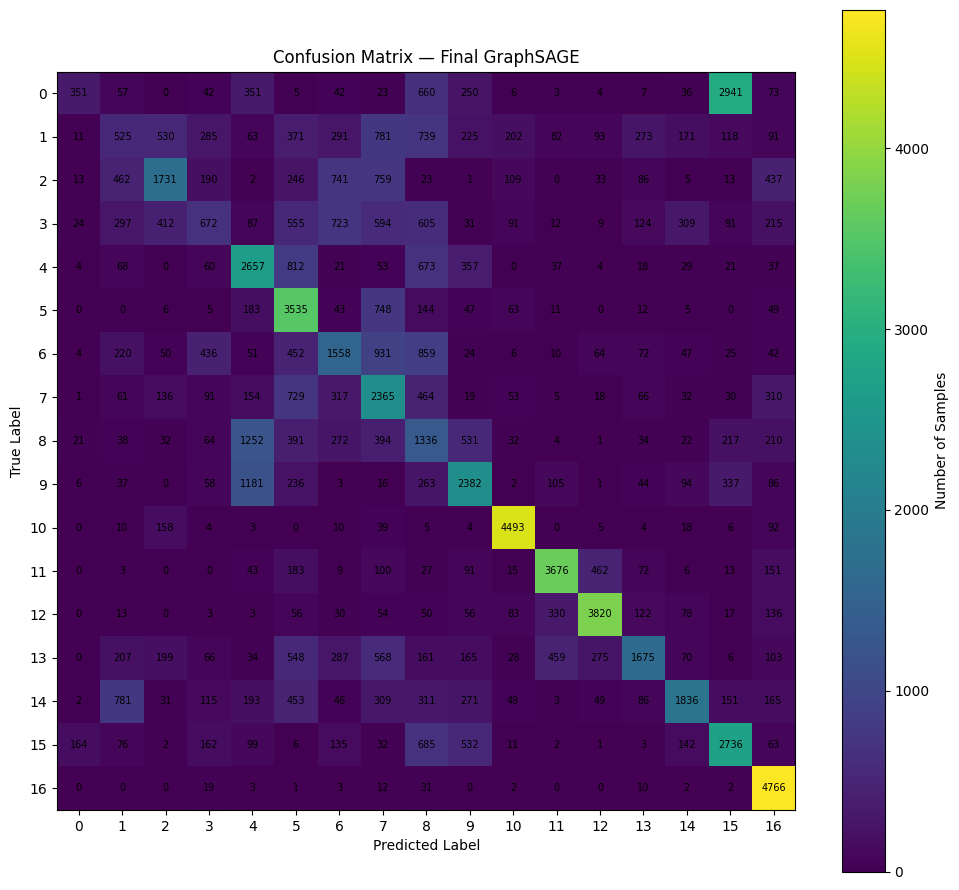

In [447]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(17)
)

plt.figure(figsize=(10, 9))

plt.imshow(cm, interpolation="nearest")

plt.title("Confusion Matrix — Final GraphSAGE")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(range(17), range(17))
plt.yticks(range(17), range(17))

plt.colorbar(label="Number of Samples")

for i in range(17):
    for j in range(17):
        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            fontsize=7
        )

plt.tight_layout()
plt.show()


ROC-AUC
Macro ROC-AUC:    0.9192
Weighted ROC-AUC: 0.9192


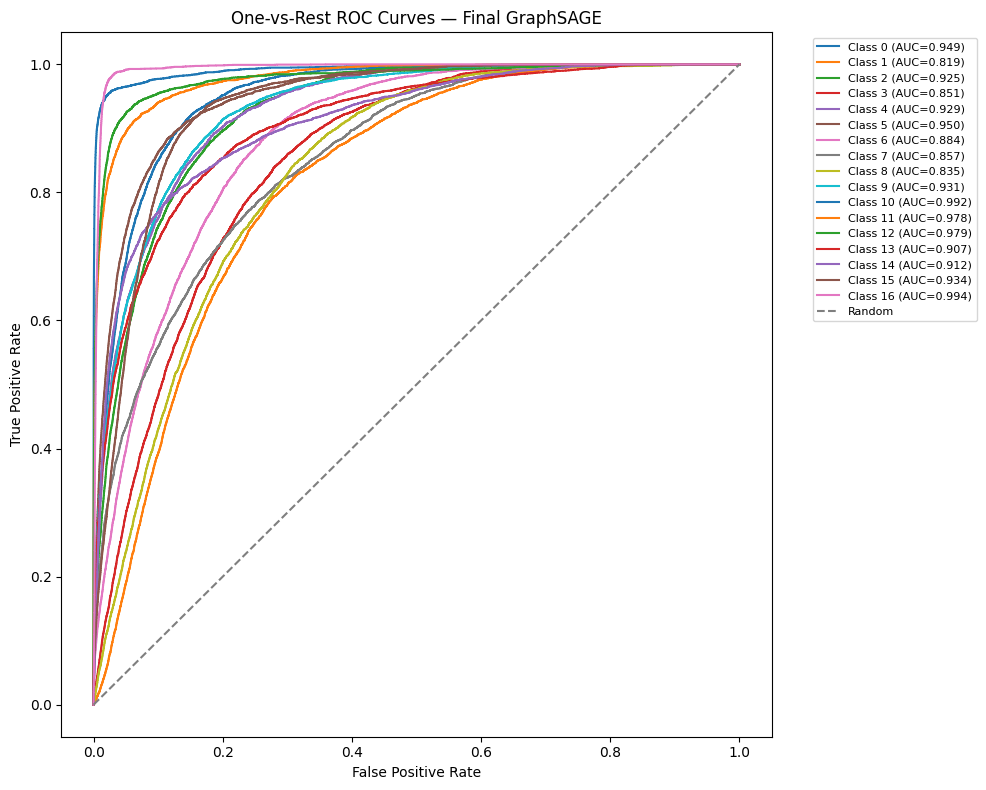

In [449]:
# ============================================================
# ROC-AUC
# ============================================================

y_true_bin = label_binarize(
    y_true,
    classes=np.arange(17)
)

macro_auc = roc_auc_score(
    y_true_bin,
    y_prob,
    multi_class="ovr",
    average="macro"
)

weighted_auc = roc_auc_score(
    y_true_bin,
    y_prob,
    multi_class="ovr",
    average="weighted"
)

print("\n========================================")
print("ROC-AUC")
print("========================================")

print(f"Macro ROC-AUC:    {macro_auc:.4f}")
print(f"Weighted ROC-AUC: {weighted_auc:.4f}")


# ============================================================
# ROC CURVES
# ============================================================

plt.figure(figsize=(10, 8))

for class_id in range(17):

    if y_true_bin[:, class_id].sum() == 0:
        continue

    fpr, tpr, _ = roc_curve(
        y_true_bin[:, class_id],
        y_prob[:, class_id]
    )

    class_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"Class {class_id} (AUC={class_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "One-vs-Rest ROC Curves — Final GraphSAGE"
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=8
)

plt.tight_layout()
plt.show()

# SHAP 

In [407]:
# ============================================
# FIND ONE CORRECT + ONE WRONG TEST GRAPH
# ============================================

final_model.eval()

correct_sample = None
wrong_sample = None

with torch.no_grad():

    for data in final_test_loader:

        data = data.to(device)

        output = final_model(data)

        predictions = output.argmax(dim=1)

        for i in range(data.y.size(0)):

            true_label = int(data.y[i].item())
            pred_label = int(predictions[i].item())

            if correct_sample is None and true_label == pred_label:
                correct_sample = {
                    "x": data.x[i].detach().cpu(),
                    "y": true_label,
                    "pred": pred_label,
                    "subject": int(data.subject[i].item()),
                    "session": int(data.session[i].item()),
                    "trial": int(data.trial[i].item()),
                    "window_id": int(data.window_id[i].item())
                }

            if wrong_sample is None and true_label != pred_label:
                wrong_sample = {
                    "x": data.x[i].detach().cpu(),
                    "y": true_label,
                    "pred": pred_label,
                    "subject": int(data.subject[i].item()),
                    "session": int(data.session[i].item()),
                    "trial": int(data.trial[i].item()),
                    "window_id": int(data.window_id[i].item())
                }

            if correct_sample is not None and wrong_sample is not None:
                break

        if correct_sample is not None and wrong_sample is not None:
            break


print("========================================")
print("       EXPLAINABILITY SAMPLES")
print("========================================")

print()
print("CORRECT SAMPLE")
print("True label:", correct_sample["y"])
print("Predicted:", correct_sample["pred"])
print("Subject:", correct_sample["subject"])
print("Session:", correct_sample["session"])
print("Trial:", correct_sample["trial"])
print("Window:", correct_sample["window_id"])
print("Features:", correct_sample["x"].shape)

print()
print("WRONG SAMPLE")
print("True label:", wrong_sample["y"])
print("Predicted:", wrong_sample["pred"])
print("Subject:", wrong_sample["subject"])
print("Session:", wrong_sample["session"])
print("Trial:", wrong_sample["trial"])
print("Window:", wrong_sample["window_id"])
print("Features:", wrong_sample["x"].shape)

       EXPLAINABILITY SAMPLES

CORRECT SAMPLE
True label: 6
Predicted: 6
Subject: 38
Session: 1
Trial: 1
Window: 2
Features: torch.Size([6])

WRONG SAMPLE
True label: 6
Predicted: 3
Subject: 38
Session: 1
Trial: 1
Window: 0
Features: torch.Size([6])


In [408]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.51.0


In [409]:
import torch
import numpy as np
import shap

final_model.eval()

# --------------------------------------------
# Use the actual C-graph structure
# --------------------------------------------

sample_graph = test_graphs_C[
    next(
        i for i, g in enumerate(test_graphs_C)
        if int(g.subject) == correct_sample["subject"]
        and int(g.session) == correct_sample["session"]
        and int(g.trial) == correct_sample["trial"]
        and int(g.window_id) == correct_sample["window_id"]
    )
]

print("Sample graph:")
print(sample_graph)

print("x:", sample_graph.x.shape)
print("edge_index:", sample_graph.edge_index.shape)
print("edge_attr:", sample_graph.edge_attr.shape)
print("label:", sample_graph.y.item())

Sample graph:
Data(x=[8, 6], edge_index=[2, 16], edge_attr=[16, 1], y=[1], subject=38, session=1, trial=1, window_id=2)
x: torch.Size([8, 6])
edge_index: torch.Size([2, 16])
edge_attr: torch.Size([16, 1])
label: 6


In [411]:
# ============================================
# VERIFY CORRECT SAMPLE PREDICTION
# ============================================

final_model.eval()

sample_graph_device = sample_graph.to(device)

with torch.no_grad():
    output = final_model(sample_graph_device)

prediction = output.argmax(dim=1).item()

print("True label:", sample_graph.y.item())
print("Prediction:", prediction)
print("Output shape:", output.shape)

True label: 6
Prediction: 6
Output shape: torch.Size([1, 17])


In [412]:
import shap
import numpy as np
import torch

final_model.eval()

# Fixed graph structure
fixed_edge_index = sample_graph.edge_index.to(device)
fixed_edge_attr = sample_graph.edge_attr.to(device)

# Original node features
original_x = sample_graph.x.cpu().numpy()

# ------------------------------------------------
# SHAP prediction function
# Input: flattened 8 x 6 = 48 features
# Output: probabilities for 17 classes
# ------------------------------------------------

def shap_predict(X):

    X = np.asarray(X, dtype=np.float32)

    outputs = []

    for row in X:

        x = torch.tensor(
            row.reshape(8, 6),
            dtype=torch.float32,
            device=device
        )

        data = sample_graph.clone().to(device)

        data.x = x
        data.edge_index = fixed_edge_index
        data.edge_attr = fixed_edge_attr

        with torch.no_grad():
            logits = final_model(data)
            probabilities = torch.softmax(logits, dim=1)

        outputs.append(
            probabilities.squeeze(0).cpu().numpy()
        )

    return np.array(outputs)


print("Original feature shape:", original_x.shape)
print("Flattened shape:", original_x.reshape(1, -1).shape)

# Test wrapper
test_output = shap_predict(
    original_x.reshape(1, -1)
)

print("SHAP wrapper output shape:", test_output.shape)
print("Predicted class:", test_output.argmax(axis=1)[0])
print("Predicted probability:", test_output.max())

Original feature shape: (8, 6)
Flattened shape: (1, 48)
SHAP wrapper output shape: (1, 17)
Predicted class: 6
Predicted probability: 0.39387664


In [414]:
# ============================================
# SHAP EXPLANATION — CORRECT SAMPLE
# ============================================

# Background data:
# Use the original sample plus small variations
# around the observed feature distribution.

background = np.tile(
    original_x.reshape(1, -1),
    (20, 1)
)

# Add small noise to create background examples
rng = np.random.default_rng(42)

background = background + rng.normal(
    loc=0.0,
    scale=0.05,
    size=background.shape
).astype(np.float32)

# Explain the original sample
shap_input = original_x.reshape(1, -1).astype(np.float32)

print("Background shape:", background.shape)
print("Explain shape:", shap_input.shape)

# SHAP KernelExplainer
explainer = shap.KernelExplainer(
    shap_predict,
    background
)

print("SHAP explainer created.")


# ============================================
# CALCULATE SHAP VALUES
# ============================================

shap_values = explainer.shap_values(
    shap_input,
    nsamples=100
)

print("SHAP calculation completed.")

if isinstance(shap_values, list):
    print("Number of output classes:", len(shap_values))
    print("Shape for class 6:", np.array(shap_values[6]).shape)
else:
    print("SHAP values shape:", np.array(shap_values).shape)

Background shape: (20, 48)
Explain shape: (1, 48)
SHAP explainer created.


  0%|          | 0/1 [00:00<?, ?it/s]

SHAP calculation completed.
SHAP values shape: (1, 48, 17)


In [415]:
# ============================================
# EXTRACT CLASS-6 SHAP VALUES
# ============================================

if isinstance(shap_values, list):

    class_shap = np.array(shap_values[6])

else:

    shap_array = np.array(shap_values)

    # Handle possible SHAP output layouts
    if shap_array.ndim == 3:
        class_shap = shap_array[:, :, 6]
    else:
        class_shap = shap_array

class_shap = np.asarray(class_shap).reshape(48)

print("Class 6 SHAP shape:", class_shap.shape)
print()
print("Class 6 SHAP values:")
print(class_shap)

Class 6 SHAP shape: (48,)

Class 6 SHAP values:
[ 0.          0.          0.          0.          0.          0.
  0.00372165  0.          0.          0.          0.00096609  0.
  0.          0.          0.          0.          0.          0.00053449
  0.         -0.00215146  0.          0.          0.          0.
 -0.00286319  0.00065498  0.          0.         -0.00061846  0.
  0.          0.          0.          0.          0.          0.
  0.00101812  0.          0.00082213  0.          0.          0.
  0.          0.00051739  0.          0.          0.          0.        ]


In [416]:
# ============================================
# SHAP: 8 NODES × 6 FEATURES
# ============================================

shap_matrix = class_shap.reshape(8, 6)

print("SHAP matrix shape:", shap_matrix.shape)
print()
print(shap_matrix)

SHAP matrix shape: (8, 6)

[[ 0.          0.          0.          0.          0.          0.        ]
 [ 0.00372165  0.          0.          0.          0.00096609  0.        ]
 [ 0.          0.          0.          0.          0.          0.00053449]
 [ 0.         -0.00215146  0.          0.          0.          0.        ]
 [-0.00286319  0.00065498  0.          0.         -0.00061846  0.        ]
 [ 0.          0.          0.          0.          0.          0.        ]
 [ 0.00101812  0.          0.00082213  0.          0.          0.        ]
 [ 0.          0.00051739  0.          0.          0.          0.        ]]


In [417]:
# ============================================
# GLOBAL FEATURE IMPORTANCE FOR THIS SAMPLE
# ============================================

feature_importance = np.mean(
    np.abs(shap_matrix),
    axis=0
)

print("Feature importance:")
for i, value in enumerate(feature_importance):
    print(
        f"Feature {i+1}: {value:.6f}"
    )

Feature importance:
Feature 1: 0.000950
Feature 2: 0.000415
Feature 3: 0.000103
Feature 4: 0.000000
Feature 5: 0.000198
Feature 6: 0.000067


In [418]:
# ============================================
# TOP NODE-FEATURE CONTRIBUTIONS
# ============================================

flat_indices = np.argsort(
    np.abs(class_shap)
)[::-1]

print("========================================")
print("TOP SHAP CONTRIBUTIONS")
print("========================================")

for idx in flat_indices[:10]:

    node = idx // 6
    feature = idx % 6

    value = class_shap[idx]

    print(
        f"Node {node+1}, "
        f"Feature {feature+1}: "
        f"{value:+.6f}"
    )

TOP SHAP CONTRIBUTIONS
Node 2, Feature 1: +0.003722
Node 5, Feature 1: -0.002863
Node 4, Feature 2: -0.002151
Node 7, Feature 1: +0.001018
Node 2, Feature 5: +0.000966
Node 7, Feature 3: +0.000822
Node 5, Feature 2: +0.000655
Node 5, Feature 5: -0.000618
Node 3, Feature 6: +0.000534
Node 8, Feature 2: +0.000517


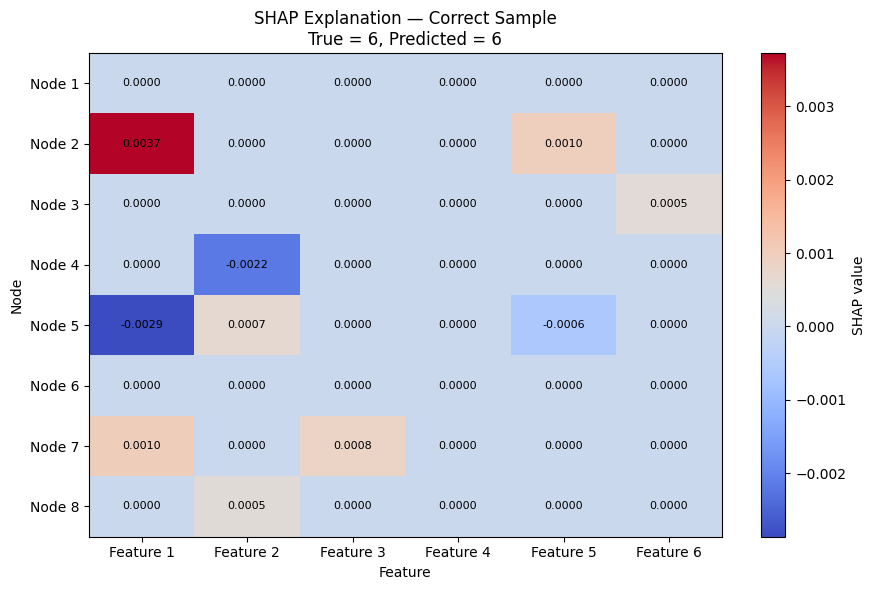

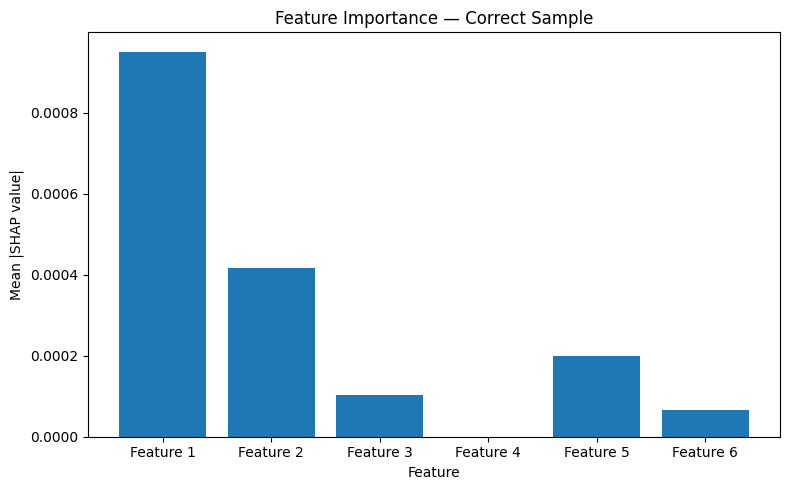

In [419]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================
# SHAP VISUALIZATION — CORRECT SAMPLE
# ============================================

# class_shap already contains 48 SHAP values
shap_matrix = class_shap.reshape(8, 6)

# ------------------------------------------------
# Plot 1: Node × Feature SHAP heatmap
# ------------------------------------------------

plt.figure(figsize=(9, 6))

plt.imshow(
    shap_matrix,
    aspect="auto",
    cmap="coolwarm"
)

plt.colorbar(label="SHAP value")

plt.xlabel("Feature")
plt.ylabel("Node")

plt.xticks(
    range(6),
    [f"Feature {i+1}" for i in range(6)]
)

plt.yticks(
    range(8),
    [f"Node {i+1}" for i in range(8)]
)

plt.title(
    "SHAP Explanation — Correct Sample\n"
    "True = 6, Predicted = 6"
)

# Add values inside cells
for i in range(8):
    for j in range(6):
        plt.text(
            j,
            i,
            f"{shap_matrix[i, j]:.4f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.tight_layout()
plt.show()


# ------------------------------------------------
# Plot 2: Mean absolute SHAP feature importance
# ------------------------------------------------

feature_importance = np.mean(
    np.abs(shap_matrix),
    axis=0
)

plt.figure(figsize=(8, 5))

plt.bar(
    range(1, 7),
    feature_importance
)

plt.xlabel("Feature")
plt.ylabel("Mean |SHAP value|")
plt.title(
    "Feature Importance — Correct Sample"
)

plt.xticks(
    range(1, 7),
    [f"Feature {i}" for i in range(1, 7)]
)

plt.tight_layout()
plt.show()

In [421]:
print(type(wrong_sample))
print(wrong_sample.keys())

<class 'dict'>
dict_keys(['x', 'y', 'pred', 'subject', 'session', 'trial', 'window_id'])


In [422]:
from torch_geometric.data import Data

print("wrong_sample type:", type(wrong_sample))

wrong_graph = None

for key, value in wrong_sample.items():

    if isinstance(value, Data):
        wrong_graph = value
        print("Found PyG graph under key:", key)
        break

if wrong_graph is None:
    print("No PyG Data object found.")
    print("Available keys:")
    for key, value in wrong_sample.items():
        print(
            key,
            type(value)
        )

wrong_sample type: <class 'dict'>
No PyG Data object found.
Available keys:
x <class 'torch.Tensor'>
y <class 'int'>
pred <class 'int'>
subject <class 'int'>
session <class 'int'>
trial <class 'int'>
window_id <class 'int'>


In [424]:
# ============================================
# FIND ORIGINAL WRONG GRAPH
# ============================================

target_subject = wrong_sample["subject"]
target_session = wrong_sample["session"]
target_trial = wrong_sample["trial"]
target_window = wrong_sample["window_id"]

wrong_graph = None

# Search test graphs first
for graph in test_graphs_C:

    if (
        int(graph.subject) == target_subject
        and int(graph.session) == target_session
        and int(graph.trial) == target_trial
        and int(graph.window_id) == target_window
    ):
        wrong_graph = graph
        break

print("Found graph:", wrong_graph)

Found graph: Data(x=[8, 6], edge_index=[2, 16], edge_attr=[16, 1], y=[1], subject=38, session=1, trial=1, window_id=0)


In [425]:
# ============================================
# VERIFY WRONG GRAPH
# ============================================

if wrong_graph is not None:

    print("========================================")
    print("WRONG GRAPH FOUND")
    print("========================================")

    print(wrong_graph)

    print("x:", wrong_graph.x.shape)
    print("edge_index:", wrong_graph.edge_index.shape)
    print("edge_attr:", wrong_graph.edge_attr.shape)

    print("True label:", wrong_graph.y.item())
    print("Subject:", int(wrong_graph.subject))
    print("Session:", int(wrong_graph.session))
    print("Trial:", int(wrong_graph.trial))
    print("Window:", int(wrong_graph.window_id))

else:

    print("WRONG GRAPH NOT FOUND")

WRONG GRAPH FOUND
Data(x=[8, 6], edge_index=[2, 16], edge_attr=[16, 1], y=[1], subject=38, session=1, trial=1, window_id=0)
x: torch.Size([8, 6])
edge_index: torch.Size([2, 16])
edge_attr: torch.Size([16, 1])
True label: 6
Subject: 38
Session: 1
Trial: 1
Window: 0


In [426]:
# ============================================
# VERIFY WRONG SAMPLE PREDICTION
# ============================================

final_model.eval()

wrong_graph_device = wrong_graph.to(device)

with torch.no_grad():

    wrong_output = final_model(
        wrong_graph_device
    )

wrong_prediction = wrong_output.argmax(
    dim=1
).item()

wrong_probability = torch.softmax(
    wrong_output,
    dim=1
)[0, wrong_prediction].item()

print("========================================")
print("WRONG SAMPLE PREDICTION")
print("========================================")

print("True label:", wrong_graph.y.item())
print("Prediction:", wrong_prediction)
print("Probability:", wrong_probability)
print("Output shape:", wrong_output.shape)

WRONG SAMPLE PREDICTION
True label: 6
Prediction: 3
Probability: 0.37018871307373047
Output shape: torch.Size([1, 17])


In [427]:
# ============================================
# SHAP WRAPPER — WRONG SAMPLE
# ============================================

wrong_original_x = wrong_graph.x.cpu().numpy()

wrong_edge_index = wrong_graph.edge_index.to(device)
wrong_edge_attr = wrong_graph.edge_attr.to(device)


def wrong_shap_predict(X):

    X = np.asarray(X, dtype=np.float32)

    outputs = []

    for row in X:

        x = torch.tensor(
            row.reshape(8, 6),
            dtype=torch.float32,
            device=device
        )

        data = wrong_graph.clone().to(device)

        data.x = x
        data.edge_index = wrong_edge_index
        data.edge_attr = wrong_edge_attr

        with torch.no_grad():
            logits = final_model(data)
            probabilities = torch.softmax(
                logits,
                dim=1
            )

        outputs.append(
            probabilities.squeeze(0).cpu().numpy()
        )

    return np.array(outputs)


# Verify wrapper
wrapper_output = wrong_shap_predict(
    wrong_original_x.reshape(1, -1)
)

print("Wrapper output shape:", wrapper_output.shape)
print("Wrapper prediction:", wrapper_output.argmax(axis=1)[0])
print(
    "Predicted probability:",
    wrapper_output.max()
)

Wrapper output shape: (1, 17)
Wrapper prediction: 3
Predicted probability: 0.3701887


In [428]:
# ============================================
# CREATE SHAP EXPLAINER
# ============================================

background_wrong = np.tile(
    wrong_original_x.reshape(1, -1),
    (20, 1)
)

rng = np.random.default_rng(42)

background_wrong = (
    background_wrong
    + rng.normal(
        loc=0.0,
        scale=0.05,
        size=background_wrong.shape
    ).astype(np.float32)
)

wrong_shap_input = (
    wrong_original_x
    .reshape(1, -1)
    .astype(np.float32)
)

wrong_explainer = shap.KernelExplainer(
    wrong_shap_predict,
    background_wrong
)

print("SHAP explainer created.")

wrong_shap_values = wrong_explainer.shap_values(
    wrong_shap_input,
    nsamples=100
)

print("SHAP calculation completed.")

SHAP explainer created.


  0%|          | 0/1 [00:00<?, ?it/s]

SHAP calculation completed.


In [429]:
# ============================================
# EXTRACT PREDICTED CLASS SHAP VALUES
# ============================================

predicted_class = wrong_prediction

if isinstance(wrong_shap_values, list):

    wrong_class_shap = np.array(
        wrong_shap_values[predicted_class]
    )

else:

    wrong_array = np.array(wrong_shap_values)

    if wrong_array.ndim == 3:

        wrong_class_shap = (
            wrong_array[:, :, predicted_class]
        )

    else:

        wrong_class_shap = wrong_array


wrong_class_shap = np.asarray(
    wrong_class_shap
).reshape(48)

wrong_shap_matrix = (
    wrong_class_shap.reshape(8, 6)
)

print("========================================")
print("WRONG SAMPLE SHAP")
print("========================================")
print("True class:", wrong_graph.y.item())
print("Predicted class:", predicted_class)
print("SHAP shape:", wrong_class_shap.shape)

print()
print("Top SHAP contributions:")
print("========================================")

indices = np.argsort(
    np.abs(wrong_class_shap)
)[::-1]

for idx in indices[:10]:

    node = idx // 6
    feature = idx % 6

    print(
        f"Node {node+1}, "
        f"Feature {feature+1}: "
        f"{wrong_class_shap[idx]:+.6f}"
    )

WRONG SAMPLE SHAP
True class: 6
Predicted class: 3
SHAP shape: (48,)

Top SHAP contributions:
Node 4, Feature 5: -0.001878
Node 6, Feature 5: -0.001567
Node 6, Feature 2: +0.001543
Node 5, Feature 2: +0.001384
Node 1, Feature 5: +0.001234
Node 8, Feature 1: +0.001184
Node 4, Feature 6: +0.000922
Node 7, Feature 2: +0.000602
Node 5, Feature 3: +0.000540
Node 5, Feature 5: +0.000292


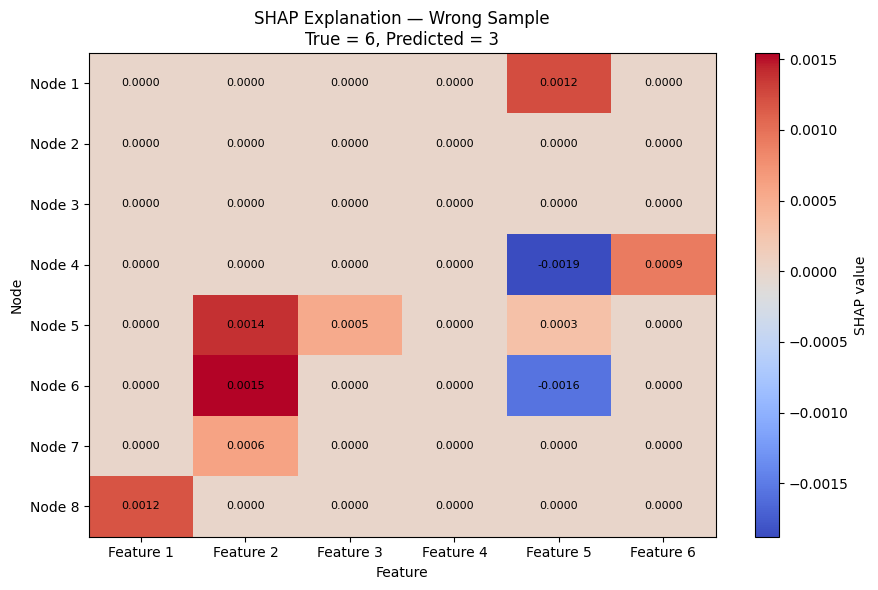

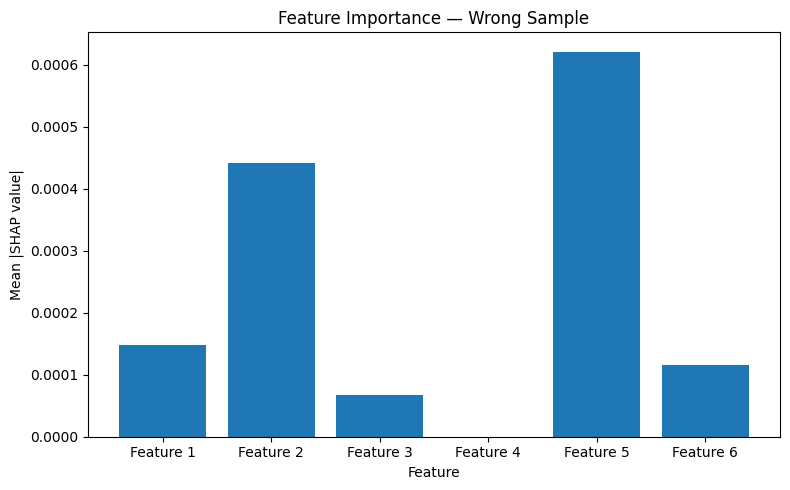

In [430]:
# ============================================
# SHAP PLOTS — WRONG SAMPLE
# ============================================

import matplotlib.pyplot as plt
import numpy as np

# 8 nodes × 6 features
wrong_shap_matrix = wrong_class_shap.reshape(8, 6)

# --------------------------------------------
# Plot 1: Node × Feature SHAP heatmap
# --------------------------------------------

plt.figure(figsize=(9, 6))

plt.imshow(
    wrong_shap_matrix,
    aspect="auto",
    cmap="coolwarm"
)

plt.colorbar(label="SHAP value")

plt.xlabel("Feature")
plt.ylabel("Node")

plt.xticks(
    range(6),
    [f"Feature {i+1}" for i in range(6)]
)

plt.yticks(
    range(8),
    [f"Node {i+1}" for i in range(8)]
)

plt.title(
    "SHAP Explanation — Wrong Sample\n"
    "True = 6, Predicted = 3"
)

# Values inside cells
for i in range(8):
    for j in range(6):

        plt.text(
            j,
            i,
            f"{wrong_shap_matrix[i, j]:.4f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.tight_layout()
plt.show()


# --------------------------------------------
# Plot 2: Feature importance
# --------------------------------------------

wrong_feature_importance = np.mean(
    np.abs(wrong_shap_matrix),
    axis=0
)

plt.figure(figsize=(8, 5))

plt.bar(
    range(1, 7),
    wrong_feature_importance
)

plt.xlabel("Feature")
plt.ylabel("Mean |SHAP value|")

plt.title(
    "Feature Importance — Wrong Sample"
)

plt.xticks(
    range(1, 7),
    [f"Feature {i}" for i in range(1, 7)]
)

plt.tight_layout()
plt.show()

# LIME

In [431]:
# ============================================
# LIME SETUP
# ============================================

import lime
from lime.lime_tabular import LimeTabularExplainer

print("LIME imported successfully.")

LIME imported successfully.


In [432]:
# ============================================
# LIME — CORRECT SAMPLE
# ============================================

correct_original_x = sample_graph.x.cpu().numpy()

correct_edge_index = sample_graph.edge_index.to(device)
correct_edge_attr = sample_graph.edge_attr.to(device)


def correct_lime_predict(X):

    X = np.asarray(X, dtype=np.float32)

    outputs = []

    for row in X:

        x = torch.tensor(
            row.reshape(8, 6),
            dtype=torch.float32,
            device=device
        )

        data = sample_graph.clone().to(device)

        data.x = x
        data.edge_index = correct_edge_index
        data.edge_attr = correct_edge_attr

        with torch.no_grad():
            logits = final_model(data)
            probabilities = torch.softmax(
                logits,
                dim=1
            )

        outputs.append(
            probabilities.squeeze(0).cpu().numpy()
        )

    return np.asarray(outputs)


# Verify
correct_lime_output = correct_lime_predict(
    correct_original_x.reshape(1, -1)
)

print("Output shape:", correct_lime_output.shape)
print("Prediction:", correct_lime_output.argmax(axis=1)[0])
print("True label:", sample_graph.y.item())

Output shape: (1, 17)
Prediction: 6
True label: 6


In [433]:
# ============================================
# LIME EXPLAINER — CORRECT SAMPLE
# ============================================

feature_names = [
    f"Node{node+1}_Feature{feature+1}"
    for node in range(8)
    for feature in range(6)
]

# Use the actual sample as the center of LIME's
# perturbation distribution.
training_data = np.tile(
    correct_original_x.reshape(1, -1),
    (100, 1)
)

rng = np.random.default_rng(42)

training_data = (
    training_data
    + rng.normal(
        0.0,
        0.05,
        training_data.shape
    ).astype(np.float32)
)

lime_explainer = LimeTabularExplainer(
    training_data,
    feature_names=feature_names,
    class_names=[
        f"Class {i}"
        for i in range(17)
    ],
    mode="classification",
    discretize_continuous=False,
    random_state=42
)

print("LIME explainer created.")

LIME explainer created.


In [434]:
# ============================================
# GENERATE LIME EXPLANATION
# ============================================

correct_lime_exp = lime_explainer.explain_instance(
    correct_original_x.reshape(-1),
    correct_lime_predict,
    labels=[6],
    num_features=48,
    num_samples=1000
)

print("LIME explanation generated.")

print()
print("Top LIME contributions — Correct Sample")
print("========================================")

for feature, weight in correct_lime_exp.as_list(
    label=6
)[:10]:

    print(
        f"{feature}: {weight:+.6f}"
    )

LIME explanation generated.

Top LIME contributions — Correct Sample
Node2_Feature1: +0.015841
Node5_Feature1: -0.011116
Node5_Feature2: -0.011049
Node3_Feature1: +0.009756
Node4_Feature1: -0.008703
Node7_Feature1: -0.007340
Node7_Feature6: +0.006517
Node6_Feature4: -0.006119
Node6_Feature2: -0.005479
Node6_Feature1: +0.005242


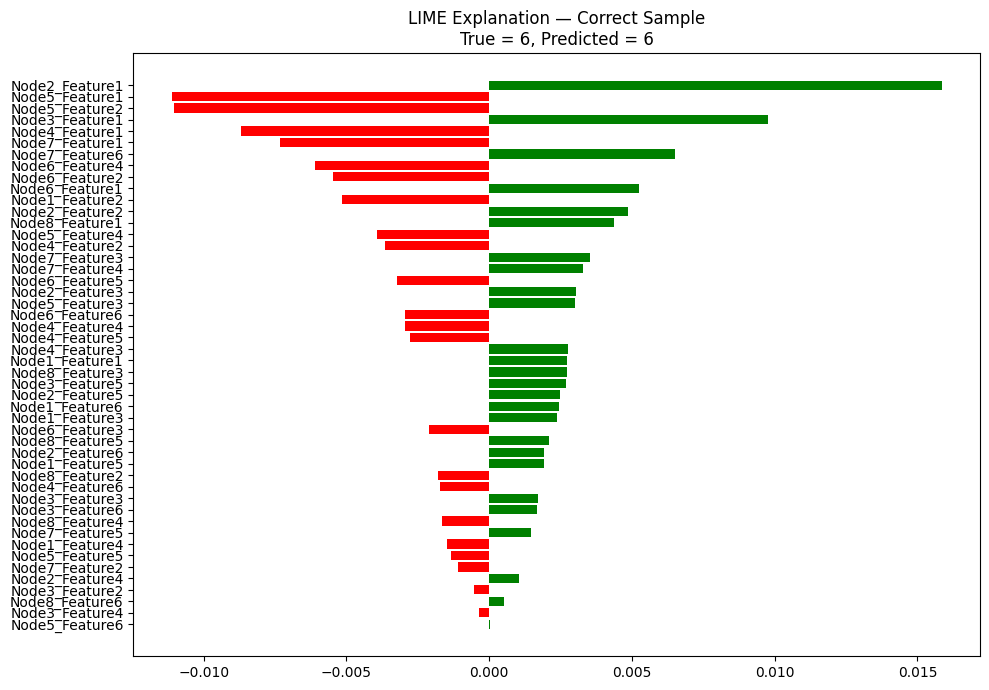

In [435]:
# ============================================
# LIME PLOT — CORRECT SAMPLE
# ============================================

fig = correct_lime_exp.as_pyplot_figure(
    label=6
)

fig.set_size_inches(10, 7)

plt.title(
    "LIME Explanation — Correct Sample\n"
    "True = 6, Predicted = 6"
)

plt.tight_layout()
plt.show()

In [436]:
# ============================================
# LIME — WRONG SAMPLE
# ============================================

wrong_original_x = wrong_graph.x.cpu().numpy()

wrong_edge_index = wrong_graph.edge_index.to(device)
wrong_edge_attr = wrong_graph.edge_attr.to(device)


def wrong_lime_predict(X):

    X = np.asarray(X, dtype=np.float32)

    outputs = []

    for row in X:

        x = torch.tensor(
            row.reshape(8, 6),
            dtype=torch.float32,
            device=device
        )

        data = wrong_graph.clone().to(device)

        data.x = x
        data.edge_index = wrong_edge_index
        data.edge_attr = wrong_edge_attr

        with torch.no_grad():
            logits = final_model(data)

            probabilities = torch.softmax(
                logits,
                dim=1
            )

        outputs.append(
            probabilities.squeeze(0).cpu().numpy()
        )

    return np.asarray(outputs)


# Verify
wrong_lime_output = wrong_lime_predict(
    wrong_original_x.reshape(1, -1)
)

print("Output shape:", wrong_lime_output.shape)
print("Prediction:", wrong_lime_output.argmax(axis=1)[0])
print("True label:", wrong_graph.y.item())

Output shape: (1, 17)
Prediction: 3
True label: 6


In [437]:
# ============================================
# LIME EXPLANATION — WRONG SAMPLE
# ============================================

wrong_training_data = np.tile(
    wrong_original_x.reshape(1, -1),
    (100, 1)
)

rng = np.random.default_rng(42)

wrong_training_data = (
    wrong_training_data
    + rng.normal(
        0.0,
        0.05,
        wrong_training_data.shape
    ).astype(np.float32)
)

wrong_lime_explainer = LimeTabularExplainer(
    wrong_training_data,
    feature_names=feature_names,
    class_names=[
        f"Class {i}"
        for i in range(17)
    ],
    mode="classification",
    discretize_continuous=False,
    random_state=42
)

wrong_lime_exp = (
    wrong_lime_explainer.explain_instance(
        wrong_original_x.reshape(-1),
        wrong_lime_predict,
        labels=[3],
        num_features=48,
        num_samples=1000
    )
)

print("========================================")
print("LIME — WRONG SAMPLE")
print("========================================")

for feature, weight in wrong_lime_exp.as_list(
    label=3
)[:10]:

    print(
        f"{feature}: {weight:+.6f}"
    )

LIME — WRONG SAMPLE
Node6_Feature4: +0.006933
Node7_Feature6: -0.006719
Node2_Feature1: -0.006660
Node7_Feature1: +0.006478
Node6_Feature2: +0.005701
Node3_Feature1: -0.005609
Node6_Feature5: +0.005281
Node8_Feature1: -0.005250
Node7_Feature2: +0.004517
Node5_Feature6: -0.004428


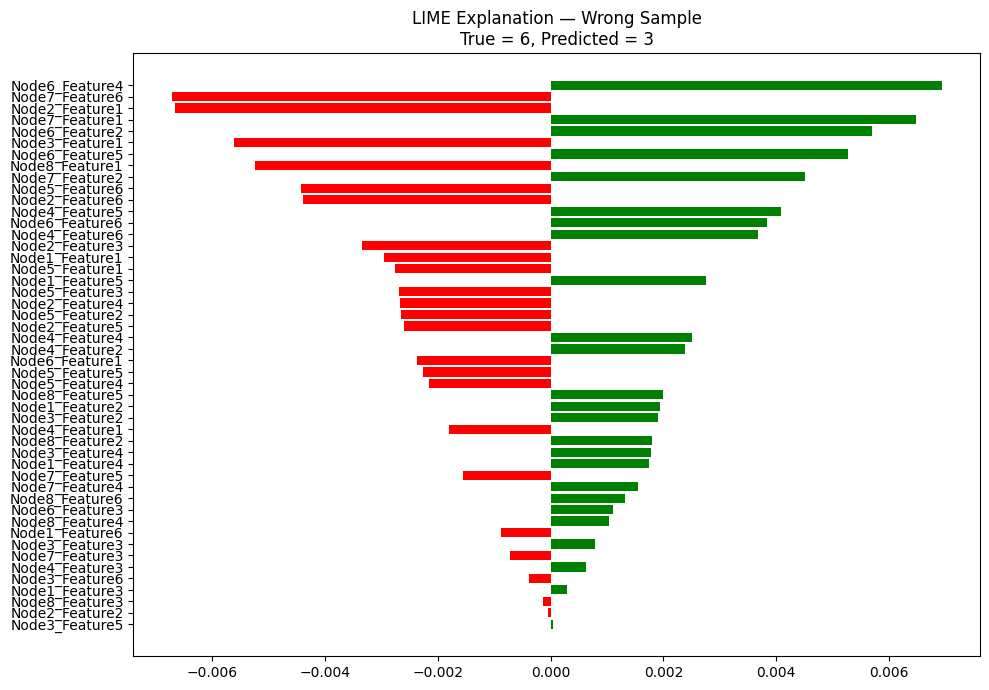

In [438]:
# ============================================
# LIME PLOT — WRONG SAMPLE
# ============================================

fig = wrong_lime_exp.as_pyplot_figure(
    label=3
)

fig.set_size_inches(10, 7)

plt.title(
    "LIME Explanation — Wrong Sample\n"
    "True = 6, Predicted = 3"
)

plt.tight_layout()
plt.show()